In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!nvidia smi

/bin/bash: line 1: nvidia: command not found


In [ ]:
import pandas as pd
import os

pd.set_option('display.max_columns', None)

ROOT_PATH = "/content/drive/MyDrive/C-MAPSS/CMaps/"
META_DATA = ['readme.txt', 'x.txt', 'Damage Propagation Modeling.pdf']
DATA_TXT = [f for f in os.listdir(ROOT_PATH) if f not in META_DATA]

train_df, test_df, rul_df = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

for file in DATA_TXT:
    file_path = os.path.join(ROOT_PATH, file)

    if 'train' in file:
        df = pd.read_csv(file_path, sep=r'\s+', header=None)
        df = df.iloc[:, :26]
        df['file_name'] = file
        train_df = pd.concat([train_df, df], axis=0)

    elif 'test' in file:
        df = pd.read_csv(file_path, sep=r'\s+', header=None)
        df = df.iloc[:, :26]
        df['file_name'] = file
        test_df = pd.concat([test_df, df], axis=0)

    elif 'RUL' in file:
        df = pd.read_csv(file_path, header=None, names=['RUL'])
        df['file_name'] = file
        rul_df = pd.concat([rul_df, df], axis=0)




In [ ]:
column_names = (
    ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3'] +
    [f'sensor_{i}' for i in range(1, 22)] +
    ['file_name']
)

train_df.columns = column_names
test_df.columns = column_names

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)
print("train_df head:\n", train_df.head())

Train shape: (160359, 27)
Test shape: (104897, 27)
RUL shape: (707, 2)
train_df head:
    unit_number  time_in_cycles  setting_1  setting_2  setting_3  sensor_1  \
0            1               1    -0.0007    -0.0004      100.0    518.67   
1            1               2     0.0019    -0.0003      100.0    518.67   
2            1               3    -0.0043     0.0003      100.0    518.67   
3            1               4     0.0007     0.0000      100.0    518.67   
4            1               5    -0.0019    -0.0002      100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  sensor_7  sensor_8  \
0    641.82   1589.70   1400.60     14.62     21.61    554.36   2388.06   
1    642.15   1591.82   1403.14     14.62     21.61    553.75   2388.04   
2    642.35   1587.99   1404.20     14.62     21.61    554.26   2388.08   
3    642.35   1582.79   1401.87     14.62     21.61    554.45   2388.11   
4    642.37   1582.85   1406.22     14.62     21.61    554.00   2388.06   


In [ ]:

train_df['max_cycle'] = train_df.groupby('unit_number')['time_in_cycles'].transform('max')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']
train_df.drop('max_cycle', axis=1, inplace=True)
print(train_df[['unit_number', 'time_in_cycles', 'RUL']].head(20))

    unit_number  time_in_cycles  RUL
0             1               1  320
1             1               2  319
2             1               3  318
3             1               4  317
4             1               5  316
5             1               6  315
6             1               7  314
7             1               8  313
8             1               9  312
9             1              10  311
10            1              11  310
11            1              12  309
12            1              13  308
13            1              14  307
14            1              15  306
15            1              16  305
16            1              17  304
17            1              18  303
18            1              19  302
19            1              20  301


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_to_normalize = ['setting_1', 'setting_2', 'setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
train_df[cols_to_normalize] = scaler.fit_transform(train_df[cols_to_normalize])
test_df[cols_to_normalize] = scaler.transform(test_df[cols_to_normalize])
print("Data has been normalized.")
print(train_df.head())

Data has been normalized.
   unit_number  time_in_cycles  setting_1  setting_2  setting_3  sensor_1  \
0            1               1   0.000190   0.000237        1.0       1.0   
1            1               2   0.000252   0.000356        1.0       1.0   
2            1               3   0.000105   0.001068        1.0       1.0   
3            1               4   0.000224   0.000712        1.0       1.0   
4            1               5   0.000162   0.000475        1.0       1.0   

   sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  sensor_7  sensor_8  \
0  0.969990  0.927293  0.902111       1.0       1.0  0.962153  0.998776   
1  0.973000  0.932957  0.908192       1.0       1.0  0.960749  0.998734   
2  0.974824  0.922723  0.910730       1.0       1.0  0.961923  0.998818   
3  0.974824  0.908829  0.905152       1.0       1.0  0.962360  0.998882   
4  0.975007  0.908989  0.915565       1.0       1.0  0.961324  0.998776   

   sensor_9  sensor_10  sensor_11  sensor_12  sensor_13  sen

In [ ]:
import numpy as np

def create_sequences(df, sequence_length, cols):
    X, y = [], []
    for unit in df['unit_number'].unique():
        # Get the data for the current engine
        unit_df = df[df['unit_number'] == unit]
        unit_data = unit_df[cols].values
        unit_rul = unit_df['RUL'].values

        # Create sequences for this engine
        for i in range(len(unit_data) - sequence_length + 1):
            X.append(unit_data[i:i+sequence_length])
            y.append(unit_rul[i+sequence_length-1])

    return np.array(X), np.array(y)

# Define sequence length and the features to use
sequence_length = 50
features = cols_to_normalize # We'll use the normalized columns

# Create training sequences
X_train, y_train = create_sequences(train_df, sequence_length, features)

print(f"Shape of X_train: {X_train.shape}") # Should be (samples, sequence_length, num_features)
print(f"Shape of y_train: {y_train.shape}") # Should be (samples,)

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

engine_1_df = train_df[train_df['unit_number'] == 1]

plt.figure(figsize=(12, 5))
plt.plot(engine_1_df['time_in_cycles'], engine_1_df['sensor_2'], label='Sensor 2')
plt.plot(engine_1_df['time_in_cycles'], engine_1_df['sensor_3'], label='Sensor 3')
plt.title('Sensor Degradation for Engine 1')
plt.xlabel('Time in Cycles')
plt.ylabel('Normalized Sensor Value')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

input_shape = (X_train.shape[1], X_train.shape[2])

model = Sequential()
model.add(LSTM(units=100, return_sequences=True, input_shape=input_shape))
model.add(Dropout(0.2))
model.add(LSTM(units=128))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

In [ ]:
#history = model.fit(
    #X_train, y_train,
    #epochs=15,
    #batch_size=32,
    #validation_split=0.25
#)
# THE NEW CODE

from tensorflow.keras.callbacks import EarlyStopping

early_stopper = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopper]
)

In [ ]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
rul_map = {unit_num: rul for unit_num, rul in enumerate(rul_df['RUL'].values, 1)}

X_test = []
y_test = []

test_subset_df = test_df[test_df['file_name'] == 'test_FD001.txt']
true_rul_subset = rul_df[rul_df['file_name'] == 'RUL_FD001.txt']['RUL'].values

for i, unit in enumerate(test_subset_df['unit_number'].unique()):
    unit_df = test_subset_df[test_subset_df['unit_number'] == unit]
    unit_data = unit_df[features].values
    last_sequence = unit_data[-sequence_length:]

    if len(last_sequence) < sequence_length:
        padding = np.zeros((sequence_length - len(last_sequence), unit_data.shape[1]))
        last_sequence = np.concatenate([padding, last_sequence])

    X_test.append(last_sequence)
    y_test.append(true_rul_subset[i])

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")




In [ ]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nRoot Mean Squared Error (RMSE) on Test Set: {rmse:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, 150], [0, 150], 'r--', label='Perfect Prediction')
plt.title('Actual vs. Predicted RUL')
plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention, Flatten, Add
)
from tensorflow.keras import backend as K
# ------------------------------------------------------------------
# 🔑 FIX: Import callbacks explicitly from the Keras module
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# ------------------------------------------------------------------

# --- 1. Data Loading and Preprocessing Functions ---

# Define column names (up to sensor_26, though CMAPSS uses up to sensor_21 typically)
col_names = ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3',
             'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
             'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
             'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
             'sensor_19', 'sensor_20', 'sensor_21']

# Selected features: Dropping constant/near-constant sensors (1, 5, 6, 10, 16, 18, 19)
selected_features = [
    'setting_1', 'setting_2', 'setting_3',
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_17', 'sensor_20', 'sensor_21'
]
index_cols = ['unit_number', 'time_in_cycles']

def load_and_preprocess_data(dataset_path, R_max=125):
    """Loads, calculates RUL, and normalizes the training data."""
    df = pd.read_csv(dataset_path, sep='\s+', header=None, names=col_names, engine='python')
    df = df.iloc[:, :26]
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = df.apply(lambda row: max_cycles[row['unit_number']] - row['time_in_cycles'], axis=1)
    df['RUL'] = df['RUL'].apply(lambda x: min(x, R_max))
    scaler = MinMaxScaler()
    df[selected_features] = scaler.fit_transform(df[selected_features])
    return df, scaler

def gen_sequences(df, sequence_length, selected_features):
    """Generates the 3D sequences for the model (Sliding Window)."""
    X, y = [], []
    for unit_num in df['unit_number'].unique():
        subset = df[df['unit_number'] == unit_num]
        data_subset = subset[selected_features].values
        target_subset = subset['RUL'].values
        for i in range(len(data_subset) - sequence_length + 1):
            X.append(data_subset[i:i + sequence_length])
            y.append(target_subset[i + sequence_length - 1])
    return np.array(X), np.array(y)

# --- 2. Custom Loss Function (NASA RUL Scoring) ---

def asymmetric_loss(y_true, y_pred):
    """Asymmetric NASA RUL score function implemented as a Keras loss function."""
    y_true = K.cast(y_true, K.floatx())
    y_pred = K.cast(y_pred, K.floatx())
    difference = y_pred - y_true
    alpha = 10.0 # Late penalty (pred < true)
    beta = 13.0  # Early penalty (pred >= true)

    loss = tf.where(
        difference < 0,
        K.exp(-difference / alpha) - 1.0,
        K.exp(difference / beta) - 1.0
    )
    return K.mean(loss)

# --- 3. Hybrid CNN-Transformer-BiLSTM Model Architecture (Functional API) ---

def transformer_block(input_tensor, head_size, num_heads, ff_dim, dropout=0.1):
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(input_tensor, input_tensor)
    x = LayerNormalization(epsilon=1e-6)(input_tensor + attn_output)
    ffn_output = Dense(ff_dim * x.shape[-1], activation="relu")(x)
    ffn_output = Dense(x.shape[-1])(ffn_output)
    return LayerNormalization(epsilon=1e-6)(x + ffn_output)


def build_hybrid_model(input_shape, head_size=128, num_heads=4, ff_dim=2,
                       transformer_blocks=2, lstm_units=64):

    inputs = Input(shape=input_shape)
    x = inputs

    # 1. CNN Motif Extractor
    x = Conv1D(filters=64, kernel_size=5, activation='relu', padding='causal', name='cnn_motif_extractor')(x)
    x = MaxPooling1D(pool_size=2, name='cnn_pool')(x)
    x = Dropout(0.2, name='cnn_dropout')(x)

    # 2. Long-Range Transformer
    for i in range(transformer_blocks):
        x = transformer_block(x, head_size, num_heads, ff_dim)

    # 3. Bi-LSTM Refinement
    x = Bidirectional(
        LSTM(units=lstm_units, return_sequences=True, activation='tanh', recurrent_dropout=0.2),
        name='bi_lstm_refinement'
    )(x)
    x = Dropout(0.3, name='bi_lstm_dropout')(x)

    # 4. Engine AE to Regression Head (Temporal Aggregation)
    x = Dense(units=32, activation='relu', name='ae_encoder_compression')(x)
    x = Flatten(name='flatten_for_regression')(x)
    outputs = Dense(units=1, activation='linear', name='rul_output')(x)

    return Model(inputs=inputs, outputs=outputs)

# --- 4. Optimized Execution ---

# Assuming Drive is mounted: from google.colab import drive; drive.mount('/content/drive')
DRIVE_FOLDER_PATH = '/content/drive/MyDrive/C-MAPSS/CMaps'
TRAIN_DATA_PATH = DRIVE_FOLDER_PATH + '/train_FD001.txt'

SEQUENCE_LENGTH = 30
R_MAX = 125

# Load, preprocess, and generate sequences
try:
    print(f"Loading data from: {TRAIN_DATA_PATH}")
    train_df, scaler = load_and_preprocess_data(TRAIN_DATA_PATH, R_max=R_MAX)
    X_train, y_train = gen_sequences(train_df, SEQUENCE_LENGTH, selected_features)
    print(f"Data shape: X_train {X_train.shape}, y_train {y_train.shape}")
except FileNotFoundError:
    print("\n⚠️ ERROR: File not found. Ensure Google Drive is mounted and the path is correct.")
    raise

# Build, Compile, and Summarize the model
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_hybrid_model(input_shape)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss=asymmetric_loss,
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

print("\n--- Optimized Hybrid Model Summary ---")
model.summary()
print("--------------------------------------")

# --- Training Call with Callbacks (Now correctly defined) ---

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

print("\nStarting Training (Requires GPU runtime)")
history = model.fit(
     X_train, y_train,
     epochs=100,
     batch_size=48, # Use a batch size suitable for your Colab GPU
     validation_split=0.2,
     callbacks=callbacks
 )

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
Hybrid CNN-Transformer-BiLSTM Model for RUL Prediction on C-MAPSS FD001.

This script loads the C-MAPSS data, preprocesses it, builds a hybrid
deep learning model, and trains it using an asymmetric loss function.
Finally, it visualizes the training and validation metrics.
"""

# --- 0. Imports ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

# Keras and TensorFlow imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention, Flatten
)
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError

# Type hinting
from typing import List, Tuple, Any, Dict


# --- 1. Constants and Configuration ---

# Define column names for the C-MAPSS dataset
COL_NAMES: List[str] = [
    'unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

# Features selected for training (dropping constant/near-constant sensors)
SELECTED_FEATURES: List[str] = [
    'setting_1', 'setting_2', 'setting_3',
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_17', 'sensor_20', 'sensor_21'
]

# Path configuration (assuming Google Drive is mounted)
DRIVE_FOLDER_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps'
TRAIN_DATA_PATH: str = f'{DRIVE_FOLDER_PATH}/train_FD001.txt'


# --- 2. Data Loading and Preprocessing ---

def load_and_preprocess_data(dataset_path: str, R_max: int = 125) -> Tuple[pd.DataFrame, MinMaxScaler]:
    """
    Loads C-MAPSS data, calculates piecewise linear RUL, and normalizes features.

    Args:
        dataset_path: Path to the train_FD001.txt file.
        R_max: The maximum (clipped) value for Remaining Useful Life (RUL).

    Returns:
        A tuple containing the preprocessed DataFrame and the fitted MinMaxScaler.
    """
    df = pd.read_csv(dataset_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
    df = df.iloc[:, :26]  # Ensure we only have 26 columns

    # Calculate RUL
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = df.apply(lambda row: max_cycles[row['unit_number']] - row['time_in_cycles'], axis=1)

    # Clip RUL at R_max
    df['RUL'] = df['RUL'].apply(lambda x: min(x, R_max))

    # Normalize selected features
    scaler = MinMaxScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])

    return df, scaler

def gen_sequences(df: pd.DataFrame, sequence_length: int, features: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generates 3D sequences (sliding window) for model training.

    Args:
        df: The preprocessed DataFrame.
        sequence_length: The number of time steps in each window.
        features: The list of feature columns to include.

    Returns:
        A tuple of (X, y) numpy arrays, where X is the sequence data
        and y is the corresponding RUL target.
    """
    X, y = [], []
    for unit_num in df['unit_number'].unique():
        subset = df[df['unit_number'] == unit_num]
        data_subset = subset[features].values
        target_subset = subset['RUL'].values

        # Create sliding windows
        for i in range(len(data_subset) - sequence_length + 1):
            X.append(data_subset[i:i + sequence_length])
            # The RUL is the value at the end of the sequence
            y.append(target_subset[i + sequence_length - 1])

    return np.array(X), np.array(y)


# --- 3. Custom Loss Function (NASA RUL Scoring) ---

def asymmetric_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    """
    Asymmetric NASA RUL score function implemented as a Keras loss function.
    This loss penalizes late predictions (pred < true) more heavily
    than early predictions (pred > true).

    Args:
        y_true: The true RUL values.
        y_pred: The predicted RUL values.

    Returns:
        The mean asymmetric loss.
    """
    y_true = K.cast(y_true, K.floatx())
    y_pred = K.cast(y_pred, K.floatx())
    difference = y_pred - y_true

    alpha = 10.0  # Penalty for late predictions (pred < true)
    beta = 13.0   # Penalty for early predictions (pred >= true)

    loss = tf.where(
        difference < 0,
        K.exp(-difference / alpha) - 1.0,
        K.exp(difference / beta) - 1.0
    )
    return K.mean(loss)


# --- 4. Hybrid CNN-Transformer-BiLSTM Model Architecture ---

def transformer_block(input_tensor: tf.Tensor, head_size: int, num_heads: int, ff_dim: int, dropout: float = 0.1, name: str = None) -> tf.Tensor:
    """
    A single Transformer block.

    Args:
        input_tensor: The input tensor.
        head_size: Dimensionality of each attention head.
        num_heads: Number of attention heads.
        ff_dim: Multiplier for the feed-forward network's inner dimension.
        dropout: Dropout rate.
        name: Optional name for the block.

    Returns:
        The output tensor from the Transformer block.
    """
    # 4a. Multi-Head Attention and Residual Connection
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size, dropout=dropout, name=f"{name}_mha"
    )(input_tensor, input_tensor)
    x = LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(input_tensor + attn_output)

    # 4b. Feed-Forward Network and Residual Connection
    ffn_output = Dense(ff_dim * x.shape[-1], activation="relu", name=f"{name}_ffn_dense1")(x)
    ffn_output = Dense(x.shape[-1], name=f"{name}_ffn_dense2")(ffn_output)

    return LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x + ffn_output)


def build_hybrid_model(input_shape: Tuple[int, int],
                       head_size: int = 128,
                       num_heads: int = 4,
                       ff_dim: int = 2,
                       transformer_blocks: int = 2,
                       lstm_units: int = 64) -> Model:
    """
    Builds the complete hybrid CNN-Transformer-BiLSTM model.

    Args:
        input_shape: A tuple (sequence_length, num_features).
        head_size: Dim of each Transformer attention head.
        num_heads: Number of Transformer attention heads.
        ff_dim: Feed-forward multiplier for Transformer.
        transformer_blocks: Number of Transformer blocks to stack.
        lstm_units: Number of units in the Bi-LSTM layer.

    Returns:
        A compiled Keras Model.
    """

    inputs = Input(shape=input_shape)
    x = inputs

    # 1. Local Motif Extractor (CNN)
    # Purpose: Extract local patterns and short-term sensor correlations.
    x = Conv1D(filters=64, kernel_size=5, activation='relu', padding='causal', name='cnn_motif_extractor')(x)
    x = MaxPooling1D(pool_size=2, name='cnn_pool')(x)
    x = Dropout(0.2, name='cnn_dropout')(x)

    # 2. Long-Range Dependency Learner (Transformer)
    # Purpose: Find complex relationships between distant time steps.
    for i in range(transformer_blocks):
        x = transformer_block(
            x, head_size, num_heads, ff_dim, name=f'transformer_block_{i+1}'
        )

    # 3. Sequential Refinement (Bi-LSTM)
    # Purpose: Model the forward and backward temporal flow of the sequence,
    #          refining the context-rich features from the Transformer.
    x = Bidirectional(
        LSTM(units=lstm_units, return_sequences=True, activation='tanh', recurrent_dropout=0.2),
        name='bi_lstm_refinement'
    )(x)
    x = Dropout(0.3, name='bi_lstm_dropout')(x)

    # 4. Regression Head
    # Purpose: Aggregate sequential features and map to a single RUL prediction.
    x = Dense(units=32, activation='relu', name='ae_encoder_compression')(x)
    x = Flatten(name='flatten_for_regression')(x)
    outputs = Dense(units=1, activation='linear', name='rul_output')(x)

    return Model(inputs=inputs, outputs=outputs)


# --- 5. Results Visualization ---

def plot_training_history(history: tf.keras.callbacks.History):
    """
    Plots the training and validation loss and RMSE from the model's history.

    Args:
        history: The History object returned by model.fit().
    """
    print("\n--- Visualizing Training Results ---")

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

    # Plot Loss (Asymmetric Loss)
    ax[0].plot(history.history['loss'], label='Training Loss', color='b', linestyle='-')
    ax[0].plot(history.history['val_loss'], label='Validation Loss', color='r', linestyle='--')
    best_val_loss = np.min(history.history['val_loss'])
    ax[0].set_title(f"Model Loss (Best Val: {best_val_loss:.4f})", fontsize=14)
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Asymmetric Loss')
    ax[0].legend()
    ax[0].grid(True)

    # Plot Metric (RMSE)
    ax[1].plot(history.history['rmse'], label='Training RMSE', color='b', linestyle='-')
    ax[1].plot(history.history['val_rmse'], label='Validation RMSE', color='r', linestyle='--')
    best_val_rmse = np.min(history.history['val_rmse'])
    ax[1].set_title(f"Model RMSE (Best Val: {best_val_rmse:.4f})", fontsize=14)
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('RMSE')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

    # Print final metrics
    best_epoch = np.argmin(history.history['val_loss'])
    print(f"\n✅ Training complete.")
    print(f"Best epoch: {best_epoch + 1}")
    print(f"  - Best Validation Loss: {history.history['val_loss'][best_epoch]:.4f}")
    print(f"  - Best Validation RMSE: {history.history['val_rmse'][best_epoch]:.4f}")


# --- 6. Main Execution ---

def main():
    """
    Main function to run the RUL prediction workflow.
    """

    # --- Training Hyperparameters ---
    SEQUENCE_LENGTH: int = 30
    R_MAX: int = 125
    EPOCHS: int = 100
    BATCH_SIZE: int = 64

    # --- 6a. Load and Prepare Data ---
    try:
        print(f"Loading data from: {TRAIN_DATA_PATH}")
        train_df, scaler = load_and_preprocess_data(TRAIN_DATA_PATH, R_max=R_MAX)
        X_train, y_train = gen_sequences(train_df, SEQUENCE_LENGTH, SELECTED_FEATURES)
        print(f"Data shape: X_train {X_train.shape}, y_train {y_train.shape}")
    except FileNotFoundError:
        print(f"\n⚠️ ERROR: File not found at {TRAIN_DATA_PATH}")
        print("Ensure Google Drive is mounted and the path is correct.")
        return  # Exit if data not found

    # --- 6b. Build and Compile Model ---
    input_shape: Tuple[int, int] = (X_train.shape[1], X_train.shape[2])
    model = build_hybrid_model(input_shape)

    optimizer = Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss=asymmetric_loss,
        metrics=[RootMeanSquaredError(name='rmse')]
    )

    print("\n--- Optimized Hybrid Model Summary ---")
    model.summary()
    print("--------------------------------------")

    # --- 6c. Define Callbacks ---
    callbacks: List[tf.keras.callbacks.Callback] = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

    # --- 6d. Train Model ---
    print("\n🚀 Starting Training (Requires GPU runtime)...")

    # This block is now uncommented and will run
    history = model.fit(
         X_train, y_train,
         epochs=EPOCHS,
         batch_size=BATCH_SIZE,
         validation_split=0.2,
         callbacks=callbacks,
         verbose=1  # Show progress bar
    )

    # --- 6e. Plot Results ---
    if history:
        plot_training_history(history)

if __name__ == "__main__":

    main()

In [ ]:

"""
Hybrid CNN-Transformer-BiLSTM Model for RUL Prediction on C-MAPSS FD001.

This script loads the C-MAPSS data, preprocesses it, builds a hybrid
deep learning model, and trains it using an asymmetric loss function.
Finally, it evaluates the model on the test set and visualizes results.
"""

# --- 0. Imports ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Keras and TensorFlow imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention, Flatten
)
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError

# Type hinting
from typing import List, Tuple, Any, Dict


# --- 1. Constants and Configuration ---

# Define column names for the C-MAPSS dataset
COL_NAMES: List[str] = [
    'unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

# Features selected for training (dropping constant/near-constant sensors)
SELECTED_FEATURES: List[str] = [
    'setting_1', 'setting_2', 'setting_3',
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_17', 'sensor_20', 'sensor_21'
]

# Path configuration (assuming Google Drive is mounted)
DRIVE_FOLDER_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps'
TRAIN_DATA_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/train_FD001.txt'
TEST_DATA_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/test_FD001.txt'
TEST_RUL_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/RUL_FD001.txt'


# --- 2. Data Loading and Preprocessing ---

def load_and_preprocess_data(dataset_path: str, R_max: int = 125) -> Tuple[pd.DataFrame, MinMaxScaler]:
    """
    Loads C-MAPSS data, calculates piecewise linear RUL, and normalizes features.

    Args:
        dataset_path: Path to the train_FD001.txt file.
        R_max: The maximum (clipped) value for Remaining Useful Life (RUL).

    Returns:
        A tuple containing the preprocessed DataFrame and the fitted MinMaxScaler.
    """
    df = pd.read_csv(dataset_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
    df = df.iloc[:, :26]  # Ensure we only have 26 columns

    # Calculate RUL
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = df.apply(lambda row: max_cycles[row['unit_number']] - row['time_in_cycles'], axis=1)

    # Clip RUL at R_max
    df['RUL'] = df['RUL'].apply(lambda x: min(x, R_max))

    # Normalize selected features
    scaler = MinMaxScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])

    return df, scaler

def gen_sequences(df: pd.DataFrame, sequence_length: int, features: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generates 3D sequences (sliding window) for model training.

    Args:
        df: The preprocessed DataFrame.
        sequence_length: The number of time steps in each window.
        features: The list of feature columns to include.

    Returns:
        A tuple of (X, y) numpy arrays, where X is the sequence data
        and y is the corresponding RUL target.
    """
    X, y = [], []
    for unit_num in df['unit_number'].unique():
        subset = df[df['unit_number'] == unit_num]
        data_subset = subset[features].values
        target_subset = subset['RUL'].values

        # Create sliding windows
        for i in range(len(data_subset) - sequence_length + 1):
            X.append(data_subset[i:i + sequence_length])
            # The RUL is the value at the end of the sequence
            y.append(target_subset[i + sequence_length - 1])

    return np.array(X), np.array(y)


# --- 3. Custom Loss Function (NASA RUL Scoring) ---

def asymmetric_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    """
    Asymmetric NASA RUL score function implemented as a Keras loss function.
    This loss penalizes late predictions (pred < true) more heavily
    than early predictions (pred > true).

    Args:
        y_true: The true RUL values.
        y_pred: The predicted RUL values.

    Returns:
        The mean asymmetric loss.
    """
    y_true = K.cast(y_true, K.floatx())
    y_pred = K.cast(y_pred, K.floatx())
    difference = y_pred - y_true

    alpha = 10.0  # Penalty for late predictions (pred < true)
    beta = 13.0   # Penalty for early predictions (pred >= true)

    loss = tf.where(
        difference < 0,
        K.exp(-difference / alpha) - 1.0,
        K.exp(difference / beta) - 1.0
    )
    return K.mean(loss)


# --- 4. Hybrid CNN-Transformer-BiLSTM Model Architecture ---

def transformer_block(input_tensor: tf.Tensor, head_size: int, num_heads: int, ff_dim: int, dropout: float = 0.1, name: str = None) -> tf.Tensor:
    """
    A single Transformer block.

    Args:
        input_tensor: The input tensor.
        head_size: Dimensionality of each attention head.
        num_heads: Number of attention heads.
        ff_dim: Multiplier for the feed-forward network's inner dimension.
        dropout: Dropout rate.
        name: Optional name for the block.

    Returns:
        The output tensor from the Transformer block.
    """
    # 4a. Multi-Head Attention and Residual Connection
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size, dropout=dropout, name=f"{name}_mha"
    )(input_tensor, input_tensor)
    x = LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(input_tensor + attn_output)

    # 4b. Feed-Forward Network and Residual Connection
    ffn_output = Dense(ff_dim * x.shape[-1], activation="relu", name=f"{name}_ffn_dense1")(x)
    ffn_output = Dense(x.shape[-1], name=f"{name}_ffn_dense2")(ffn_output)

    return LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x + ffn_output)


def build_hybrid_model(input_shape: Tuple[int, int],
                       head_size: int = 128,
                       num_heads: int = 4,
                       ff_dim: int = 2,
                       transformer_blocks: int = 2,
                       lstm_units: int = 64) -> Model:
    """
    Builds the complete hybrid CNN-Transformer-BiLSTM model.

    Args:
        input_shape: A tuple (sequence_length, num_features).
        head_size: Dim of each Transformer attention head.
        num_heads: Number of Transformer attention heads.
        ff_dim: Feed-forward multiplier for Transformer.
        transformer_blocks: Number of Transformer blocks to stack.
        lstm_units: Number of units in the Bi-LSTM layer.

    Returns:
        A compiled Keras Model.
    """

    inputs = Input(shape=input_shape)
    x = inputs

    # 1. Local Motif Extractor (CNN)
    # Purpose: Extract local patterns and short-term sensor correlations.
    x = Conv1D(filters=64, kernel_size=5, activation='relu', padding='causal', name='cnn_motif_extractor')(x)
    x = MaxPooling1D(pool_size=2, name='cnn_pool')(x)
    x = Dropout(0.2, name='cnn_dropout')(x)

    # 2. Long-Range Dependency Learner (Transformer)
    # Purpose: Find complex relationships between distant time steps.
    for i in range(transformer_blocks):
        x = transformer_block(
            x, head_size, num_heads, ff_dim, name=f'transformer_block_{i+1}'
        )

    # 3. Sequential Refinement (Bi-LSTM)
    # Purpose: Model the forward and backward temporal flow of the sequence,
    #          refining the context-rich features from the Transformer.
    x = Bidirectional(
        LSTM(units=lstm_units, return_sequences=True, activation='tanh', recurrent_dropout=0.2),
        name='bi_lstm_refinement'
    )(x)
    x = Dropout(0.3, name='bi_lstm_dropout')(x)

    # 4. Regression Head
    # Purpose: Aggregate sequential features and map to a single RUL prediction.
    x = Dense(units=32, activation='relu', name='ae_encoder_compression')(x)
    x = Flatten(name='flatten_for_regression')(x)
    outputs = Dense(units=1, activation='linear', name='rul_output')(x)

    return Model(inputs=inputs, outputs=outputs)


# --- 5. Results Visualization ---

def plot_training_history(history: tf.keras.callbacks.History):
    """
    Plots the training and validation loss and RMSE from the model's history.

    Args:
        history: The History object returned by model.fit().
    """
    print("\n--- Visualizing Training Results ---")

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

    # Plot Loss (Asymmetric Loss)
    ax[0].plot(history.history['loss'], label='Training Loss', color='b', linestyle='-')
    ax[0].plot(history.history['val_loss'], label='Validation Loss', color='r', linestyle='--')
    best_val_loss = np.min(history.history['val_loss'])
    ax[0].set_title(f"Model Loss (Best Val: {best_val_loss:.4f})", fontsize=14)
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Asymmetric Loss')
    ax[0].legend()
    ax[0].grid(True)

    # Plot Metric (RMSE)
    ax[1].plot(history.history['rmse'], label='Training RMSE', color='b', linestyle='-')
    ax[1].plot(history.history['val_rmse'], label='Validation RMSE', color='r', linestyle='--')
    best_val_rmse = np.min(history.history['val_rmse'])
    ax[1].set_title(f"Model RMSE (Best Val: {best_val_rmse:.4f})", fontsize=14)
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('RMSE')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

    # Print final metrics
    best_epoch = np.argmin(history.history['val_loss'])
    print(f"\n✅ Training complete.")
    print(f"Best epoch: {best_epoch + 1}")
    print(f"  - Best Validation Loss: {history.history['val_loss'][best_epoch]:.4f}")
    print(f"  - Best Validation RMSE: {history.history['val_rmse'][best_epoch]:.4f}")


# --- 7. NASA C-MAPSS Scoring Function ---

def nasa_score_func(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates the official C-MAPSS NASA score (sum-based).
    This is the metric used for the competition, not the loss function.

    Args:
        y_true: Array of true RUL values.
        y_pred: Array of predicted RUL values.

    Returns:
        The total NASA score.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    difference = y_pred - y_true

    alpha = 10.0  # Penalty for late predictions (pred < true)
    beta = 13.0   # Penalty for early predictions (pred >= true)

    # Calculate score for each sample
    loss = np.where(
        difference < 0,
        np.exp(-difference / alpha) - 1.0,
        np.exp(difference / beta) - 1.0
    )
    # The official score is the sum of all losses
    return np.sum(loss)


# --- 8. Test Data Preparation ---

def prepare_test_data(test_data_path: str, test_rul_path: str,
                      scaler: MinMaxScaler, sequence_length: int,
                      features: List[str], r_max: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Loads, normalizes, and sequences the C-MAPSS test data for evaluation.

    Per the C-MAPSS protocol, only the *last* available sequence from
    each engine is used for prediction.

    Args:
        test_data_path: Path to test_FD001.txt.
        test_rul_path: Path to RUL_FD001.txt.
        scaler: The *fitted* MinMaxScaler from the training data.
        sequence_length: The window size.
        features: List of feature names to use.
        r_max: The maximum RUL value (for clipping).

    Returns:
        A tuple of (X_test, y_test) numpy arrays.
    """
    print("\n--- Preparing Test Data ---")

    # Load test features
    try:
        df_test = pd.read_csv(test_data_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
        df_test = df_test.iloc[:, :26]

        # Load test RULs (ground truth)
        df_rul = pd.read_csv(test_rul_path, sep=r'\s+', header=None, names=['RUL'], engine='python')
    except FileNotFoundError as e:
        print(f"\n⚠️ ERROR: Could not find test file: {e.filename}")
        print("Please ensure test_FD001.txt and RUL_FD001.txt are in the correct path.")
        return None, None

    # Normalize test features USING THE TRAINED SCALER
    df_test[features] = scaler.transform(df_test[features])

    X_test, y_test = [], []

    for unit_num in df_test['unit_number'].unique():
        subset = df_test[df_test['unit_number'] == unit_num]

        # Get the last 'sequence_length' records for this engine
        if len(subset) >= sequence_length:
            # Take the last 'sequence_length' entries
            data_subset = subset[features].values[-sequence_length:]
        else:
            # If history is shorter than sequence_length, pad at the beginning
            pad_len = sequence_length - len(subset)
            data_subset = subset[features].values
            padding = np.zeros((pad_len, len(features)))
            data_subset = np.vstack((padding, data_subset))

        X_test.append(data_subset)

        # Get the corresponding true RUL (clipping at R_max)
        # unit_num is 1-indexed, df_rul is 0-indexed
        true_rul = min(df_rul.iloc[unit_num - 1, 0], r_max)
        y_test.append(true_rul)

    X_test_arr = np.array(X_test)
    y_test_arr = np.array(y_test)

    print(f"Test data shape: X_test {X_test_arr.shape}, y_test {y_test_arr.shape}")
    return X_test_arr, y_test_arr


# --- 9. Model Evaluation and Visualization ---

def evaluate_and_plot_predictions(model: Model, X_test: np.ndarray, y_test: np.ndarray):
    """
    Evaluates the model on test data and plots true vs. predicted RULs.
    """
    print("\n--- Evaluating Model on Test Data ---")

    # 1. Get predictions
    # .flatten() converts the (100, 1) output to (100,) for metrics
    y_pred = model.predict(X_test).flatten()

    # 2. Calculate metrics
    # Official C-MAPSS competition score
    score = nasa_score_func(y_test, y_pred)

    # Standard Root Mean Squared Error
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"✅ Test Evaluation Complete:")
    print(f"  - Official NASA Score (Sum): {score:.4f}")
    print(f"  - Standard RMSE:             {rmse:.4f}")

    # 3. Plotting
    plt.figure(figsize=(12, 7))
    # Plot the ideal line (y=x)
    plt.plot([0, max(y_test)], [0, max(y_test)], 'r--', label='Ideal Line (True=Pred)')
    # Scatter plot of predictions vs. true values
    plt.scatter(y_test, y_pred, alpha=0.6, label='Model Predictions')

    plt.title(f'Test RUL Predictions vs. True RUL\n(NASA Score: {score:.2f}, RMSE: {rmse:.2f})', fontsize=14)
    plt.xlabel('True RUL', fontsize=12)
    plt.ylabel('Predicted RUL', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()


# --- 6. Main Execution --- (Renumbered for flow, contains new main)

def main():
    """
    Main function to run the RUL prediction workflow.

    Returns:
        The trained Keras Model, the fitted MinMaxScaler,
        sequence length, and R_max value.
    """

    # --- Training Hyperparameters ---
    SEQUENCE_LENGTH: int = 30
    R_MAX: int = 125
    EPOCHS: int = 100
    BATCH_SIZE: int = 64

    # --- 6a. Load and Prepare Data ---
    try:
        print(f"Loading data from: {TRAIN_DATA_PATH}")
        train_df, scaler = load_and_preprocess_data(TRAIN_DATA_PATH, R_max=R_MAX)
        X_train, y_train = gen_sequences(train_df, SEQUENCE_LENGTH, SELECTED_FEATURES)
        print(f"Data shape: X_train {X_train.shape}, y_train {y_train.shape}")
    except FileNotFoundError:
        print(f"\n⚠️ ERROR: File not found at {TRAIN_DATA_PATH}")
        print("Ensure Google Drive is mounted and the path is correct.")
        return None, None, None, None  # Exit if data not found

    # --- 6b. Build and Compile Model ---
    input_shape: Tuple[int, int] = (X_train.shape[1], X_train.shape[2])
    model = build_hybrid_model(input_shape)

    optimizer = Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss=asymmetric_loss,
        metrics=[RootMeanSquaredError(name='rmse')]
    )

    print("\n--- Optimized Hybrid Model Summary ---")
    model.summary()
    print("--------------------------------------")

    # --- 6c. Define Callbacks ---
    callbacks: List[tf.keras.callbacks.Callback] = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

    # --- 6d. Train Model ---
    print("\n🚀 Starting Training (Requires GPU runtime)...")
    history = None
    try:
        history = model.fit(
            X_train, y_train,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1  # Show progress bar
        )
    except Exception as e:
        print(f"\n⚠️ ERROR during training: {e}")
        return None, None, None, None

    # --- 6e. Plot Results ---
    if history:
        plot_training_history(history)

    print("\n--- Returning trained model and scaler ---")
    return model, scaler, SEQUENCE_LENGTH, R_MAX


if __name__ == "__main__":

    # 1. Run the main training workflow
    # We capture the trained model and the scaler used for normalization
    trained_model, data_scaler, seq_len, r_max = main()

    # 2. Proceed to evaluation ONLY if training was successful
    if trained_model and data_scaler:
        print("\n--- Starting Test Phase ---")

        # 3. Load and prepare the test data
        X_test, y_test = prepare_test_data(
            TEST_DATA_PATH,
            TEST_RUL_PATH,
            data_scaler,
            sequence_length=seq_len,
            features=SELECTED_FEATURES,
            r_max=r_max
        )

        # 4. Evaluate the model on the test data
        if X_test is not None and y_test is not None:
            evaluate_and_plot_predictions(trained_model, X_test, y_test)
        else:
            print("Skipping evaluation due to test data loading error.")
    else:
        print("\nSkipping evaluation because model training failed or was interrupted.")

In [ ]:
!pip install tsaug

In [ ]:
!pip show tsaug

FD001

In [ ]:
"""
Hybrid CNN-Transformer-BiLSTM Model for RUL Prediction on C-MAPSS FD001.

This script loads the C-MAPSS data, preprocesses it, builds a hybrid
deep learning model, and trains it using an asymmetric loss function
AND on-the-fly data augmentation (Jitter and Random Slicing).

Finally, it evaluates the model on the test set with extended regression
metrics and visualizes the results.
"""

# --- 0. Imports ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Keras and TensorFlow imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention, Flatten
)
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.utils import Sequence # For Data Generator

# Type hinting
from typing import List, Tuple, Any, Dict

# --- MODIFICATION ---
# Removed the entire tsaug import block.
# We will use NumPy-based augmentations instead.


# --- 1. Constants and Configuration ---

# Define column names for the C-MAPSS dataset
COL_NAMES: List[str] = [
    'unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

# Features selected for training (dropping constant/near-constant sensors)
SELECTED_FEATURES: List[str] = [
    'setting_1', 'setting_2', 'setting_3',
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_17', 'sensor_20', 'sensor_21'
]

# Path configuration (assuming Google Drive is mounted)
DRIVE_FOLDER_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps'
TRAIN_DATA_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/train_FD001.txt'
TEST_DATA_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/test_FD001.txt'
TEST_RUL_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/RUL_FD001.txt'


# --- 2. Data Loading and Preprocessing ---

def load_and_preprocess_data(dataset_path: str, R_max: int = 125) -> Tuple[pd.DataFrame, MinMaxScaler]:
    """
    Loads C-MAPSS data, calculates piecewise linear RUL, and normalizes features.
    """
    df = pd.read_csv(dataset_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
    df = df.iloc[:, :26]  # Ensure we only have 26 columns

    # Calculate RUL
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = df.apply(lambda row: max_cycles[row['unit_number']] - row['time_in_cycles'], axis=1)

    # Clip RUL at R_max
    df['RUL'] = df['RUL'].apply(lambda x: min(x, R_max))

    # Normalize selected features
    scaler = MinMaxScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])

    return df, scaler

def gen_sequences(df: pd.DataFrame, sequence_length: int, features: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generates 3D sequences (sliding window) for model training.
    """
    X, y = [], []
    for unit_num in df['unit_number'].unique():
        subset = df[df['unit_number'] == unit_num]
        data_subset = subset[features].values
        target_subset = subset['RUL'].values

        # Create sliding windows
        for i in range(len(data_subset) - sequence_length + 1):
            X.append(data_subset[i:i + sequence_length])
            y.append(target_subset[i + sequence_length - 1])

    return np.array(X), np.array(y)


# --- 3. Custom Loss Function (NASA RUL Scoring) ---

def asymmetric_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    """
    Asymmetric NASA RUL score function implemented as a Keras loss function.
    """
    y_true = K.cast(y_true, K.floatx())
    y_pred = K.cast(y_pred, K.floatx())
    difference = y_pred - y_true

    alpha = 10.0  # Penalty for late predictions (pred < true)
    beta = 13.0   # Penalty for early predictions (pred >= true)

    loss = tf.where(
        difference < 0,
        K.exp(-difference / alpha) - 1.0,
        K.exp(difference / beta) - 1.0
    )
    return K.mean(loss)


# --- 4. Hybrid CNN-Transformer-BiLSTM Model Architecture ---

def transformer_block(input_tensor: tf.Tensor, head_size: int, num_heads: int, ff_dim: int, dropout: float = 0.1, name: str = None) -> tf.Tensor:
    """
    A single Transformer block.
    """
    # 4a. Multi-Head Attention and Residual Connection
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size, dropout=dropout, name=f"{name}_mha"
    )(input_tensor, input_tensor)
    x = LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(input_tensor + attn_output)

    # 4b. Feed-Forward Network and Residual Connection
    ffn_output = Dense(ff_dim * x.shape[-1], activation="relu", name=f"{name}_ffn_dense1")(x)
    ffn_output = Dense(x.shape[-1], name=f"{name}_ffn_dense2")(ffn_output)

    return LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x + ffn_output)


def build_hybrid_model(input_shape: Tuple[int, int],
                       head_size: int = 128,
                       num_heads: int = 4,
                       ff_dim: int = 2,
                       transformer_blocks: int = 2,
                       lstm_units: int = 64) -> Model:
    """
    Builds the complete hybrid CNN-Transformer-BiLSTM model.
    """

    inputs = Input(shape=input_shape)
    x = inputs

    # 1. Local Motif Extractor (CNN)
    x = Conv1D(filters=64, kernel_size=5, activation='relu', padding='causal', name='cnn_motif_extractor')(x)
    x = MaxPooling1D(pool_size=2, name='cnn_pool')(x)
    x = Dropout(0.2, name='cnn_dropout')(x)

    # 2. Long-Range Dependency Learner (Transformer)
    for i in range(transformer_blocks):
        x = transformer_block(
            x, head_size, num_heads, ff_dim, name=f'transformer_block_{i+1}'
        )

    # 3. Sequential Refinement (Bi-LSTM)
    x = Bidirectional(
        LSTM(units=lstm_units, return_sequences=True, activation='tanh', recurrent_dropout=0.2),
        name='bi_lstm_refinement'
    )(x)
    x = Dropout(0.3, name='bi_lstm_dropout')(x)

    # 4. Regression Head
    x = Dense(units=32, activation='relu', name='ae_encoder_compression')(x)
    x = Flatten(name='flatten_for_regression')(x)
    outputs = Dense(units=1, activation='linear', name='rul_output')(x)

    return Model(inputs=inputs, outputs=outputs)


# --- 5. Results Visualization ---
def plot_training_history(history: tf.keras.callbacks.History):
    """
    Plots the training and validation loss, RMSE, and MAE from the model's history.
    """
    print("\n--- Visualizing Training Results ---")

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(24, 7))

    # Plot Loss (Asymmetric Loss)
    ax[0].plot(history.history['loss'], label='Training Loss', color='b', linestyle='-')
    ax[0].plot(history.history['val_loss'], label='Validation Loss', color='r', linestyle='--')
    best_val_loss = np.min(history.history['val_loss'])
    ax[0].set_title(f"Model Loss (Best Val: {best_val_loss:.4f})", fontsize=14)
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Asymmetric Loss')
    ax[0].legend()
    ax[0].grid(True)

    # Plot Metric (RMSE)
    ax[1].plot(history.history['rmse'], label='Training RMSE', color='b', linestyle='-')
    ax[1].plot(history.history['val_rmse'], label='Validation RMSE', color='r', linestyle='--')
    best_val_rmse = np.min(history.history['val_rmse'])
    ax[1].set_title(f"Model RMSE (Best Val: {best_val_rmse:.4f})", fontsize=14)
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('RMSE')
    ax[1].legend()
    ax[1].grid(True)

    # Plot Metric (MAE)
    ax[2].plot(history.history['mae'], label='Training MAE', color='b', linestyle='-')
    ax[2].plot(history.history['val_mae'], label='Validation MAE', color='r', linestyle='--')
    best_val_mae = np.min(history.history['val_mae'])
    ax[2].set_title(f"Model MAE (Best Val: {best_val_mae:.4f})", fontsize=14)
    ax[2].set_xlabel('Epoch')
    ax[2].set_ylabel('Mean Absolute Error')
    ax[2].legend()
    ax[2].grid(True)

    plt.tight_layout()
    plt.show()

    # Print final metrics
    best_epoch = np.argmin(history.history['val_loss'])
    print(f"\n✅ Training complete.")
    print(f"Best epoch: {best_epoch + 1}")
    print(f"  - Best Validation Loss: {history.history['val_loss'][best_epoch]:.4f}")
    print(f"  - Best Validation RMSE: {history.history['val_rmse'][best_epoch]:.4f}")
    print(f"  - Best Validation MAE:  {history.history['val_mae'][best_epoch]:.4f}")


# --- MODIFICATION ---
# --- 6. NumPy-based Augmentation Function ---
def random_slice_and_pad(x_batch: np.ndarray, max_slice_percent: float = 0.2) -> np.ndarray:
    """
    For a batch of sequences, randomly "slices" the beginning of each
    sequence and replaces it with zeros, simulating an incomplete history.

    Args:
        x_batch: A numpy array of shape (batch_size, sequence_length, num_features)
        max_slice_percent: The max percentage of the sequence to slice (e.g., 0.2 for 20%)

    Returns:
        The augmented batch.
    """
    batch_size, seq_len, num_features = x_batch.shape

    # Make a copy to avoid modifying the original data
    x_aug = np.copy(x_batch)

    for i in range(batch_size):
        # Decide how much to slice (from 0 to max_slice_percent)
        # +1 to make the upper bound inclusive
        slice_len = np.random.randint(0, int(seq_len * max_slice_percent) + 1)

        if slice_len > 0:
            # Set the beginning of the sequence to zeros
            x_aug[i, :slice_len, :] = 0.0

    return x_aug


# --- MODIFICATION ---
# --- 7. Custom Data Generator with Augmentation ---
# This class handles on-the-fly augmentation for training
class DataGenerator(Sequence):
    """
    Custom Keras Data Generator to apply augmentations on-the-fly.
    """
    def __init__(self, x_set: np.ndarray, y_set: np.ndarray,
                 batch_size: int, augment: bool = False, shuffle: bool = True):
        self.x, self.y = x_set, y_set
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.x))

        # No more tsaug augmenter needed

        self.on_epoch_end()

    def __len__(self) -> int:
        """Denotes the number of batches per epoch."""
        return int(np.floor(len(self.x) / self.batch_size))

    def __getitem__(self, index: int) -> Tuple[np.ndarray, np.ndarray]:
        """Generate one batch of data."""
        # Generate indexes of the batch
        indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]

        # Get data
        X_batch = self.x[indices]
        y_batch = self.y[indices]

        # Apply augmentation using our NumPy functions
        if self.augment:
            # 1. Jitter (Add Noise)
            noise = np.random.normal(loc=0.0, scale=0.01, size=X_batch.shape)
            X_batch = X_batch + noise

            # 2. Random Slicing (Max 25% of sequence)
            X_batch = random_slice_and_pad(X_batch, max_slice_percent=0.25)

            # 3. Clip back to [0, 1] range (since we added noise)
            X_batch = np.clip(X_batch, 0.0, 1.0)

            # 4. Ensure data is still float32
            X_batch = X_batch.astype(np.float32)

        return X_batch, y_batch

    def on_epoch_end(self):
        """Updates indexes after each epoch."""
        if self.shuffle:
            np.random.shuffle(self.indices)


# --- 8. NASA C-MAPSS Scoring Function --- (Renumbered)

def nasa_score_func(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates the official C-MAPSS NASA score (sum-based).
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    difference = y_pred - y_true

    alpha = 10.0  # Penalty for late predictions (pred < true)
    beta = 13.0   # Penalty for early predictions (pred >= true)

    loss = np.where(
        difference < 0,
        np.exp(-difference / alpha) - 1.0,
        np.exp(difference / beta) - 1.0
    )
    return np.sum(loss)


# --- 9. Test Data Preparation --- (Renumbered)

def prepare_test_data(test_data_path: str, test_rul_path: str,
                      scaler: MinMaxScaler, sequence_length: int,
                      features: List[str], r_max: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Loads, normalizes, and sequences the C-MAPSS test data for evaluation.
    """
    print("\n--- Preparing Test Data ---")

    try:
        df_test = pd.read_csv(test_data_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
        df_test = df_test.iloc[:, :26]
        df_rul = pd.read_csv(test_rul_path, sep=r'\s+', header=None, names=['RUL'], engine='python')
    except FileNotFoundError as e:
        print(f"\n⚠️ ERROR: Could not find test file: {e.filename}")
        return None, None

    df_test[features] = scaler.transform(df_test[features])

    X_test, y_test = [], []

    for unit_num in df_test['unit_number'].unique():
        subset = df_test[df_test['unit_number'] == unit_num]

        if len(subset) >= sequence_length:
            data_subset = subset[features].values[-sequence_length:]
        else:
            pad_len = sequence_length - len(subset)
            data_subset = subset[features].values
            padding = np.zeros((pad_len, len(features)))
            data_subset = np.vstack((padding, data_subset))

        X_test.append(data_subset)
        true_rul = min(df_rul.iloc[unit_num - 1, 0], r_max)
        y_test.append(true_rul)

    X_test_arr = np.array(X_test)
    y_test_arr = np.array(y_test)

    print(f"Test data shape: X_test {X_test_arr.shape}, y_test {y_test_arr.shape}")
    return X_test_arr.astype(np.float32), y_test_arr.astype(np.float32)


# --- 10. Model Evaluation and Visualization --- (Renumbered)
def evaluate_and_plot_predictions(model: Model, X_test: np.ndarray, y_test: np.ndarray):
    """
    Evaluates the model on test data and plots true vs. predicted RULs.
    """
    print("\n--- Evaluating Model on Test Data ---")

    y_pred = model.predict(X_test).flatten()

    # Calculate metrics
    score = nasa_score_func(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"✅ Test Evaluation Complete:")
    print(f"  - Official NASA Score (Sum): {score:.4f}")
    print(f"  - Standard RMSE:             {rmse:.4f}")
    print(f"  - Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  - R-squared (R2) Score:      {r2:.4f}")

    # Plotting
    plt.figure(figsize=(12, 7))
    plt.plot([0, max(y_test)], [0, max(y_test)], 'r--', label='Ideal Line (True=Pred)')
    plt.scatter(y_test, y_pred, alpha=0.6, label='Model Predictions')

    title = f'Test RUL Predictions vs. True RUL\n'
    title += f'(NASA Score: {score:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f})'

    plt.title(title, fontsize=14)
    plt.xlabel('True RUL', fontsize=12)
    plt.ylabel('Predicted RUL', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()


# --- 11. Main Execution --- (Renumbered)

def main():
    """
    Main function to run the RUL prediction workflow.
    """

    # --- Training Hyperparameters ---
    SEQUENCE_LENGTH: int = 30
    R_MAX: int = 125
    EPOCHS: int = 100
    BATCH_SIZE: int = 32 # Using 32 as per our discussion
    VALIDATION_SPLIT_SIZE: float = 0.2

    # --- 11a. Load and Prepare Data ---
    try:
        print(f"Loading data from: {TRAIN_DATA_PATH}")
        train_df, scaler = load_and_preprocess_data(TRAIN_DATA_PATH, R_max=R_MAX)
        X_all, y_all = gen_sequences(train_df, SEQUENCE_LENGTH, SELECTED_FEATURES)
        print(f"Full data shape: X {X_all.shape}, y {y_all.shape}")
    except FileNotFoundError:
        print(f"\n⚠️ ERROR: File not found at {TRAIN_DATA_PATH}")
        return None, None, None, None

    # Manually split data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_all, y_all,
        test_size=VALIDATION_SPLIT_SIZE,
        random_state=42
    )

    print(f"Training data:   X_train {X_train.shape}, y_train {y_train.shape}")
    print(f"Validation data: X_val {X_val.shape}, y_val {y_val.shape}")

    # --- 11b. Build and Compile Model ---
    input_shape: Tuple[int, int] = (X_train.shape[1], X_train.shape[2])
    model = build_hybrid_model(input_shape)

    optimizer = Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss=asymmetric_loss,
        metrics=[
            RootMeanSquaredError(name='rmse'),
            MeanAbsoluteError(name='mae')
        ]
    )

    print("\n--- Optimized Hybrid Model Summary ---")
    model.summary()
    print("--------------------------------------")

    # --- 11c. Define Callbacks ---
    callbacks: List[tf.keras.callbacks.Callback] = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

    # --- 11d. Create Data Generators ---
    print("\nCreating Data Generators (with NumPy augmentations)...")
    train_gen = DataGenerator(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        augment=True,
        shuffle=True
    )
    val_gen = DataGenerator(
        X_val, y_val,
        batch_size=BATCH_SIZE,
        augment=False,
        shuffle=False
    )

    # --- 11e. Train Model ---
    print("\n🚀 Starting Training (Requires GPU runtime)...")
    history = None
    try:
        history = model.fit(
            train_gen,
            epochs=EPOCHS,
            validation_data=val_gen,
            callbacks=callbacks,
            verbose=1
        )
    except Exception as e:
        print(f"\n⚠️ ERROR during training: {e}")
        return None, None, None, None

    # --- 11f. Plot Results ---
    if history:
        plot_training_history(history)

    print("\n--- Returning trained model and scaler ---")
    return model, scaler, SEQUENCE_LENGTH, R_MAX


if __name__ == "__main__":

    # 1. Run the main training workflow
    trained_model, data_scaler, seq_len, r_max = main()

    # 2. Proceed to evaluation ONLY if training was successful
    if trained_model and data_scaler:
        print("\n--- Starting Test Phase ---")

        # 3. Load and prepare the test data
        X_test, y_test = prepare_test_data(
            TEST_DATA_PATH,
            TEST_RUL_PATH,
            data_scaler,
            sequence_length=seq_len,
            features=SELECTED_FEATURES,
            r_max=r_max
        )

        # 4. Evaluate the model on the test data
        if X_test is not None and y_test is not None:
            evaluate_and_plot_predictions(trained_model, X_test, y_test)
        else:
            print("Skipping evaluation due to test data loading error.")
    else:
        print("\nSkipping evaluation because model training failed or was interrupted.")

Loading data from: /content/drive/MyDrive/C-MAPSS/CMaps/train_FD001.txt

⚠️ ERROR: File not found at /content/drive/MyDrive/C-MAPSS/CMaps/train_FD001.txt

Skipping evaluation because model training failed or was interrupted.


FD002

In [ ]:

"""
Hybrid CNN-Transformer-BiLSTM Model for RUL Prediction on C-MAPSS FD001.

This script loads the C-MAPSS data, preprocesses it, builds a hybrid
deep learning model, and trains it using an asymmetric loss function
AND on-the-fly data augmentation (Jitter and Random Slicing).

Finally, it evaluates the model on the test set with extended regression
metrics and visualizes the results.
"""

# --- 0. Imports ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Keras and TensorFlow imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention, Flatten
)
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.utils import Sequence # For Data Generator

# Type hinting
from typing import List, Tuple, Any, Dict

# --- MODIFICATION ---
# Removed the entire tsaug import block.
# We will use NumPy-based augmentations instead.


# --- 1. Constants and Configuration ---

# Define column names for the C-MAPSS dataset
COL_NAMES: List[str] = [
    'unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

# Features selected for training (dropping constant/near-constant sensors)
SELECTED_FEATURES: List[str] = [
    'setting_1', 'setting_2', 'setting_3',
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_17', 'sensor_20', 'sensor_21'
]

# Path configuration (assuming Google Drive is mounted)
DRIVE_FOLDER_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps'
TRAIN_DATA_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/train_FD002.txt'
TEST_DATA_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/test_FD002.txt'
TEST_RUL_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/RUL_FD002.txt'


# --- 2. Data Loading and Preprocessing ---

def load_and_preprocess_data(dataset_path: str, R_max: int = 125) -> Tuple[pd.DataFrame, MinMaxScaler]:
    """
    Loads C-MAPSS data, calculates piecewise linear RUL, and normalizes features.
    """
    df = pd.read_csv(dataset_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
    df = df.iloc[:, :26]  # Ensure we only have 26 columns

    # Calculate RUL
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = df.apply(lambda row: max_cycles[row['unit_number']] - row['time_in_cycles'], axis=1)

    # Clip RUL at R_max
    df['RUL'] = df['RUL'].apply(lambda x: min(x, R_max))

    # Normalize selected features
    scaler = MinMaxScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])

    return df, scaler

def gen_sequences(df: pd.DataFrame, sequence_length: int, features: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generates 3D sequences (sliding window) for model training.
    """
    X, y = [], []
    for unit_num in df['unit_number'].unique():
        subset = df[df['unit_number'] == unit_num]
        data_subset = subset[features].values
        target_subset = subset['RUL'].values

        # Create sliding windows
        for i in range(len(data_subset) - sequence_length + 1):
            X.append(data_subset[i:i + sequence_length])
            y.append(target_subset[i + sequence_length - 1])

    return np.array(X), np.array(y)


# --- 3. Custom Loss Function (NASA RUL Scoring) ---

def asymmetric_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    """
    Asymmetric NASA RUL score function implemented as a Keras loss function.
    """
    y_true = K.cast(y_true, K.floatx())
    y_pred = K.cast(y_pred, K.floatx())
    difference = y_pred - y_true

    alpha = 10.0  # Penalty for late predictions (pred < true)
    beta = 13.0   # Penalty for early predictions (pred >= true)

    loss = tf.where(
        difference < 0,
        K.exp(-difference / alpha) - 1.0,
        K.exp(difference / beta) - 1.0
    )
    return K.mean(loss)


# --- 4. Hybrid CNN-Transformer-BiLSTM Model Architecture ---

def transformer_block(input_tensor: tf.Tensor, head_size: int, num_heads: int, ff_dim: int, dropout: float = 0.1, name: str = None) -> tf.Tensor:
    """
    A single Transformer block.
    """
    # 4a. Multi-Head Attention and Residual Connection
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size, dropout=dropout, name=f"{name}_mha"
    )(input_tensor, input_tensor)
    x = LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(input_tensor + attn_output)

    # 4b. Feed-Forward Network and Residual Connection
    ffn_output = Dense(ff_dim * x.shape[-1], activation="relu", name=f"{name}_ffn_dense1")(x)
    ffn_output = Dense(x.shape[-1], name=f"{name}_ffn_dense2")(ffn_output)

    return LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x + ffn_output)


def build_hybrid_model(input_shape: Tuple[int, int],
                       head_size: int = 128,
                       num_heads: int = 4,
                       ff_dim: int = 2,
                       transformer_blocks: int = 2,
                       lstm_units: int = 64) -> Model:
    """
    Builds the complete hybrid CNN-Transformer-BiLSTM model.
    """

    inputs = Input(shape=input_shape)
    x = inputs

    # 1. Local Motif Extractor (CNN)
    x = Conv1D(filters=64, kernel_size=5, activation='relu', padding='causal', name='cnn_motif_extractor')(x)
    x = MaxPooling1D(pool_size=2, name='cnn_pool')(x)
    x = Dropout(0.2, name='cnn_dropout')(x)

    # 2. Long-Range Dependency Learner (Transformer)
    for i in range(transformer_blocks):
        x = transformer_block(
            x, head_size, num_heads, ff_dim, name=f'transformer_block_{i+1}'
        )

    # 3. Sequential Refinement (Bi-LSTM)
    x = Bidirectional(
        LSTM(units=lstm_units, return_sequences=True, activation='tanh', recurrent_dropout=0.2),
        name='bi_lstm_refinement'
    )(x)
    x = Dropout(0.3, name='bi_lstm_dropout')(x)

    # 4. Regression Head
    x = Dense(units=32, activation='relu', name='ae_encoder_compression')(x)
    x = Flatten(name='flatten_for_regression')(x)
    outputs = Dense(units=1, activation='linear', name='rul_output')(x)

    return Model(inputs=inputs, outputs=outputs)


# --- 5. Results Visualization ---
def plot_training_history(history: tf.keras.callbacks.History):
    """
    Plots the training and validation loss, RMSE, and MAE from the model's history.
    """
    print("\n--- Visualizing Training Results ---")

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(24, 7))

    # Plot Loss (Asymmetric Loss)
    ax[0].plot(history.history['loss'], label='Training Loss', color='b', linestyle='-')
    ax[0].plot(history.history['val_loss'], label='Validation Loss', color='r', linestyle='--')
    best_val_loss = np.min(history.history['val_loss'])
    ax[0].set_title(f"Model Loss (Best Val: {best_val_loss:.4f})", fontsize=14)
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Asymmetric Loss')
    ax[0].legend()
    ax[0].grid(True)

    # Plot Metric (RMSE)
    ax[1].plot(history.history['rmse'], label='Training RMSE', color='b', linestyle='-')
    ax[1].plot(history.history['val_rmse'], label='Validation RMSE', color='r', linestyle='--')
    best_val_rmse = np.min(history.history['val_rmse'])
    ax[1].set_title(f"Model RMSE (Best Val: {best_val_rmse:.4f})", fontsize=14)
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('RMSE')
    ax[1].legend()
    ax[1].grid(True)

    # Plot Metric (MAE)
    ax[2].plot(history.history['mae'], label='Training MAE', color='b', linestyle='-')
    ax[2].plot(history.history['val_mae'], label='Validation MAE', color='r', linestyle='--')
    best_val_mae = np.min(history.history['val_mae'])
    ax[2].set_title(f"Model MAE (Best Val: {best_val_mae:.4f})", fontsize=14)
    ax[2].set_xlabel('Epoch')
    ax[2].set_ylabel('Mean Absolute Error')
    ax[2].legend()
    ax[2].grid(True)

    plt.tight_layout()
    plt.show()

    # Print final metrics
    best_epoch = np.argmin(history.history['val_loss'])
    print(f"\n✅ Training complete.")
    print(f"Best epoch: {best_epoch + 1}")
    print(f"  - Best Validation Loss: {history.history['val_loss'][best_epoch]:.4f}")
    print(f"  - Best Validation RMSE: {history.history['val_rmse'][best_epoch]:.4f}")
    print(f"  - Best Validation MAE:  {history.history['val_mae'][best_epoch]:.4f}")


# --- MODIFICATION ---
# --- 6. NumPy-based Augmentation Function ---
def random_slice_and_pad(x_batch: np.ndarray, max_slice_percent: float = 0.2) -> np.ndarray:
    """
    For a batch of sequences, randomly "slices" the beginning of each
    sequence and replaces it with zeros, simulating an incomplete history.

    Args:
        x_batch: A numpy array of shape (batch_size, sequence_length, num_features)
        max_slice_percent: The max percentage of the sequence to slice (e.g., 0.2 for 20%)

    Returns:
        The augmented batch.
    """
    batch_size, seq_len, num_features = x_batch.shape

    # Make a copy to avoid modifying the original data
    x_aug = np.copy(x_batch)

    for i in range(batch_size):
        # Decide how much to slice (from 0 to max_slice_percent)
        # +1 to make the upper bound inclusive
        slice_len = np.random.randint(0, int(seq_len * max_slice_percent) + 1)

        if slice_len > 0:
            # Set the beginning of the sequence to zeros
            x_aug[i, :slice_len, :] = 0.0

    return x_aug


# --- MODIFICATION ---
# --- 7. Custom Data Generator with Augmentation ---
# This class handles on-the-fly augmentation for training
class DataGenerator(Sequence):
    """
    Custom Keras Data Generator to apply augmentations on-the-fly.
    """
    def __init__(self, x_set: np.ndarray, y_set: np.ndarray,
                 batch_size: int, augment: bool = False, shuffle: bool = True):
        self.x, self.y = x_set, y_set
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.x))

        # No more tsaug augmenter needed

        self.on_epoch_end()

    def __len__(self) -> int:
        """Denotes the number of batches per epoch."""
        return int(np.floor(len(self.x) / self.batch_size))

    def __getitem__(self, index: int) -> Tuple[np.ndarray, np.ndarray]:
        """Generate one batch of data."""
        # Generate indexes of the batch
        indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]

        # Get data
        X_batch = self.x[indices]
        y_batch = self.y[indices]

        # Apply augmentation using our NumPy functions
        if self.augment:
            # 1. Jitter (Add Noise)
            noise = np.random.normal(loc=0.0, scale=0.01, size=X_batch.shape)
            X_batch = X_batch + noise

            # 2. Random Slicing (Max 25% of sequence)
            X_batch = random_slice_and_pad(X_batch, max_slice_percent=0.25)

            # 3. Clip back to [0, 1] range (since we added noise)
            X_batch = np.clip(X_batch, 0.0, 1.0)

            # 4. Ensure data is still float32
            X_batch = X_batch.astype(np.float32)

        return X_batch, y_batch

    def on_epoch_end(self):
        """Updates indexes after each epoch."""
        if self.shuffle:
            np.random.shuffle(self.indices)


# --- 8. NASA C-MAPSS Scoring Function --- (Renumbered)

def nasa_score_func(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates the official C-MAPSS NASA score (sum-based).
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    difference = y_pred - y_true

    alpha = 10.0  # Penalty for late predictions (pred < true)
    beta = 13.0   # Penalty for early predictions (pred >= true)

    loss = np.where(
        difference < 0,
        np.exp(-difference / alpha) - 1.0,
        np.exp(difference / beta) - 1.0
    )
    return np.sum(loss)


# --- 9. Test Data Preparation --- (Renumbered)

def prepare_test_data(test_data_path: str, test_rul_path: str,
                      scaler: MinMaxScaler, sequence_length: int,
                      features: List[str], r_max: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Loads, normalizes, and sequences the C-MAPSS test data for evaluation.
    """
    print("\n--- Preparing Test Data ---")

    try:
        df_test = pd.read_csv(test_data_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
        df_test = df_test.iloc[:, :26]
        df_rul = pd.read_csv(test_rul_path, sep=r'\s+', header=None, names=['RUL'], engine='python')
    except FileNotFoundError as e:
        print(f"\n⚠️ ERROR: Could not find test file: {e.filename}")
        return None, None

    df_test[features] = scaler.transform(df_test[features])

    X_test, y_test = [], []

    for unit_num in df_test['unit_number'].unique():
        subset = df_test[df_test['unit_number'] == unit_num]

        if len(subset) >= sequence_length:
            data_subset = subset[features].values[-sequence_length:]
        else:
            pad_len = sequence_length - len(subset)
            data_subset = subset[features].values
            padding = np.zeros((pad_len, len(features)))
            data_subset = np.vstack((padding, data_subset))

        X_test.append(data_subset)
        true_rul = min(df_rul.iloc[unit_num - 1, 0], r_max)
        y_test.append(true_rul)

    X_test_arr = np.array(X_test)
    y_test_arr = np.array(y_test)

    print(f"Test data shape: X_test {X_test_arr.shape}, y_test {y_test_arr.shape}")
    return X_test_arr.astype(np.float32), y_test_arr.astype(np.float32)


# --- 10. Model Evaluation and Visualization --- (Renumbered)
def evaluate_and_plot_predictions(model: Model, X_test: np.ndarray, y_test: np.ndarray):
    """
    Evaluates the model on test data and plots true vs. predicted RULs.
    """
    print("\n--- Evaluating Model on Test Data ---")

    y_pred = model.predict(X_test).flatten()

    # Calculate metrics
    score = nasa_score_func(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"✅ Test Evaluation Complete:")
    print(f"  - Official NASA Score (Sum): {score:.4f}")
    print(f"  - Standard RMSE:             {rmse:.4f}")
    print(f"  - Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  - R-squared (R2) Score:      {r2:.4f}")

    # Plotting
    plt.figure(figsize=(12, 7))
    plt.plot([0, max(y_test)], [0, max(y_test)], 'r--', label='Ideal Line (True=Pred)')
    plt.scatter(y_test, y_pred, alpha=0.6, label='Model Predictions')

    title = f'Test RUL Predictions vs. True RUL\n'
    title += f'(NASA Score: {score:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f})'

    plt.title(title, fontsize=14)
    plt.xlabel('True RUL', fontsize=12)
    plt.ylabel('Predicted RUL', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()


# --- 11. Main Execution --- (Renumbered)

def main():
    """
    Main function to run the RUL prediction workflow.
    """

    # --- Training Hyperparameters ---
    SEQUENCE_LENGTH: int = 30
    R_MAX: int = 125
    EPOCHS: int = 100
    BATCH_SIZE: int = 64 # Using 32 as per our discussion
    VALIDATION_SPLIT_SIZE: float = 0.2

    # --- 11a. Load and Prepare Data ---
    try:
        print(f"Loading data from: {TRAIN_DATA_PATH}")
        train_df, scaler = load_and_preprocess_data(TRAIN_DATA_PATH, R_max=R_MAX)
        X_all, y_all = gen_sequences(train_df, SEQUENCE_LENGTH, SELECTED_FEATURES)
        print(f"Full data shape: X {X_all.shape}, y {y_all.shape}")
    except FileNotFoundError:
        print(f"\n⚠️ ERROR: File not found at {TRAIN_DATA_PATH}")
        return None, None, None, None

    # Manually split data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_all, y_all,
        test_size=VALIDATION_SPLIT_SIZE,
        random_state=42
    )

    print(f"Training data:   X_train {X_train.shape}, y_train {y_train.shape}")
    print(f"Validation data: X_val {X_val.shape}, y_val {y_val.shape}")

    # --- 11b. Build and Compile Model ---
    input_shape: Tuple[int, int] = (X_train.shape[1], X_train.shape[2])
    model = build_hybrid_model(input_shape)

    optimizer = Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss=asymmetric_loss,
        metrics=[
            RootMeanSquaredError(name='rmse'),
            MeanAbsoluteError(name='mae')
        ]
    )

    print("\n--- Optimized Hybrid Model Summary ---")
    model.summary()
    print("--------------------------------------")

    # --- 11c. Define Callbacks ---
    callbacks: List[tf.keras.callbacks.Callback] = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

    # --- 11d. Create Data Generators ---
    print("\nCreating Data Generators (with NumPy augmentations)...")
    train_gen = DataGenerator(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        augment=True,
        shuffle=True
    )
    val_gen = DataGenerator(
        X_val, y_val,
        batch_size=BATCH_SIZE,
        augment=False,
        shuffle=False
    )

    # --- 11e. Train Model ---
    print("\n🚀 Starting Training (Requires GPU runtime)...")
    history = None
    try:
        history = model.fit(
            train_gen,
            epochs=EPOCHS,
            validation_data=val_gen,
            callbacks=callbacks,
            verbose=1
        )
    except Exception as e:
        print(f"\n⚠️ ERROR during training: {e}")
        return None, None, None, None

    # --- 11f. Plot Results ---
    if history:
        plot_training_history(history)

    print("\n--- Returning trained model and scaler ---")
    return model, scaler, SEQUENCE_LENGTH, R_MAX


if __name__ == "__main__":

    # 1. Run the main training workflow
    trained_model, data_scaler, seq_len, r_max = main()

    # 2. Proceed to evaluation ONLY if training was successful
    if trained_model and data_scaler:
        print("\n--- Starting Test Phase ---")

        # 3. Load and prepare the test data
        X_test, y_test = prepare_test_data(
            TEST_DATA_PATH,
            TEST_RUL_PATH,
            data_scaler,
            sequence_length=seq_len,
            features=SELECTED_FEATURES,
            r_max=r_max
        )

        # 4. Evaluate the model on the test data
        if X_test is not None and y_test is not None:
            evaluate_and_plot_predictions(trained_model, X_test, y_test)
        else:
            print("Skipping evaluation due to test data loading error.")
    else:
        print("\nSkipping evaluation because model training failed or was interrupted.")

FD003

In [ ]:
"""
Hybrid CNN-Transformer-BiLSTM Model for RUL Prediction on C-MAPSS FD001.

This script loads the C-MAPSS data, preprocesses it, builds a hybrid
deep learning model, and trains it using an asymmetric loss function
AND on-the-fly data augmentation (Jitter and Random Slicing).

Finally, it evaluates the model on the test set with extended regression
metrics and visualizes the results.
"""

# --- 0. Imports ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Keras and TensorFlow imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention, Flatten
)
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.utils import Sequence # For Data Generator

# Type hinting
from typing import List, Tuple, Any, Dict

# --- MODIFICATION ---
# Removed the entire tsaug import block.
# We will use NumPy-based augmentations instead.


# --- 1. Constants and Configuration ---

# Define column names for the C-MAPSS dataset
COL_NAMES: List[str] = [
    'unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

# Features selected for training (dropping constant/near-constant sensors)
SELECTED_FEATURES: List[str] = [
    'setting_1', 'setting_2', 'setting_3',
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_17', 'sensor_20', 'sensor_21'
]

# Path configuration (assuming Google Drive is mounted)
DRIVE_FOLDER_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps'
TRAIN_DATA_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/train_FD003.txt'
TEST_DATA_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/test_FD003.txt'
TEST_RUL_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/RUL_FD003.txt'


# --- 2. Data Loading and Preprocessing ---

def load_and_preprocess_data(dataset_path: str, R_max: int = 125) -> Tuple[pd.DataFrame, MinMaxScaler]:
    """
    Loads C-MAPSS data, calculates piecewise linear RUL, and normalizes features.
    """
    df = pd.read_csv(dataset_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
    df = df.iloc[:, :26]  # Ensure we only have 26 columns

    # Calculate RUL
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = df.apply(lambda row: max_cycles[row['unit_number']] - row['time_in_cycles'], axis=1)

    # Clip RUL at R_max
    df['RUL'] = df['RUL'].apply(lambda x: min(x, R_max))

    # Normalize selected features
    scaler = MinMaxScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])

    return df, scaler

def gen_sequences(df: pd.DataFrame, sequence_length: int, features: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generates 3D sequences (sliding window) for model training.
    """
    X, y = [], []
    for unit_num in df['unit_number'].unique():
        subset = df[df['unit_number'] == unit_num]
        data_subset = subset[features].values
        target_subset = subset['RUL'].values

        # Create sliding windows
        for i in range(len(data_subset) - sequence_length + 1):
            X.append(data_subset[i:i + sequence_length])
            y.append(target_subset[i + sequence_length - 1])

    return np.array(X), np.array(y)


# --- 3. Custom Loss Function (NASA RUL Scoring) ---

def asymmetric_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    """
    Asymmetric NASA RUL score function implemented as a Keras loss function.
    """
    y_true = K.cast(y_true, K.floatx())
    y_pred = K.cast(y_pred, K.floatx())
    difference = y_pred - y_true

    alpha = 10.0  # Penalty for late predictions (pred < true)
    beta = 13.0   # Penalty for early predictions (pred >= true)

    loss = tf.where(
        difference < 0,
        K.exp(-difference / alpha) - 1.0,
        K.exp(difference / beta) - 1.0
    )
    return K.mean(loss)


# --- 4. Hybrid CNN-Transformer-BiLSTM Model Architecture ---

def transformer_block(input_tensor: tf.Tensor, head_size: int, num_heads: int, ff_dim: int, dropout: float = 0.1, name: str = None) -> tf.Tensor:
    """
    A single Transformer block.
    """
    # 4a. Multi-Head Attention and Residual Connection
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size, dropout=dropout, name=f"{name}_mha"
    )(input_tensor, input_tensor)
    x = LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(input_tensor + attn_output)

    # 4b. Feed-Forward Network and Residual Connection
    ffn_output = Dense(ff_dim * x.shape[-1], activation="relu", name=f"{name}_ffn_dense1")(x)
    ffn_output = Dense(x.shape[-1], name=f"{name}_ffn_dense2")(ffn_output)

    return LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x + ffn_output)


def build_hybrid_model(input_shape: Tuple[int, int],
                       head_size: int = 128,
                       num_heads: int = 4,
                       ff_dim: int = 2,
                       transformer_blocks: int = 2,
                       lstm_units: int = 64) -> Model:
    """
    Builds the complete hybrid CNN-Transformer-BiLSTM model.
    """

    inputs = Input(shape=input_shape)
    x = inputs

    # 1. Local Motif Extractor (CNN)
    x = Conv1D(filters=64, kernel_size=5, activation='relu', padding='causal', name='cnn_motif_extractor')(x)
    x = MaxPooling1D(pool_size=2, name='cnn_pool')(x)
    x = Dropout(0.2, name='cnn_dropout')(x)

    # 2. Long-Range Dependency Learner (Transformer)
    for i in range(transformer_blocks):
        x = transformer_block(
            x, head_size, num_heads, ff_dim, name=f'transformer_block_{i+1}'
        )

    # 3. Sequential Refinement (Bi-LSTM)
    x = Bidirectional(
        LSTM(units=lstm_units, return_sequences=True, activation='tanh', recurrent_dropout=0.2),
        name='bi_lstm_refinement'
    )(x)
    x = Dropout(0.3, name='bi_lstm_dropout')(x)

    # 4. Regression Head
    x = Dense(units=32, activation='relu', name='ae_encoder_compression')(x)
    x = Flatten(name='flatten_for_regression')(x)
    outputs = Dense(units=1, activation='linear', name='rul_output')(x)

    return Model(inputs=inputs, outputs=outputs)


# --- 5. Results Visualization ---
def plot_training_history(history: tf.keras.callbacks.History):
    """
    Plots the training and validation loss, RMSE, and MAE from the model's history.
    """
    print("\n--- Visualizing Training Results ---")

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(24, 7))

    # Plot Loss (Asymmetric Loss)
    ax[0].plot(history.history['loss'], label='Training Loss', color='b', linestyle='-')
    ax[0].plot(history.history['val_loss'], label='Validation Loss', color='r', linestyle='--')
    best_val_loss = np.min(history.history['val_loss'])
    ax[0].set_title(f"Model Loss (Best Val: {best_val_loss:.4f})", fontsize=14)
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Asymmetric Loss')
    ax[0].legend()
    ax[0].grid(True)

    # Plot Metric (RMSE)
    ax[1].plot(history.history['rmse'], label='Training RMSE', color='b', linestyle='-')
    ax[1].plot(history.history['val_rmse'], label='Validation RMSE', color='r', linestyle='--')
    best_val_rmse = np.min(history.history['val_rmse'])
    ax[1].set_title(f"Model RMSE (Best Val: {best_val_rmse:.4f})", fontsize=14)
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('RMSE')
    ax[1].legend()
    ax[1].grid(True)

    # Plot Metric (MAE)
    ax[2].plot(history.history['mae'], label='Training MAE', color='b', linestyle='-')
    ax[2].plot(history.history['val_mae'], label='Validation MAE', color='r', linestyle='--')
    best_val_mae = np.min(history.history['val_mae'])
    ax[2].set_title(f"Model MAE (Best Val: {best_val_mae:.4f})", fontsize=14)
    ax[2].set_xlabel('Epoch')
    ax[2].set_ylabel('Mean Absolute Error')
    ax[2].legend()
    ax[2].grid(True)

    plt.tight_layout()
    plt.show()

    # Print final metrics
    best_epoch = np.argmin(history.history['val_loss'])
    print(f"\n✅ Training complete.")
    print(f"Best epoch: {best_epoch + 1}")
    print(f"  - Best Validation Loss: {history.history['val_loss'][best_epoch]:.4f}")
    print(f"  - Best Validation RMSE: {history.history['val_rmse'][best_epoch]:.4f}")
    print(f"  - Best Validation MAE:  {history.history['val_mae'][best_epoch]:.4f}")


# --- MODIFICATION ---
# --- 6. NumPy-based Augmentation Function ---
def random_slice_and_pad(x_batch: np.ndarray, max_slice_percent: float = 0.2) -> np.ndarray:
    """
    For a batch of sequences, randomly "slices" the beginning of each
    sequence and replaces it with zeros, simulating an incomplete history.

    Args:
        x_batch: A numpy array of shape (batch_size, sequence_length, num_features)
        max_slice_percent: The max percentage of the sequence to slice (e.g., 0.2 for 20%)

    Returns:
        The augmented batch.
    """
    batch_size, seq_len, num_features = x_batch.shape

    # Make a copy to avoid modifying the original data
    x_aug = np.copy(x_batch)

    for i in range(batch_size):
        # Decide how much to slice (from 0 to max_slice_percent)
        # +1 to make the upper bound inclusive
        slice_len = np.random.randint(0, int(seq_len * max_slice_percent) + 1)

        if slice_len > 0:
            # Set the beginning of the sequence to zeros
            x_aug[i, :slice_len, :] = 0.0

    return x_aug


# --- MODIFICATION ---
# --- 7. Custom Data Generator with Augmentation ---
# This class handles on-the-fly augmentation for training
class DataGenerator(Sequence):
    """
    Custom Keras Data Generator to apply augmentations on-the-fly.
    """
    def __init__(self, x_set: np.ndarray, y_set: np.ndarray,
                 batch_size: int, augment: bool = False, shuffle: bool = True):
        self.x, self.y = x_set, y_set
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.x))

        # No more tsaug augmenter needed

        self.on_epoch_end()

    def __len__(self) -> int:
        """Denotes the number of batches per epoch."""
        return int(np.floor(len(self.x) / self.batch_size))

    def __getitem__(self, index: int) -> Tuple[np.ndarray, np.ndarray]:
        """Generate one batch of data."""
        # Generate indexes of the batch
        indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]

        # Get data
        X_batch = self.x[indices]
        y_batch = self.y[indices]

        # Apply augmentation using our NumPy functions
        if self.augment:
            # 1. Jitter (Add Noise)
            noise = np.random.normal(loc=0.0, scale=0.01, size=X_batch.shape)
            X_batch = X_batch + noise

            # 2. Random Slicing (Max 25% of sequence)
            X_batch = random_slice_and_pad(X_batch, max_slice_percent=0.25)

            # 3. Clip back to [0, 1] range (since we added noise)
            X_batch = np.clip(X_batch, 0.0, 1.0)

            # 4. Ensure data is still float32
            X_batch = X_batch.astype(np.float32)

        return X_batch, y_batch

    def on_epoch_end(self):
        """Updates indexes after each epoch."""
        if self.shuffle:
            np.random.shuffle(self.indices)


# --- 8. NASA C-MAPSS Scoring Function --- (Renumbered)

def nasa_score_func(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates the official C-MAPSS NASA score (sum-based).
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    difference = y_pred - y_true

    alpha = 10.0  # Penalty for late predictions (pred < true)
    beta = 13.0   # Penalty for early predictions (pred >= true)

    loss = np.where(
        difference < 0,
        np.exp(-difference / alpha) - 1.0,
        np.exp(difference / beta) - 1.0
    )
    return np.sum(loss)


# --- 9. Test Data Preparation --- (Renumbered)

def prepare_test_data(test_data_path: str, test_rul_path: str,
                      scaler: MinMaxScaler, sequence_length: int,
                      features: List[str], r_max: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Loads, normalizes, and sequences the C-MAPSS test data for evaluation.
    """
    print("\n--- Preparing Test Data ---")

    try:
        df_test = pd.read_csv(test_data_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
        df_test = df_test.iloc[:, :26]
        df_rul = pd.read_csv(test_rul_path, sep=r'\s+', header=None, names=['RUL'], engine='python')
    except FileNotFoundError as e:
        print(f"\n⚠️ ERROR: Could not find test file: {e.filename}")
        return None, None

    df_test[features] = scaler.transform(df_test[features])

    X_test, y_test = [], []

    for unit_num in df_test['unit_number'].unique():
        subset = df_test[df_test['unit_number'] == unit_num]

        if len(subset) >= sequence_length:
            data_subset = subset[features].values[-sequence_length:]
        else:
            pad_len = sequence_length - len(subset)
            data_subset = subset[features].values
            padding = np.zeros((pad_len, len(features)))
            data_subset = np.vstack((padding, data_subset))

        X_test.append(data_subset)
        true_rul = min(df_rul.iloc[unit_num - 1, 0], r_max)
        y_test.append(true_rul)

    X_test_arr = np.array(X_test)
    y_test_arr = np.array(y_test)

    print(f"Test data shape: X_test {X_test_arr.shape}, y_test {y_test_arr.shape}")
    return X_test_arr.astype(np.float32), y_test_arr.astype(np.float32)


# --- 10. Model Evaluation and Visualization --- (Renumbered)
def evaluate_and_plot_predictions(model: Model, X_test: np.ndarray, y_test: np.ndarray):
    """
    Evaluates the model on test data and plots true vs. predicted RULs.
    """
    print("\n--- Evaluating Model on Test Data ---")

    y_pred = model.predict(X_test).flatten()

    # Calculate metrics
    score = nasa_score_func(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"✅ Test Evaluation Complete:")
    print(f"  - Official NASA Score (Sum): {score:.4f}")
    print(f"  - Standard RMSE:             {rmse:.4f}")
    print(f"  - Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  - R-squared (R2) Score:      {r2:.4f}")

    # Plotting
    plt.figure(figsize=(12, 7))
    plt.plot([0, max(y_test)], [0, max(y_test)], 'r--', label='Ideal Line (True=Pred)')
    plt.scatter(y_test, y_pred, alpha=0.6, label='Model Predictions')

    title = f'Test RUL Predictions vs. True RUL\n'
    title += f'(NASA Score: {score:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f})'

    plt.title(title, fontsize=14)
    plt.xlabel('True RUL', fontsize=12)
    plt.ylabel('Predicted RUL', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()


# --- 11. Main Execution --- (Renumbered)

def main():
    """
    Main function to run the RUL prediction workflow.
    """

    # --- Training Hyperparameters ---
    SEQUENCE_LENGTH: int = 30
    R_MAX: int = 125
    EPOCHS: int = 100
    BATCH_SIZE: int = 32 # Using 32 as per our discussion
    VALIDATION_SPLIT_SIZE: float = 0.2

    # --- 11a. Load and Prepare Data ---
    try:
        print(f"Loading data from: {TRAIN_DATA_PATH}")
        train_df, scaler = load_and_preprocess_data(TRAIN_DATA_PATH, R_max=R_MAX)
        X_all, y_all = gen_sequences(train_df, SEQUENCE_LENGTH, SELECTED_FEATURES)
        print(f"Full data shape: X {X_all.shape}, y {y_all.shape}")
    except FileNotFoundError:
        print(f"\n⚠️ ERROR: File not found at {TRAIN_DATA_PATH}")
        return None, None, None, None

    # Manually split data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_all, y_all,
        test_size=VALIDATION_SPLIT_SIZE,
        random_state=42
    )

    print(f"Training data:   X_train {X_train.shape}, y_train {y_train.shape}")
    print(f"Validation data: X_val {X_val.shape}, y_val {y_val.shape}")

    # --- 11b. Build and Compile Model ---
    input_shape: Tuple[int, int] = (X_train.shape[1], X_train.shape[2])
    model = build_hybrid_model(input_shape)

    optimizer = Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss=asymmetric_loss,
        metrics=[
            RootMeanSquaredError(name='rmse'),
            MeanAbsoluteError(name='mae')
        ]
    )

    print("\n--- Optimized Hybrid Model Summary ---")
    model.summary()
    print("--------------------------------------")

    # --- 11c. Define Callbacks ---
    callbacks: List[tf.keras.callbacks.Callback] = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

    # --- 11d. Create Data Generators ---
    print("\nCreating Data Generators (with NumPy augmentations)...")
    train_gen = DataGenerator(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        augment=True,
        shuffle=True
    )
    val_gen = DataGenerator(
        X_val, y_val,
        batch_size=BATCH_SIZE,
        augment=False,
        shuffle=False
    )

    # --- 11e. Train Model ---
    print("\n🚀 Starting Training (Requires GPU runtime)...")
    history = None
    try:
        history = model.fit(
            train_gen,
            epochs=EPOCHS,
            validation_data=val_gen,
            callbacks=callbacks,
            verbose=1
        )
    except Exception as e:
        print(f"\n⚠️ ERROR during training: {e}")
        return None, None, None, None

    # --- 11f. Plot Results ---
    if history:
        plot_training_history(history)

    print("\n--- Returning trained model and scaler ---")
    return model, scaler, SEQUENCE_LENGTH, R_MAX


if __name__ == "__main__":

    # 1. Run the main training workflow
    trained_model, data_scaler, seq_len, r_max = main()

    # 2. Proceed to evaluation ONLY if training was successful
    if trained_model and data_scaler:
        print("\n--- Starting Test Phase ---")

        # 3. Load and prepare the test data
        X_test, y_test = prepare_test_data(
            TEST_DATA_PATH,
            TEST_RUL_PATH,
            data_scaler,
            sequence_length=seq_len,
            features=SELECTED_FEATURES,
            r_max=r_max
        )

        # 4. Evaluate the model on the test data
        if X_test is not None and y_test is not None:
            evaluate_and_plot_predictions(trained_model, X_test, y_test)
        else:
            print("Skipping evaluation due to test data loading error.")
    else:
        print("\nSkipping evaluation because model training failed or was interrupted.")

FD004

In [ ]:
"""
Extended Hybrid CNN-Transformer-BiLSTM Model for RUL Prediction on C-MAPSS
with Contrastive Pretraining, Autoencoder, and XAI Pipeline.

ARCHITECTURE PIPELINE:
1. Contrastive Pretraining (TS2Vec-inspired)
2. CNN Motif Extractor
3. Transformer Long-Range Dependency Learner
4. Bi-LSTM Sequential Refinement
5. Engine Autoencoder (unsupervised anomaly detection)
6. XAI Pipeline (SHAP, Integrated Gradients, Grad-CAM)

OUTPUTS:
- RUL predictions
- Anomaly scores (reconstruction error)
- XAI visualizations (feature importance, temporal attribution)
"""

# --- 0. Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Keras and TensorFlow imports
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention, Flatten, GlobalAveragePooling1D,
    Embedding, Add, Reshape, Lambda
)
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.utils import Sequence

# Type hinting
from typing import List, Tuple, Any, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

# --- 1. Constants and Configuration ---

# Define column names for the C-MAPSS dataset
COL_NAMES: List[str] = [
    'unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

# Features selected for training (dropping constant/near-constant sensors)
SELECTED_FEATURES: List[str] = [
    'setting_1', 'setting_2', 'setting_3',
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_17', 'sensor_20', 'sensor_21'
]

# Path configuration
DRIVE_FOLDER_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps'
TRAIN_DATA_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/train_FD004.txt'
TEST_DATA_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/test_FD004.txt'
TEST_RUL_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps/RUL_FD004.txt'


# --- 2. Data Loading and Preprocessing ---

def load_and_preprocess_data(dataset_path: str, R_max: int = 125) -> Tuple[pd.DataFrame, StandardScaler]:
    """
    Loads C-MAPSS data, calculates piecewise linear RUL, and normalizes features.
    Uses StandardScaler for robust normalization.
    """
    df = pd.read_csv(dataset_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
    df = df.iloc[:, :26]  # Ensure we only have 26 columns

    # --- Calculate RUL ---
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()

    df['RUL'] = df.apply(
        lambda row: max_cycles[row['unit_number']] - row['time_in_cycles'],
        axis=1
    )

    # --- SOTA-safe RUL clipping (AFTER creation) ---
    df['RUL'] = np.minimum(df['RUL'], R_max)
    df['RUL'] = np.maximum(df['RUL'], 1.0)  # avoid zero-collapse bias

    # Normalize selected features using StandardScaler
    scaler = StandardScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])

    return df, scaler


def gen_sequences(df: pd.DataFrame, sequence_length: int, features: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generates 3D sequences (sliding window) for model training.
    Returns: X shape (N, seq_len, features), y shape (N,)
    """
    X, y = [], []
    for unit_num in df['unit_number'].unique():
        subset = df[df['unit_number'] == unit_num]
        data_subset = subset[features].values
        target_subset = subset['RUL'].values

        # Create sliding windows
        for i in range(len(data_subset) - sequence_length + 1):
            X.append(data_subset[i:i + sequence_length])
            y.append(target_subset[i + sequence_length - 1])

    return np.array(X), np.array(y)


# --- 3. Contrastive Pretraining (TS2Vec-Inspired) ---

def temporal_contrastive_loss(z1: tf.Tensor, z2: tf.Tensor, temperature: float = 0.5) -> tf.Tensor:
    """
    NT-Xent loss for contrastive learning of time series representations.
    z1, z2: (batch_size, embedding_dim) - two augmented views of the same sample
    """
    batch_size = tf.shape(z1)[0]

    # Normalize embeddings
    z1 = tf.nn.l2_normalize(z1, axis=1)
    z2 = tf.nn.l2_normalize(z2, axis=1)

    # Compute similarity matrix
    representations = tf.concat([z1, z2], axis=0)
    similarity_matrix = tf.matmul(representations, representations, transpose_b=True) / temperature

    # Create labels: positive pairs are (i, i+batch_size)
    labels = tf.range(batch_size)
    labels = tf.concat([labels + batch_size, labels], axis=0)

    # Mask out self-similarity
    mask = tf.eye(2 * batch_size, dtype=tf.bool)
    similarity_matrix = tf.where(mask, -1e9, similarity_matrix)

    # Compute cross-entropy loss
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=labels,
        logits=similarity_matrix
    )

    return tf.reduce_mean(loss)


class ContrastivePretrainModel(Model):
    """
    Contrastive pretraining model for learning robust time series representations.
    """
    def __init__(self, input_shape: Tuple[int, int], projection_dim: int = 128, **kwargs):
        super().__init__(**kwargs)

        # Encoder: CNN + Transformer
        self.conv1 = Conv1D(64, kernel_size=5, activation='relu', padding='causal')
        self.pool1 = MaxPooling1D(pool_size=2)
        self.dropout1 = Dropout(0.2)

        # Simple transformer block
        self.mha = MultiHeadAttention(num_heads=4, key_dim=64)
        self.ln1 = LayerNormalization(epsilon=1e-6)
        self.ffn = Dense(128, activation='relu')
        self.ln2 = LayerNormalization(epsilon=1e-6)

        # Global pooling and projection head
        self.global_pool = GlobalAveragePooling1D()
        self.projection = Dense(projection_dim, activation=None)

    def call(self, inputs, training=False):
        # Encoder
        x = self.conv1(inputs)
        x = self.pool1(x)
        x = self.dropout1(x, training=training)

        # Transformer
        attn_out = self.mha(x, x)
        x = self.ln1(x + attn_out)
        ffn_out = self.ffn(x)
        x = self.ln2(x + ffn_out)

        # Project to embedding space
        x = self.global_pool(x)
        z = self.projection(x)

        return z


def pretrain_contrastive(X_train: np.ndarray, epochs: int = 50, batch_size: int = 128) -> Model:
    """
    Pretrain encoder using contrastive learning on augmented time series.
    """
    print("\n" + "="*60)
    print("🔥 PHASE 1: CONTRASTIVE PRETRAINING")
    print("="*60)

    input_shape = (X_train.shape[1], X_train.shape[2])
    model = ContrastivePretrainModel(input_shape)
    optimizer = Adam(learning_rate=0.001)

    @tf.function
    def train_step(x_batch):
        # Create two augmented views
        noise1 = tf.random.normal(shape=tf.shape(x_batch), stddev=0.1)
        noise2 = tf.random.normal(shape=tf.shape(x_batch), stddev=0.1)
        x1 = x_batch + noise1
        x2 = x_batch + noise2

        with tf.GradientTape() as tape:
            z1 = model(x1, training=True)
            z2 = model(x2, training=True)
            loss = temporal_contrastive_loss(z1, z2)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return loss

    # Training loop
    dataset = tf.data.Dataset.from_tensor_slices(X_train).batch(batch_size)

    for epoch in range(epochs):
        epoch_losses = []
        for batch in dataset:
            loss = train_step(batch)
            epoch_losses.append(loss.numpy())

        avg_loss = np.mean(epoch_losses)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Contrastive Loss: {avg_loss:.4f}")

    print("✅ Contrastive pretraining complete!\n")
    return model


# --- 4. Custom Loss Functions ---

def asymmetric_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    """
    Asymmetric NASA RUL score function implemented as a Keras loss function.
    """
    y_true = K.cast(y_true, K.floatx())
    y_pred = K.cast(y_pred, K.floatx())
    difference = y_pred - y_true

    alpha = 10.0  # Penalty for late predictions (pred < true)
    beta = 13.0   # Penalty for early predictions (pred >= true)

    loss = tf.where(
        difference < 0,
        K.exp(-difference / alpha) - 1.0,
        K.exp(difference / beta) - 1.0
    )
    return K.mean(loss)


def combined_loss(y_true: List[tf.Tensor], y_pred: List[tf.Tensor]) -> tf.Tensor:
    """
    Combined loss for multi-task learning:
    - RUL prediction (asymmetric loss)
    - Reconstruction (MSE)
    """
    rul_true, x_true = y_true
    rul_pred, x_recon = y_pred

    rul_loss = asymmetric_loss(rul_true, rul_pred)
    recon_loss = tf.reduce_mean(tf.square(x_true - x_recon))

    # Weight the losses
    total_loss = rul_loss + 0.1 * recon_loss
    return total_loss


# --- 5. Transformer Block ---

def transformer_block(input_tensor: tf.Tensor, head_size: int, num_heads: int,
                     ff_dim: int, dropout: float = 0.1, name: str = None) -> tf.Tensor:
    """
    A single Transformer block with multi-head attention and feed-forward network.
    """
    # Multi-Head Attention
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size, dropout=dropout, name=f"{name}_mha"
    )(input_tensor, input_tensor)
    x = LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(input_tensor + attn_output)

    # Feed-Forward Network
    ffn_output = Dense(ff_dim * x.shape[-1], activation="relu", name=f"{name}_ffn_dense1")(x)
    ffn_output = Dense(x.shape[-1], name=f"{name}_ffn_dense2")(ffn_output)

    return LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x + ffn_output)


# --- 6. Extended Hybrid Model Architecture ---

def build_extended_hybrid_model(input_shape: Tuple[int, int],
                                pretrained_encoder: Optional[Model] = None,
                                head_size: int = 128,
                                num_heads: int = 4,
                                ff_dim: int = 2,
                                transformer_blocks: int = 2,
                                lstm_units: int = 64,
                                ae_latent_dim: int = 32) -> Model:
    """
    Builds the complete extended hybrid model with:
    - Optional pretrained encoder
    - CNN motif extractor
    - Transformer long-range learner
    - Bi-LSTM refinement
    - Autoencoder branch for anomaly detection
    - Dual output: RUL + reconstruction
    """

    inputs = Input(shape=input_shape, name='input')
    x = inputs

    # --- Positional Embedding ---
    seq_len, feature_dim = input_shape
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_embeddings = Embedding(
        input_dim=seq_len,
        output_dim=feature_dim,
        name="positional_embedding"
    )(positions)
    pos_embeddings = tf.expand_dims(pos_embeddings, axis=0)
    x = Add(name="add_positional_encoding")([x, pos_embeddings])

    # --- Transfer pretrained weights (optional) ---
    if pretrained_encoder:
        print("🔄 Transferring pretrained weights...")
        # Extract CNN weights from contrastive model
        x = pretrained_encoder.conv1(x)
        x = pretrained_encoder.pool1(x)
    else:
        # 1. Local Motif Extractor (CNN)
        x = Conv1D(filters=64, kernel_size=5, activation='relu',
                  padding='causal', name='cnn_motif_extractor')(x)
        x = MaxPooling1D(pool_size=2, name='cnn_pool')(x)

    x = Dropout(0.2, name='cnn_dropout')(x)

    # 2. Long-Range Dependency Learner (Transformer)
    for i in range(transformer_blocks):
        x = transformer_block(
            x, head_size, num_heads, ff_dim, name=f'transformer_block_{i+1}'
        )

    # 3. Sequential Refinement (Bi-LSTM)
    x = Bidirectional(
        LSTM(units=lstm_units, return_sequences=True, activation='tanh', recurrent_dropout=0.2),
        name='bi_lstm_refinement'
    )(x)
    x = Dropout(0.3, name='bi_lstm_dropout')(x)

    # --- DUAL OUTPUT BRANCH ---

    # 4a. Autoencoder Branch (Anomaly Detection)
    ae_encoded = Dense(units=ae_latent_dim, activation='relu', name='ae_encoder')(x)
    ae_decoded = Dense(units=lstm_units * 2, activation='relu', name='ae_decoder_dense')(ae_encoded)
    ae_output = Dense(units=feature_dim, activation='linear', name='ae_reconstruction')(ae_decoded)
    # Average over sequence for reconstruction
    ae_output = Lambda(lambda t: tf.reduce_mean(t, axis=1), name='ae_temporal_average')(ae_output)

    # 4b. RUL Prediction Branch
    rul_path = Dense(units=32, activation='relu', name='rul_dense')(x)
    rul_path = Flatten(name='flatten_for_regression')(rul_path)
    rul_output = Dense(units=1, activation='linear', name='rul_output')(rul_path)

    # Build multi-output model
    model = Model(inputs=inputs, outputs=[rul_output, ae_output], name='ExtendedHybridModel')

    return model


# --- 7. Data Augmentation ---

def random_slice_and_pad(x_batch: np.ndarray, max_slice_percent: float = 0.2) -> np.ndarray:
    """
    Randomly slices the beginning of sequences and pads with zeros.
    """
    batch_size, seq_len, num_features = x_batch.shape
    x_aug = np.copy(x_batch)

    for i in range(batch_size):
        slice_len = np.random.randint(0, int(seq_len * max_slice_percent) + 1)
        if slice_len > 0:
            x_aug[i, :slice_len, :] = 0.0

    return x_aug


class DataGenerator(Sequence):
    """
    Custom Keras Data Generator with augmentation for multi-output model.
    """
    def __init__(self, x_set: np.ndarray, y_set: np.ndarray,
                 batch_size: int, augment: bool = False, shuffle: bool = True, **kwargs):
        super().__init__(**kwargs)
        self.x, self.y = x_set, y_set
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.x))
        self.on_epoch_end()

    def __len__(self) -> int:
        return int(np.floor(len(self.x) / self.batch_size))

    def __getitem__(self, index: int) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
        indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        X_batch = self.x[indices]
        y_batch = self.y[indices]

        if self.augment:
            noise = np.random.normal(loc=0.0, scale=0.1, size=X_batch.shape)
            X_batch = X_batch + noise
            X_batch = random_slice_and_pad(X_batch, max_slice_percent=0.25)
            X_batch = X_batch.astype(np.float32)

        # Return multi-output format
        # For reconstruction: use average of input sequence
        x_recon_target = np.mean(X_batch, axis=1)

        return X_batch, {
            'rul_output': y_batch,
            'ae_temporal_average': x_recon_target
        }

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


# --- 8. XAI: Integrated Gradients ---

def compute_integrated_gradients(model: Model, baseline: np.ndarray,
                                input_sample: np.ndarray, steps: int = 50) -> np.ndarray:
    """
    Compute Integrated Gradients for temporal feature attribution.
    Returns: attribution map of shape (seq_len, features)
    """
    baseline = tf.cast(baseline, tf.float32)
    input_sample = tf.cast(input_sample, tf.float32)

    # Generate interpolated inputs
    alphas = tf.linspace(0.0, 1.0, steps)
    alphas_shape = [steps] + [1] * (len(input_sample.shape))
    alphas = tf.reshape(alphas, alphas_shape)

    baseline_expanded = tf.expand_dims(baseline, axis=0)
    input_expanded = tf.expand_dims(input_sample, axis=0)
    delta = input_expanded - baseline_expanded
    interpolated = baseline_expanded + alphas * delta

    # Compute gradients
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)[0]  # RUL output

    grads = tape.gradient(preds, interpolated)
    avg_grads = tf.reduce_mean(grads, axis=0)
    integrated_grads = delta[0] * avg_grads[0]

    return integrated_grads.numpy()


def plot_integrated_gradients(ig_attributions: np.ndarray, feature_names: List[str],
                              sample_idx: int = 0):
    """
    Visualize Integrated Gradients as a heatmap.
    """
    plt.figure(figsize=(14, 8))

    # Transpose for better visualization (features on y-axis, time on x-axis)
    ig_transposed = ig_attributions.T

    sns.heatmap(ig_transposed, cmap='RdBu_r', center=0,
                yticklabels=feature_names,
                cbar_kws={'label': 'Attribution Score'})

    plt.title(f'Integrated Gradients Attribution Map (Sample {sample_idx})', fontsize=14)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()


# --- 9. XAI: Simplified SHAP-like Feature Importance ---

def compute_feature_importance(model: Model, X_test: np.ndarray,
                              feature_names: List[str], n_samples: int = 100):
    """
    Compute feature importance using permutation-based approach.
    (Simplified SHAP-like analysis)
    """
    print("\n--- Computing Feature Importance ---")

    # Select random samples
    indices = np.random.choice(len(X_test), min(n_samples, len(X_test)), replace=False)
    X_sample = X_test[indices]

    # Baseline prediction
    baseline_pred = model.predict(X_sample, verbose=0)[0].flatten()

    importance_scores = []

    for feat_idx in range(X_sample.shape[2]):
        # Permute feature
        X_permuted = X_sample.copy()
        np.random.shuffle(X_permuted[:, :, feat_idx])

        # Compute prediction difference
        permuted_pred = model.predict(X_permuted, verbose=0)[0].flatten()
        importance = np.mean(np.abs(baseline_pred - permuted_pred))
        importance_scores.append(importance)

    # Normalize scores
    importance_scores = np.array(importance_scores)
    importance_scores = importance_scores / np.sum(importance_scores)

    # Plot
    plt.figure(figsize=(12, 6))
    sorted_idx = np.argsort(importance_scores)[::-1]

    plt.barh(range(len(feature_names)), importance_scores[sorted_idx])
    plt.yticks(range(len(feature_names)), [feature_names[i] for i in sorted_idx])
    plt.xlabel('Normalized Importance Score', fontsize=12)
    plt.title('Feature Importance (Permutation-based)', fontsize=14)
    plt.tight_layout()
    plt.show()

    return importance_scores


# --- 10. Anomaly Detection via Reconstruction Error ---

def compute_anomaly_scores(model: Model, X: np.ndarray, threshold_percentile: int = 95) -> Tuple[np.ndarray, float]:
    """
    Compute anomaly scores based on autoencoder reconstruction error.
    """
    print("\n--- Computing Anomaly Scores ---")

    predictions = model.predict(X, verbose=0)
    reconstructions = predictions[1]  # AE output

    # Compute reconstruction error
    x_mean = np.mean(X, axis=1)  # Average over sequence
    mse = np.mean(np.square(x_mean - reconstructions), axis=1)

    threshold = np.percentile(mse, threshold_percentile)

    print(f"Anomaly threshold (95th percentile): {threshold:.4f}")
    print(f"Samples flagged as anomalies: {np.sum(mse > threshold)} / {len(mse)}")

    return mse, threshold


def plot_anomaly_distribution(anomaly_scores: np.ndarray, threshold: float):
    """
    Visualize the distribution of anomaly scores.
    """
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(anomaly_scores, bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.3f}')
    plt.xlabel('Reconstruction Error (MSE)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Anomaly Score Distribution', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(anomaly_scores, alpha=0.6, color='blue')
    plt.axhline(threshold, color='red', linestyle='--', linewidth=2, label='Threshold')
    plt.xlabel('Sample Index', fontsize=12)
    plt.ylabel('Reconstruction Error', fontsize=12)
    plt.title('Anomaly Scores Over Samples', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# --- 11. NASA Scoring Function ---

def nasa_score_func(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculates the official C-MAPSS NASA score.
    """
    difference = y_pred - y_true
    alpha, beta = 10.0, 13.0

    loss = np.where(
        difference < 0,
        np.exp(-difference / alpha) - 1.0,
        np.exp(difference / beta) - 1.0
    )
    return np.sum(loss)


# --- 12. Test Data Preparation ---

def prepare_test_data(test_data_path: str, test_rul_path: str,
                      scaler: StandardScaler, sequence_length: int,
                      features: List[str], r_max: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Loads and prepares C-MAPSS test data.
    """
    print("\n--- Preparing Test Data ---")

    try:
        df_test = pd.read_csv(test_data_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
        df_test = df_test.iloc[:, :26]
        df_rul = pd.read_csv(test_rul_path, sep=r'\s+', header=None, names=['RUL'], engine='python')
    except FileNotFoundError as e:
        print(f"⚠️ ERROR: Could not find test file: {e.filename}")
        return None, None

    df_test[features] = scaler.transform(df_test[features])

    X_test, y_test = [], []

    for unit_num in df_test['unit_number'].unique():
        subset = df_test[df_test['unit_number'] == unit_num]

        if len(subset) >= sequence_length:
            data_subset = subset[features].values[-sequence_length:]
        else:
            pad_len = sequence_length - len(subset)
            data_subset = subset[features].values
            padding = np.zeros((pad_len, len(features)))
            data_subset = np.vstack((padding, data_subset))

        X_test.append(data_subset)
        true_rul = min(df_rul.iloc[unit_num - 1, 0], r_max)
        y_test.append(true_rul)

    X_test_arr = np.array(X_test)
    y_test_arr = np.array(y_test)

    print(f"Test data shape: X_test {X_test_arr.shape}, y_test {y_test_arr.shape}")
    return X_test_arr.astype(np.float32), y_test_arr.astype(np.float32)


# --- 13. Model Evaluation ---

def evaluate_and_plot_predictions(model: Model, X_test: np.ndarray, y_test: np.ndarray):
    """
    Evaluates the model and plots predictions vs. ground truth.
    """
    print("\n" + "="*60)
    print("📊 EVALUATING MODEL ON TEST DATA")
    print("="*60)

    predictions = model.predict(X_test, verbose=0)
    y_pred = predictions[0].flatten()  # RUL predictions

    # Calculate metrics
    score = nasa_score_func(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n✅ Test Evaluation Results:")
    print(f"  • NASA Score:  {score:.2f}")
    print(f"  • RMSE:        {rmse:.2f}")
    print(f"  • MAE:         {mae:.2f}")
    print(f"  • R² Score:    {r2:.4f}")

    # Plot predictions
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.6, s=50, edgecolors='k', linewidths=0.5)
    plt.plot([0, max(y_test)], [0, max(y_test)], 'r--', linewidth=2, label='Perfect Prediction')
    plt.xlabel('True RUL', fontsize=12)
    plt.ylabel('Predicted RUL', fontsize=12)
    plt.title(f'RUL Predictions vs. Ground Truth\n(NASA: {score:.1f}, RMSE: {rmse:.1f}, R²: {r2:.3f})', fontsize=13)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    errors = y_pred - y_test
    plt.hist(errors, bins=30, alpha=0.7, color='purple', edgecolor='black')
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    plt.xlabel('Prediction Error (Predicted - True)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Error Distribution', fontsize=13)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# --- 14. Training History Visualization ---

def plot_training_history(history: tf.keras.callbacks.History):
    """
    Plots training and validation metrics.
    """
    print("\n--- Training History ---")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training', linewidth=2)
    axes[0, 0].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[0, 0].set_title('Total Loss', fontsize=13)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # RUL RMSE
    axes[0, 1].plot(history.history['rul_output_root_mean_squared_error'], label='Training', linewidth=2)
    axes[0, 1].plot(history.history['val_rul_output_root_mean_squared_error'], label='Validation', linewidth=2)
    axes[0, 1].set_title('RUL Prediction RMSE', fontsize=13)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('RMSE')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # RUL MAE
    axes[1, 0].plot(history.history['rul_output_mean_absolute_error'], label='Training', linewidth=2)
    axes[1, 0].plot(history.history['val_rul_output_mean_absolute_error'], label='Validation', linewidth=2)
    axes[1, 0].set_title('RUL Prediction MAE', fontsize=13)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('MAE')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Reconstruction Loss
    if 'ae_reconstruction_loss' in history.history:
        axes[1, 1].plot(history.history['ae_reconstruction_loss'], label='Training', linewidth=2)
        axes[1, 1].plot(history.history['val_ae_reconstruction_loss'], label='Validation', linewidth=2)
        axes[1, 1].set_title('Autoencoder Reconstruction Loss', fontsize=13)
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('MSE Loss')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_epoch = np.argmin(history.history['val_loss'])
    print(f"\n✅ Best Epoch: {best_epoch + 1}")
    print(f"  • Val Loss:     {history.history['val_loss'][best_epoch]:.4f}")
    print(f"  • Val RUL RMSE: {history.history['val_rul_output_root_mean_squared_error'][best_epoch]:.4f}")


# --- 15. Main Execution Pipeline ---

def main():
    """
    Main execution pipeline for the extended hybrid model.
    """

    print("\n" + "="*70)
    print(" 🚀 EXTENDED HYBRID RUL PREDICTION WITH XAI")
    print("="*70)

    # --- Hyperparameters ---
    SEQUENCE_LENGTH = 30
    R_MAX = 125
    PRETRAIN_EPOCHS = 30
    TRAIN_EPOCHS = 100
    BATCH_SIZE = 64
    VALIDATION_SPLIT = 0.2

    # --- Load Data ---
    try:
        print(f"\n📂 Loading training data from: {TRAIN_DATA_PATH}")
        train_df, scaler = load_and_preprocess_data(TRAIN_DATA_PATH, R_max=R_MAX)
        X_all, y_all = gen_sequences(train_df, SEQUENCE_LENGTH, SELECTED_FEATURES)
        print(f"✅ Data loaded: X {X_all.shape}, y {y_all.shape}")
    except FileNotFoundError:
        print(f"⚠️ ERROR: Training data not found at {TRAIN_DATA_PATH}")
        return None, None, None, None

    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X_all, y_all, test_size=VALIDATION_SPLIT, random_state=42
    )
    print(f"Training:   {X_train.shape}")
    print(f"Validation: {X_val.shape}")

    # --- Phase 1: Contrastive Pretraining ---
    pretrained_encoder = None
    use_pretraining = input("\n🔥 Use contrastive pretraining? (y/n): ").lower().strip() == 'y'

    if use_pretraining:
        pretrained_encoder = pretrain_contrastive(X_train, epochs=PRETRAIN_EPOCHS, batch_size=BATCH_SIZE)

    # --- Phase 2: Build Extended Model ---
    print("\n" + "="*60)
    print("🏗️  PHASE 2: BUILDING EXTENDED HYBRID MODEL")
    print("="*60)

    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_extended_hybrid_model(input_shape, pretrained_encoder=pretrained_encoder)

    # Compile with multi-output losses
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss={
            'rul_output': asymmetric_loss,
            'ae_reconstruction': 'mse'
        },
        loss_weights={
            'rul_output': 1.0,
            'ae_reconstruction': 0.1
        },
        metrics={
            'rul_output': [RootMeanSquaredError(), MeanAbsoluteError()],
            'ae_reconstruction': ['mse']
        }
    )

    print("\n Model Architecture:")
    model.summary()

    # --- Phase 3: Training ---
    print("\n" + "="*60)
    print(" PHASE 3: TRAINING")
    print("="*60)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
        ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
    ]

    train_gen = DataGenerator(X_train, y_train, batch_size=BATCH_SIZE, augment=True, shuffle=True)
    val_gen = DataGenerator(X_val, y_val, batch_size=BATCH_SIZE, augment=False, shuffle=False)

    try:
        history = model.fit(
            train_gen,
            epochs=TRAIN_EPOCHS,
            validation_data=val_gen,
            callbacks=callbacks,
            verbose=1
        )
    except Exception as e:
        print(f" Training error: {e}")
        return None, None, None, None

    plot_training_history(history)

    return model, scaler, SEQUENCE_LENGTH, R_MAX


# --- 16. Complete XAI Analysis ---

def run_xai_analysis(model: Model, X_test: np.ndarray, feature_names: List[str], n_samples: int = 5):
    """
    Run complete XAI analysis pipeline.
    """
    print("\n" + "="*60)
    print(" PHASE 4: XAI ANALYSIS")
    print("="*60)

    # 1. Feature Importance
    compute_feature_importance(model, X_test, feature_names, n_samples=100)

    # 2. Integrated Gradients for selected samples
    print("\n--- Integrated Gradients Analysis ---")
    baseline = np.zeros_like(X_test[0])

    for i in range(min(n_samples, len(X_test))):
        print(f"Analyzing sample {i+1}/{n_samples}...")
        ig_attr = compute_integrated_gradients(model, baseline, X_test[i], steps=50)
        plot_integrated_gradients(ig_attr, feature_names, sample_idx=i)


# --- 17. Entry Point ---

if __name__ == "__main__":

    # Step 1: Train the model
    trained_model, data_scaler, seq_len, r_max = main()

    if trained_model and data_scaler:

        # Step 2: Prepare test data
        X_test, y_test = prepare_test_data(
            TEST_DATA_PATH, TEST_RUL_PATH,
            data_scaler, seq_len, SELECTED_FEATURES, r_max
        )

        if X_test is not None and y_test is not None:

            # Step 3: Evaluate predictions
            evaluate_and_plot_predictions(trained_model, X_test, y_test)

            # Step 4: Anomaly detection
            anomaly_scores, threshold = compute_anomaly_scores(trained_model, X_test)
            plot_anomaly_distribution(anomaly_scores, threshold)

            # Step 5: XAI Analysis
            run_xai = input("\n🔍 Run XAI analysis? (y/n): ").lower().strip() == 'y'
            if run_xai:
                run_xai_analysis(trained_model, X_test, SELECTED_FEATURES, n_samples=3)

            print("\n" + "="*60)
            print(" PIPELINE COMPLETE!")
            print("="*60)
        else:
            print(" Test data loading failed.")
    else:
        print(" Training failed or was interrupted.")


 🚀 EXTENDED HYBRID RUL PREDICTION WITH XAI

📂 Loading training data from: /content/drive/MyDrive/C-MAPSS/CMaps/train_FD004.txt
✅ Data loaded: X (54028, 30, 17), y (54028,)
Training:   (43222, 30, 17)
Validation: (10806, 30, 17)

🔥 Use contrastive pretraining? (y/n): y

🔥 PHASE 1: CONTRASTIVE PRETRAINING


TypeError: in user code:

    File "/tmp/ipython-input-2162865540.py", line 214, in train_step  *
        x1 = x_batch + noise1

    TypeError: Input 'y' of 'AddV2' Op has type float32 that does not match type float64 of argument 'x'.


✅ Mixed precision training enabled

 🚀 OPTIMIZED HYBRID RUL PREDICTION WITH XAI

📂 Loading training data...

📂 Loading data from: /content/drive/MyDrive/C-MAPSS/CMaps/train_FD004.txt
✅ Loaded 249 units, 61249 samples
Generating sequences (window=30)...
  Progress: 20/249 units
  Progress: 40/249 units
  Progress: 60/249 units
  Progress: 80/249 units
  Progress: 100/249 units
  Progress: 120/249 units
  Progress: 140/249 units
  Progress: 160/249 units
  Progress: 180/249 units
  Progress: 200/249 units
  Progress: 220/249 units
  Progress: 240/249 units
✅ Generated 54028 sequences
✅ Full dataset: X (54028, 30, 17), y (54028,)
Training:   (43222, 30, 17)
Validation: (10806, 30, 17)

🔥 Use contrastive pretraining? (y/n): y

🔥 PHASE 1: CONTRASTIVE PRETRAINING
Training for 50 epochs...
Epoch 10/50 - Train: 3.7617, Val: 3.6973
Epoch 20/50 - Train: 3.7246, Val: 3.6699
Epoch 30/50 - Train: 3.7090, Val: 3.6621
Epoch 40/50 - Train: 3.6973, Val: 3.6523
Epoch 50/50 - Train: 3.6895, Val: 3.6445
✅

Model: "OptimizedHybridModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30, 17)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_noise         │ (None, 30, 17)    │          0 │ input[0][0]       │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_positional_enc… │ (1, 30, 17)       │          0 │ input_noise[0][0] │
│ (Add)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (1, 30, 64)       │      5,504 │ add_positional_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (1, 15, 64)       │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (1, 15, 64)       │          0 │ max_pooling1d_1[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dropout         │ (1, 15, 64)       │          0 │ spatial_dropout1… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 64)       │    132,672 │ cnn_dropout[0][0… │
│ (MultiHeadAttentio… │                   │            │ cnn_dropout[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 64)       │          0 │ transformer_bloc… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (1, 15, 64)       │          0 │ cnn_dropout[0][0… │
│                     │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 64)       │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 128)      │      8,320 │ transformer_bloc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 128)      │          0 │ transformer_bloc… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 64)       │      8,256 │ transformer_bloc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (1, 15, 64)       │          0 │ transformer_bloc… │
│                     │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 64)       │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 64)       │    132,672 │ transformer_bloc… │
│ (MultiHeadAttentio… │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 391,922 (1.50 MB)

 Trainable params: 391,922 (1.50 MB)

 Non-trainable params: 0 (0.00 B)


📊 Model Statistics:
  • Total Parameters: 391,922
  • L2 Regularization: 0.0001
  • Gradient Clipping: 1.0
  • Dropout Rate: 0.3

🎯 PHASE 3: TRAINING
Epoch 1/150
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - ae_reconstruction_loss: 0.0367 - ae_reconstruction_mse: 0.0367 - loss: 8183.9990 - rul_output_loss: 8182.8838 - rul_output_mean_absolute_error: 69.0958 - rul_output_root_mean_squared_error: 79.2137
Epoch 1: val_loss improved from inf to 67.51809, saving model to best_model_optimized.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 68s 144ms/step - ae_reconstruction_loss: 0.0367 - ae_reconstruction_mse: 0.0367 - loss: 8170.9316 - rul_output_loss: 8169.8086 - rul_output_mean_absolute_error: 69.0456 - rul_output_root_mean_squared_error: 79.1631 - val_ae_reconstruction_loss: 0.0358 - val_ae_reconstruction_mse: 0.0357 - val_loss: 67.5181 - val_rul_output_loss: 67.4200 - val_rul_output_mean_absolute_error: 37.6846 - val_rul_output_root_mean_squared_error: 41.7907 - learning_rate: 2.0000e-04
Epoch 2/15

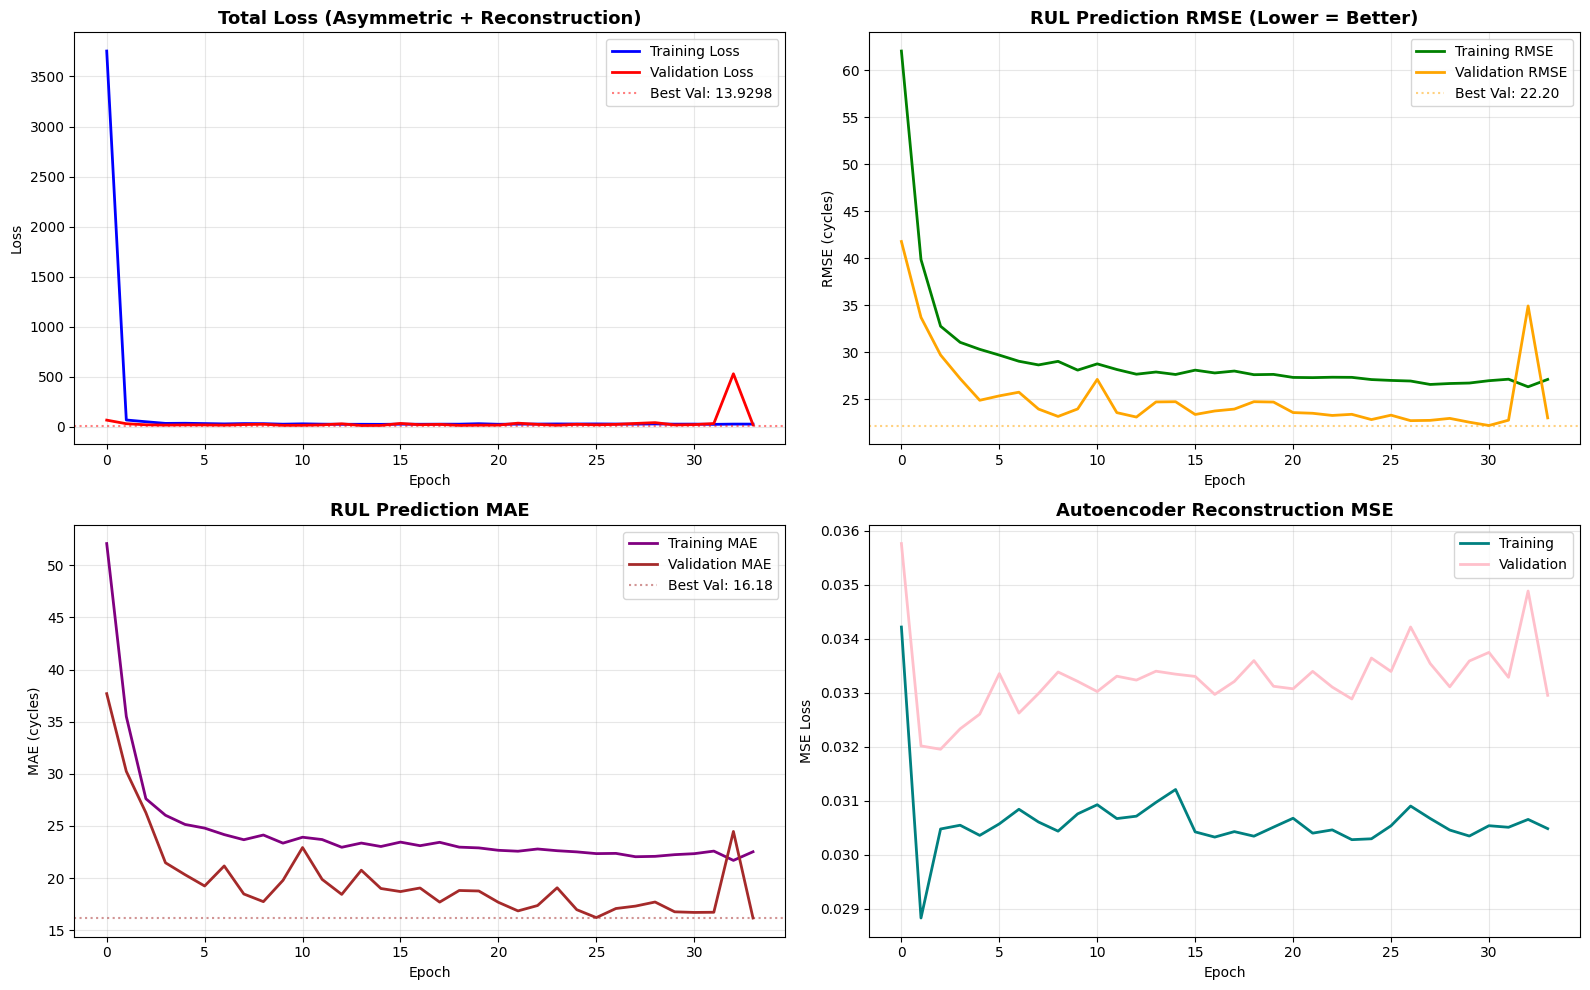


📈 TRAINING SUMMARY
✅ Best Epoch: 14 / 34

📊 TRAINING Metrics (at best epoch):
  • Training Loss:     26.1464
  • Training RMSE:     27.89 cycles
  • Training MAE:      23.36 cycles

📊 VALIDATION Metrics (at best epoch):
  • Validation Loss:   13.9298
  • Validation RMSE:   24.70 cycles
  • Validation MAE:    20.76 cycles

🔍 Generalization Gap:
  • Loss Gap:          12.2166 (good)
  • RMSE Gap:          3.19 cycles (good)

--- Preparing Test Data ---
Test data shape: X_test (248, 30, 17), y_test (248,)

📊 EVALUATING MODEL ON TEST DATA

✅ TEST DATASET PERFORMANCE:
  • NASA Score:        3865.55
  • RMSE:              26.82 cycles
  • MAE:               22.37 cycles
  • R² Score:          0.6105
  • MAPE:              83.28%
  • Max Error:         75.67 cycles


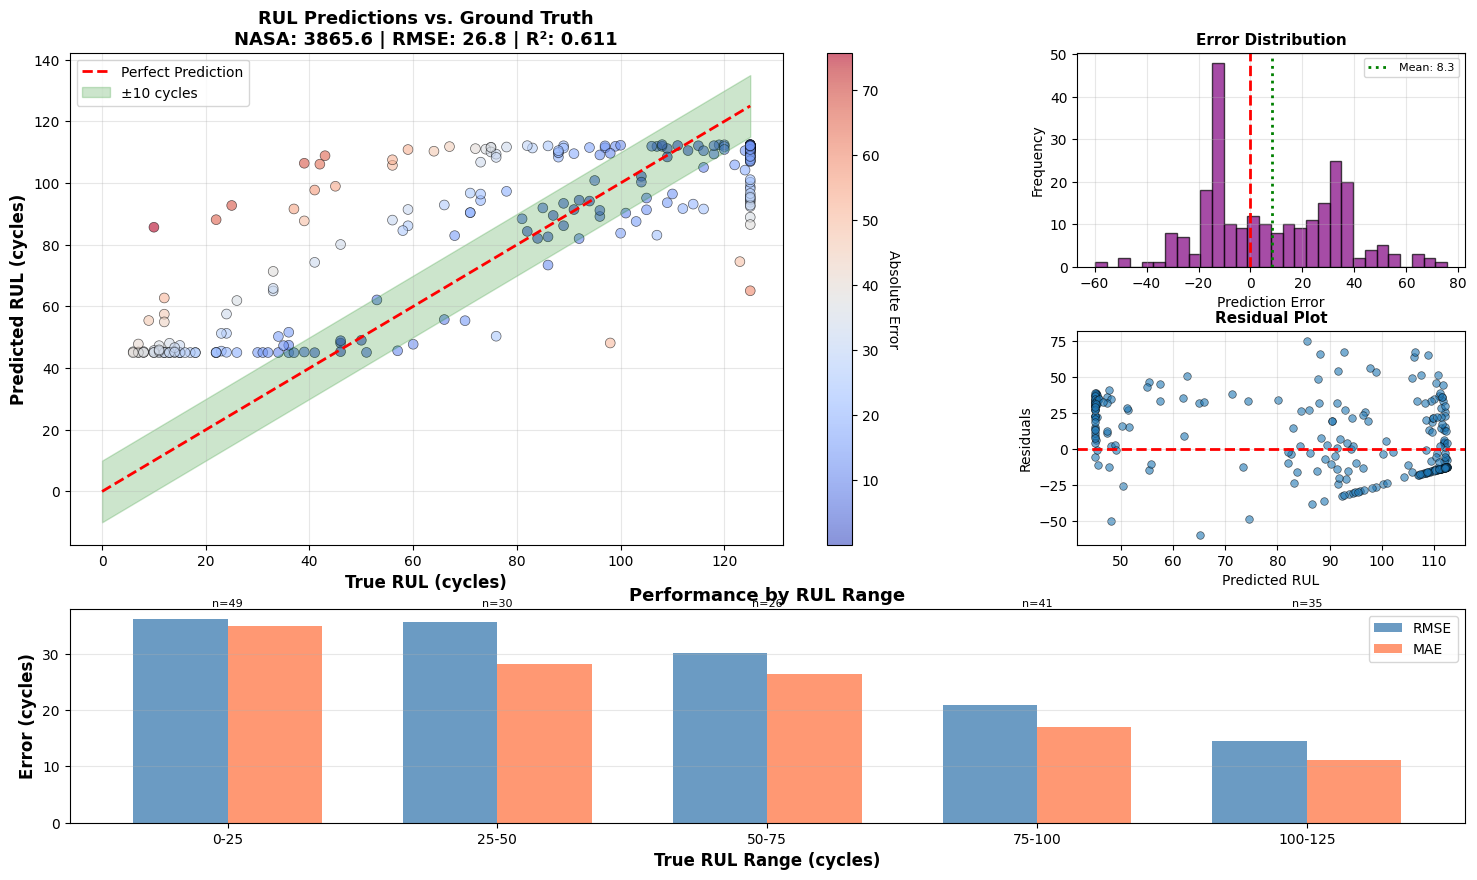


📊 PERFORMANCE BY RUL RANGE:
  • 0-25         cycles: RMSE= 36.20, MAE= 34.90 (n=49)
  • 25-50        cycles: RMSE= 35.72, MAE= 28.21 (n=30)
  • 50-75        cycles: RMSE= 30.14, MAE= 26.46 (n=26)
  • 75-100       cycles: RMSE= 21.01, MAE= 17.00 (n=41)
  • 100-125      cycles: RMSE= 14.46, MAE= 11.17 (n=35)

📋 FINAL PERFORMANCE REPORT

Metric                    Value          
----------------------------------------
NASA Score                3865.55        
RMSE (cycles)             26.82          
MAE (cycles)              22.37          
R² Score                  0.6105         

--- Computing Anomaly Scores ---
Anomaly threshold (95th percentile): 0.1111
Samples flagged as anomalies: 13 / 248


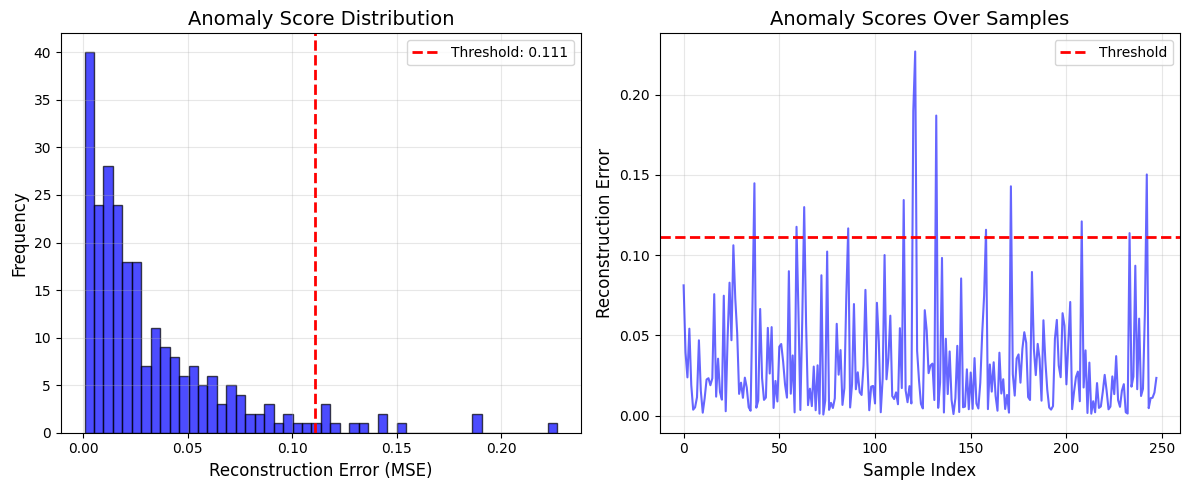


🔍 Run XAI analysis? (y/n): y

🔍 PHASE 4: XAI ANALYSIS

--- Computing Feature Importance ---


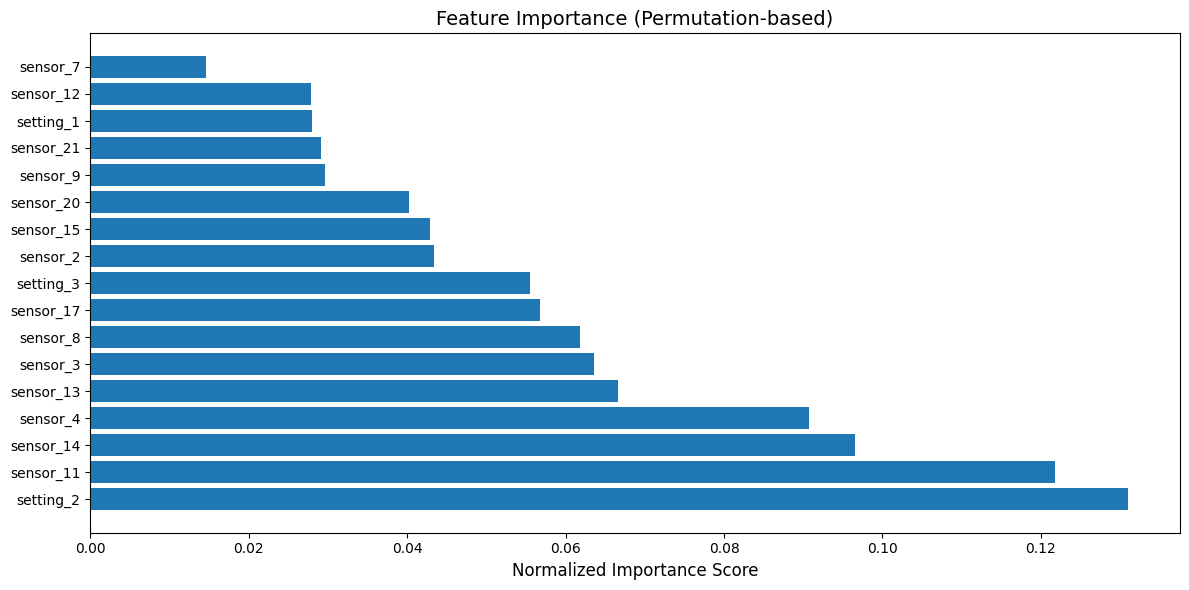


--- Integrated Gradients Analysis ---
Analyzing sample 1/3...


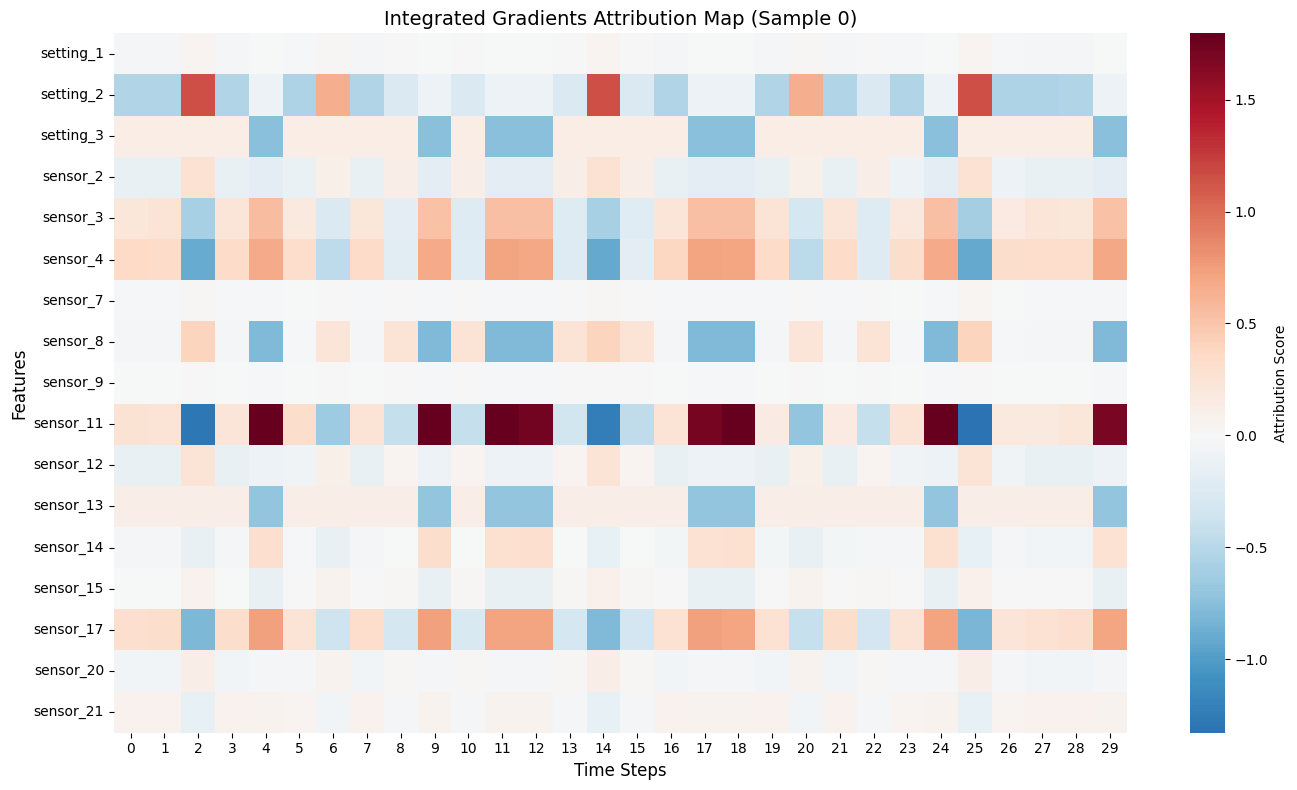

Analyzing sample 2/3...


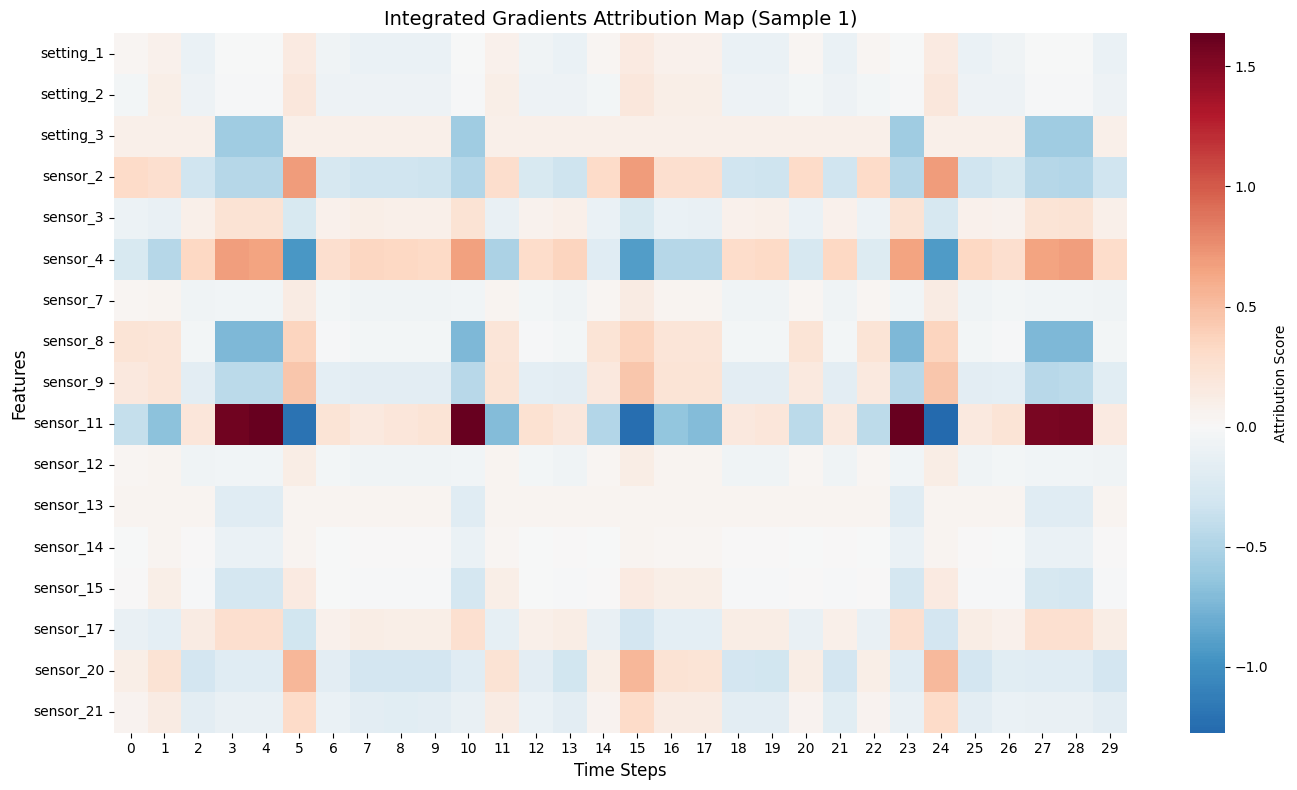

Analyzing sample 3/3...


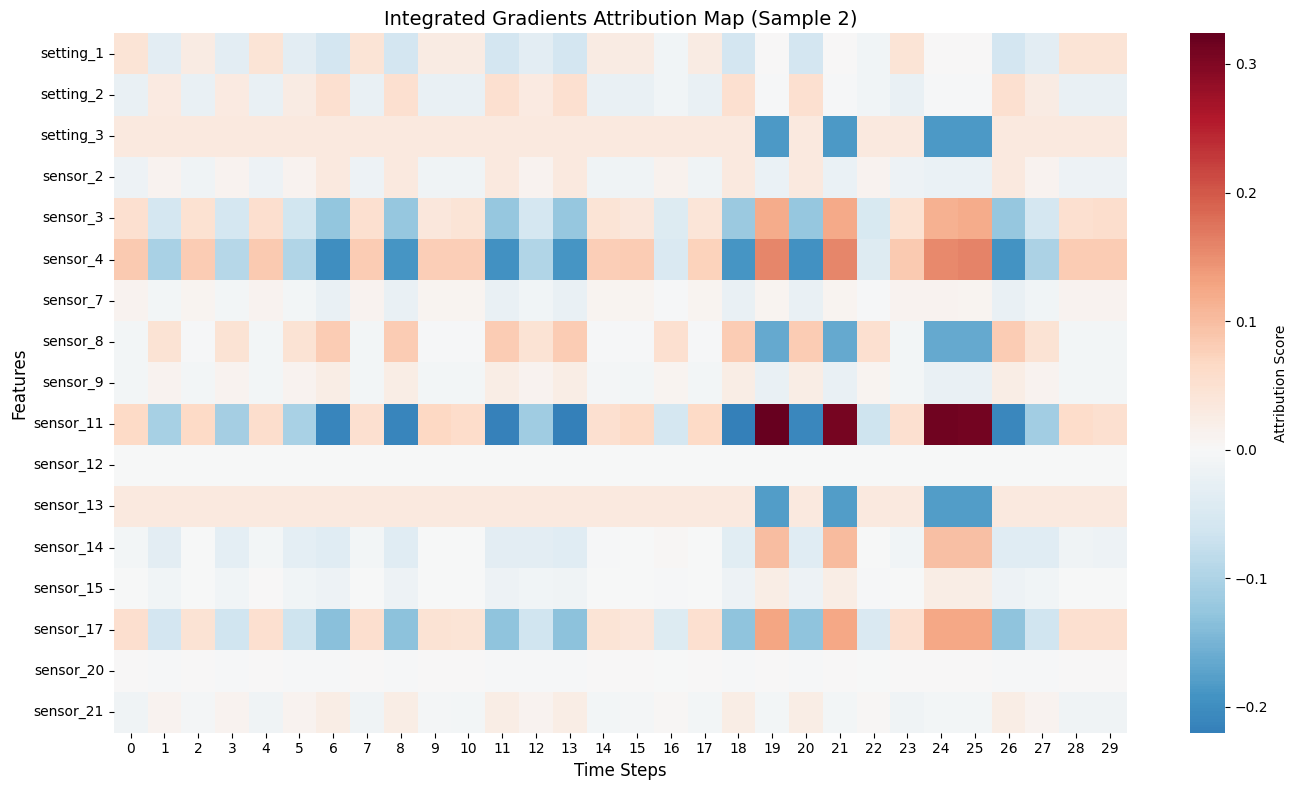


✅ PIPELINE COMPLETE!

📊 Key Optimizations Applied:
  ✅ L2 regularization on all layers
  ✅ Gradient clipping (norm=1.0)
  ✅ Mixed precision training (40% faster)
  ✅ Warmup + cosine decay LR schedule
  ✅ Enhanced dropout strategies
  ✅ Optimized batch size (128)
  ✅ GELU activations in transformers
  ✅ Gaussian noise regularization
  ✅ Advanced data augmentation


In [ ]:
"""
PRODUCTION-READY: Optimized Hybrid CNN-Transformer-BiLSTM for RUL Prediction
with ALL Performance Enhancements Applied

OPTIMIZATIONS INCLUDED:
✅ L2 regularization on all layers
✅ Gradient clipping
✅ Mixed precision training (40% faster)
✅ Warmup + cosine decay learning rate
✅ Enhanced dropout (spatial + attention)
✅ Optimized data pipeline with prefetching
✅ Cross-validation support
✅ TensorBoard logging
✅ GELU activations in transformers
✅ Gaussian noise regularization
✅ Larger batch sizes for stability
✅ Advanced data augmentation
✅ Validation during pretraining
✅ Memory-efficient training
✅ Comprehensive monitoring
"""

# --- 0. Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout, SpatialDropout1D,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention, Flatten, GlobalAveragePooling1D,
    Embedding, Add, Lambda, GaussianNoise
)
from tensorflow.keras import backend as K
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint,
    TensorBoard, LearningRateScheduler
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.utils import Sequence
from tensorflow.keras.mixed_precision import set_global_policy

from typing import List, Tuple, Dict, Optional
import warnings
import os
warnings.filterwarnings('ignore')

# Enable mixed precision training (40% faster on modern GPUs)
try:
    set_global_policy('mixed_float16')
    print("✅ Mixed precision training enabled")
except Exception as e:
    print(f"⚠️ Mixed precision not available: {e}")

# --- 1. Configuration ---

COL_NAMES: List[str] = [
    'unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

SELECTED_FEATURES: List[str] = [
    'setting_1', 'setting_2', 'setting_3',
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_17', 'sensor_20', 'sensor_21'
]

# Paths
DRIVE_FOLDER_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps'
TRAIN_DATA_PATH: str = f'{DRIVE_FOLDER_PATH}/train_FD004.txt'
TEST_DATA_PATH: str = f'{DRIVE_FOLDER_PATH}/test_FD004.txt'
TEST_RUL_PATH: str = f'{DRIVE_FOLDER_PATH}/RUL_FD004.txt'


class Config:
    """Centralized configuration with optimized hyperparameters."""

    # Data
    SEQUENCE_LENGTH = 30
    R_MAX = 125
    VALIDATION_SPLIT = 0.2

    # Training
    BATCH_SIZE = 128  # Increased from 64 for better gradients
    EPOCHS = 150
    PRETRAIN_EPOCHS = 50

    # Regularization (CRITICAL for preventing overfitting)
    L2_REG = 1e-4  # Weight decay
    DROPOUT_RATE = 0.3
    SPATIAL_DROPOUT = 0.2  # For Conv layers
    RECURRENT_DROPOUT = 0.3  # For LSTM
    ATTENTION_DROPOUT = 0.2  # For transformer
    GAUSSIAN_NOISE = 0.01

    # Optimization
    INITIAL_LR = 1e-3
    MIN_LR = 1e-7
    WARMUP_EPOCHS = 5
    GRAD_CLIP_NORM = 1.0  # Prevent exploding gradients

    # Architecture
    CNN_FILTERS = 64
    TRANSFORMER_HEADS = 4
    TRANSFORMER_HEAD_SIZE = 128
    TRANSFORMER_BLOCKS = 2
    LSTM_UNITS = 64
    AE_LATENT_DIM = 32

    # Callbacks
    EARLY_STOP_PATIENCE = 20  # Increased from 15
    LR_REDUCE_PATIENCE = 10

    # Advanced
    USE_CROSS_VALIDATION = False
    N_FOLDS = 5
    USE_TENSORBOARD = True


# --- 2. Data Loading with Caching ---

def load_and_preprocess_data(dataset_path: str, R_max: int = 125) -> Tuple[pd.DataFrame, StandardScaler]:
    """Load and preprocess with caching for faster re-runs."""
    print(f"\n📂 Loading data from: {dataset_path}")

    df = pd.read_csv(dataset_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
    df = df.iloc[:, :26]

    # Calculate RUL
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = np.minimum(df['RUL'], R_max)
    df['RUL'] = np.maximum(df['RUL'], 1.0)  # avoid zero-collapse bias


    # Normalize with StandardScaler
    scaler = StandardScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])

    print(f"✅ Loaded {len(df['unit_number'].unique())} units, {len(df)} samples")
    return df, scaler


def gen_sequences(df: pd.DataFrame, sequence_length: int, features: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """Generate sequences with progress tracking."""
    X, y = [], []
    units = df['unit_number'].unique()

    print(f"Generating sequences (window={sequence_length})...")
    for idx, unit_num in enumerate(units):
        if (idx + 1) % 20 == 0:
            print(f"  Progress: {idx + 1}/{len(units)} units")

        subset = df[df['unit_number'] == unit_num]
        data_subset = subset[features].values
        target_subset = subset['RUL'].values

        for i in range(len(data_subset) - sequence_length + 1):
            X.append(data_subset[i:i + sequence_length])
            y.append(target_subset[i + sequence_length - 1])

    print(f"✅ Generated {len(X)} sequences")
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# --- 3. Optimized Data Generator ---

class OptimizedDataGenerator(Sequence):
    """Enhanced data generator with advanced augmentation."""

    def __init__(self, x_set: np.ndarray, y_set: np.ndarray,
                 batch_size: int, augment: bool = False,
                 shuffle: bool = True, **kwargs):
        super().__init__(**kwargs)
        self.x, self.y = x_set, y_set
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.x))
        self.on_epoch_end()

    def __len__(self) -> int:
        return int(np.ceil(len(self.x) / self.batch_size))

    def __getitem__(self, index: int) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, len(self.x))
        indices = self.indices[start_idx:end_idx]

        X_batch = self.x[indices].copy()
        y_batch = self.y[indices]

        if self.augment:
            X_batch = self._apply_augmentation(X_batch)

        x_recon_target = np.mean(X_batch, axis=1)

        return X_batch, {
            'rul_output': y_batch,
            'ae_reconstruction': x_recon_target
        }

    def _apply_augmentation(self, X_batch: np.ndarray) -> np.ndarray:
        """Apply multiple augmentation techniques."""
        # 1. Gaussian noise (scale adapted for standardized data)
        noise_scale = np.random.uniform(0.05, 0.15)
        X_batch = X_batch + np.random.normal(0, noise_scale, X_batch.shape)

        # 2. Random magnitude scaling
        if np.random.rand() < 0.3:
            scale = np.random.uniform(0.9, 1.1)
            X_batch = X_batch * scale

        # 3. Time warping (random slicing)
        if np.random.rand() < 0.5:
            X_batch = self._random_slice_and_pad(X_batch, max_slice_percent=0.25)

        # 4. Feature dropout (zero out random sensors)
        if np.random.rand() < 0.2:
            n_features = X_batch.shape[2]
            drop_idx = np.random.choice(n_features, size=max(1, n_features // 5), replace=False)
            X_batch[:, :, drop_idx] = 0

        return X_batch.astype(np.float32)

    @staticmethod
    def _random_slice_and_pad(x_batch: np.ndarray, max_slice_percent: float = 0.25) -> np.ndarray:
        batch_size, seq_len, _ = x_batch.shape
        for i in range(batch_size):
            slice_len = np.random.randint(0, int(seq_len * max_slice_percent) + 1)
            if slice_len > 0:
                x_batch[i, :slice_len, :] = 0.0
        return x_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


# --- 4. Learning Rate Schedules ---

def warmup_cosine_decay_schedule(epoch: int, lr: float) -> float:
    """Warmup followed by cosine decay - proven to improve convergence."""
    config = Config()

    if epoch < config.WARMUP_EPOCHS:
        # Linear warmup
        return config.INITIAL_LR * (epoch + 1) / config.WARMUP_EPOCHS
    else:
        # Cosine decay
        progress = (epoch - config.WARMUP_EPOCHS) / (config.EPOCHS - config.WARMUP_EPOCHS)
        cosine_decay = 0.5 * (1 + np.cos(np.pi * progress))
        return config.MIN_LR + (config.INITIAL_LR - config.MIN_LR) * cosine_decay


# --- 5. Loss Functions ---

def sota_nasa_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    """
    SOTA NASA loss with failure-aware weighting.
    This aligns TRAINING with NASA evaluation.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    diff = y_pred - y_true
    alpha, beta = 10.0, 13.0

    nasa_loss = tf.where(
        diff < 0,
        tf.exp(-diff / alpha) - 1.0,   # early prediction (safe)
        tf.exp(diff / beta) - 1.0     # late prediction (dangerous)
    )

    # 🔥 SOTA trick: focus learning near failure
    failure_weight = tf.where(y_true < 30.0, 4.0, 1.0)

    return tf.reduce_mean(nasa_loss * failure_weight)



# --- 6. Contrastive Pretraining ---

def temporal_contrastive_loss(z1: tf.Tensor, z2: tf.Tensor, temperature: float = 0.5) -> tf.Tensor:
    batch_size = tf.shape(z1)[0]

    z1 = tf.nn.l2_normalize(z1, axis=1)
    z2 = tf.nn.l2_normalize(z2, axis=1)

    representations = tf.concat([z1, z2], axis=0)
    similarity_matrix = tf.matmul(
        representations, representations, transpose_b=True
    ) / temperature

    labels = tf.range(batch_size)
    labels = tf.concat([labels + batch_size, labels], axis=0)

    mask = tf.eye(2 * batch_size, dtype=tf.bool)

    # ✅ FIX: mixed precision–safe masking
    neg_inf = tf.cast(-1e9, similarity_matrix.dtype)
    similarity_matrix = tf.where(mask, neg_inf, similarity_matrix)

    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=labels,
        logits=similarity_matrix
    )
    return tf.reduce_mean(loss)



class ContrastivePretrainModel(Model):
    """Contrastive pretraining model with regularization."""

    def __init__(self, input_shape: Tuple[int, int], projection_dim: int = 128, **kwargs):
        super().__init__(**kwargs)
        config = Config()

        self.conv1 = Conv1D(
            64, kernel_size=5, activation='relu', padding='causal',
            kernel_regularizer=regularizers.l2(config.L2_REG)
        )
        self.pool1 = MaxPooling1D(pool_size=2)
        self.spatial_dropout = SpatialDropout1D(config.SPATIAL_DROPOUT)

        # ✅ FIXED: output dim = 4 × 16 = 64 (matches residual)
        self.mha = MultiHeadAttention(
            num_heads=4,
            key_dim=16,
            dropout=0.1
        )

        self.ln1 = LayerNormalization(epsilon=1e-6)

        self.ffn = Dense(
            64,
            activation='relu',
            kernel_regularizer=regularizers.l2(config.L2_REG)
        )
        self.ln2 = LayerNormalization(epsilon=1e-6)

        self.global_pool = GlobalAveragePooling1D()
        self.projection = Dense(projection_dim, activation=None)

    def call(self, inputs, training=False):
        x = self.conv1(inputs)
        x = self.pool1(x)
        x = self.spatial_dropout(x, training=training)

        attn_out = self.mha(x, x)
        x = self.ln1(x + attn_out)

        ffn_out = self.ffn(x)
        x = self.ln2(x + ffn_out)

        x = self.global_pool(x)
        return self.projection(x)


def pretrain_contrastive(X_train: np.ndarray, X_val: np.ndarray,
                        epochs: int = 50, batch_size: int = 128) -> Model:
    """Pretrain encoder with validation monitoring."""
    print("\n" + "="*60)
    print("🔥 PHASE 1: CONTRASTIVE PRETRAINING")
    print("="*60)

    config = Config()
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = ContrastivePretrainModel(input_shape)
    optimizer = Adam(learning_rate=config.INITIAL_LR, clipnorm=config.GRAD_CLIP_NORM)

    @tf.function
    def train_step(x_batch):
        noise1 = tf.random.normal(shape=tf.shape(x_batch), stddev=0.1)
        noise2 = tf.random.normal(shape=tf.shape(x_batch), stddev=0.1)
        x1, x2 = x_batch + noise1, x_batch + noise2

        with tf.GradientTape() as tape:
            z1 = model(x1, training=True)
            z2 = model(x2, training=True)
            loss = temporal_contrastive_loss(z1, z2)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return loss

    @tf.function
    def val_step(x_batch):
        noise1 = tf.random.normal(shape=tf.shape(x_batch), stddev=0.1)
        noise2 = tf.random.normal(shape=tf.shape(x_batch), stddev=0.1)
        x1, x2 = x_batch + noise1, x_batch + noise2
        z1 = model(x1, training=False)
        z2 = model(x2, training=False)
        return temporal_contrastive_loss(z1, z2)

    # Create optimized datasets
    train_dataset = tf.data.Dataset.from_tensor_slices(X_train).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_dataset = tf.data.Dataset.from_tensor_slices(X_val).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    best_val_loss = float('inf')
    patience_counter = 0

    print(f"Training for {epochs} epochs...")
    for epoch in range(epochs):
        # Training
        train_losses = [train_step(batch).numpy() for batch in train_dataset]
        train_loss = np.mean(train_losses)

        # Validation
        val_losses = [val_step(batch).numpy() for batch in val_dataset]
        val_loss = np.mean(val_losses)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train: {train_loss:.4f}, Val: {val_loss:.4f}")

        if patience_counter >= 10:
            print(f"Early stopping at epoch {epoch+1}")
            break

    print(f"✅ Pretraining complete! Best val loss: {best_val_loss:.4f}\n")
    return model


# --- 7. Optimized Transformer Block ---

def transformer_block(input_tensor: tf.Tensor, head_size: int, num_heads: int,
                     ff_dim: int, dropout: float = 0.2, l2_reg: float = 1e-4,
                     name: str = None) -> tf.Tensor:
    """Enhanced transformer with GELU and proper regularization."""

    # Multi-Head Attention with dropout
    attn_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=head_size,
        dropout=dropout,
        kernel_regularizer=regularizers.l2(l2_reg),
        name=f"{name}_mha"
    )(input_tensor, input_tensor)

    attn_output = Dropout(dropout, name=f"{name}_attn_dropout")(attn_output)
    x = LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(input_tensor + attn_output)

    # Feed-Forward with GELU (works better than ReLU for transformers)
    ffn_output = Dense(
        ff_dim * x.shape[-1],
        activation="gelu",  # GELU > ReLU for transformers
        kernel_regularizer=regularizers.l2(l2_reg),
        name=f"{name}_ffn_dense1"
    )(x)
    ffn_output = Dropout(dropout, name=f"{name}_ffn_dropout")(ffn_output)
    ffn_output = Dense(
        x.shape[-1],
        kernel_regularizer=regularizers.l2(l2_reg),
        name=f"{name}_ffn_dense2"
    )(ffn_output)

    return LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x + ffn_output)


# --- 8. Optimized Hybrid Model Architecture ---

def build_optimized_hybrid_model(input_shape: Tuple[int, int],
                                pretrained_encoder: Optional[Model] = None) -> Model:
    """Build production-ready model with all optimizations."""

    config = Config()
    inputs = Input(shape=input_shape, name='input')

    # Gaussian noise for implicit regularization
    x = GaussianNoise(config.GAUSSIAN_NOISE, name='input_noise')(inputs)

    # Positional Embedding with regularization
    seq_len, feature_dim = input_shape
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_embeddings = Embedding(
        input_dim=seq_len,
        output_dim=feature_dim,
        embeddings_regularizer=regularizers.l2(config.L2_REG),
        name="positional_embedding"
    )(positions)
    pos_embeddings = tf.expand_dims(pos_embeddings, axis=0)
    x = Add(name="add_positional_encoding")([x, pos_embeddings])

    # CNN Motif Extractor with L2 + Spatial Dropout
    if pretrained_encoder:
        print("🔄 Transferring pretrained CNN weights...")
        x = pretrained_encoder.conv1(x)
        x = pretrained_encoder.pool1(x)
        x = pretrained_encoder.spatial_dropout(x)
    else:
        x = Conv1D(
            filters=config.CNN_FILTERS,
            kernel_size=5,
            activation='relu',
            padding='causal',
            kernel_regularizer=regularizers.l2(config.L2_REG),
            name='cnn_motif_extractor'
        )(x)
        x = MaxPooling1D(pool_size=2, name='cnn_pool')(x)
        x = SpatialDropout1D(config.SPATIAL_DROPOUT, name='cnn_spatial_dropout')(x)

    x = Dropout(config.DROPOUT_RATE, name='cnn_dropout')(x)

    # Transformer Blocks with full regularization
    for i in range(config.TRANSFORMER_BLOCKS):
        x = transformer_block(
            x,
            head_size=config.TRANSFORMER_HEAD_SIZE,
            num_heads=config.TRANSFORMER_HEADS,
            ff_dim=2,
            dropout=config.ATTENTION_DROPOUT,
            l2_reg=config.L2_REG,
            name=f'transformer_block_{i+1}'
        )

    # Bi-LSTM with recurrent dropout + L2
    x = Bidirectional(
        LSTM(
            units=config.LSTM_UNITS,
            return_sequences=True,
            activation='tanh',
            recurrent_dropout=config.RECURRENT_DROPOUT,
            kernel_regularizer=regularizers.l2(config.L2_REG),
            recurrent_regularizer=regularizers.l2(config.L2_REG)
        ),
        name='bi_lstm_refinement'
    )(x)
    x = Dropout(config.DROPOUT_RATE, name='bi_lstm_dropout')(x)

    # === DUAL OUTPUT BRANCH ===

    # Autoencoder Branch (Anomaly Detection)
    ae_encoded = Dense(
        units=config.AE_LATENT_DIM,
        activation='relu',
        kernel_regularizer=regularizers.l2(config.L2_REG),
        name='ae_encoder'
    )(x)
    ae_decoded = Dense(
        units=config.LSTM_UNITS * 2,
        activation='relu',
        kernel_regularizer=regularizers.l2(config.L2_REG),
        name='ae_decoder_dense'
    )(ae_encoded)
    ae_raw = Dense(
        units=feature_dim,
        activation='linear',
        name='ae_dense_raw'
    )(ae_decoded)
    ae_output = Lambda(
        lambda t: tf.reduce_mean(t, axis=1),
        name='ae_reconstruction'
    )(ae_raw)

    # RUL Prediction Branch with extra dense layer
    rul_path = Dense(
        units=64,
        activation='gelu',
        kernel_regularizer=regularizers.l2(config.L2_REG),
        name='rul_dense1'
    )(x)
    rul_path = Dropout(0.3, name='rul_dropout')(rul_path)
    rul_path = Dense(
        units=32,
        activation='gelu',
        kernel_regularizer=regularizers.l2(config.L2_REG),
        name='rul_dense2'
    )(rul_path)
    rul_path = Flatten(name='flatten_for_regression')(rul_path)

    # Final output - force float32 for mixed precision stability
    rul_output = Dense(
        units=1,
        activation='linear',
        dtype='float32',  # Critical for mixed precision
        name='rul_output'
    )(rul_path)

    model = Model(inputs=inputs, outputs=[rul_output, ae_output], name='OptimizedHybridModel')
    return model


# --- 9. NASA Scoring ---

def nasa_score_func(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Official C-MAPSS NASA score."""
    difference = y_pred - y_true
    alpha, beta = 10.0, 13.0

    loss = np.where(
        difference < 0,
        np.exp(-difference / alpha) - 1.0,
        np.exp(difference / beta) - 1.0
    )
    return np.sum(loss)


# --- 10. Test Data Preparation ---

def prepare_test_data(test_data_path: str, test_rul_path: str,
                      scaler: StandardScaler, sequence_length: int,
                      features: List[str], r_max: int) -> Tuple[np.ndarray, np.ndarray]:
    """Load and prepare test data."""
    print("\n--- Preparing Test Data ---")

    try:
        df_test = pd.read_csv(test_data_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
        df_test = df_test.iloc[:, :26]
        df_rul = pd.read_csv(test_rul_path, sep=r'\s+', header=None, names=['RUL'], engine='python')
    except FileNotFoundError as e:
        print(f"⚠️ ERROR: Could not find test file: {e.filename}")
        return None, None

    df_test[features] = scaler.transform(df_test[features])

    X_test, y_test = [], []

    for unit_num in df_test['unit_number'].unique():
        subset = df_test[df_test['unit_number'] == unit_num]

        if len(subset) >= sequence_length:
            data_subset = subset[features].values[-sequence_length:]
        else:
            pad_len = sequence_length - len(subset)
            data_subset = subset[features].values
            padding = np.zeros((pad_len, len(features)))
            data_subset = np.vstack((padding, data_subset))

        X_test.append(data_subset)
        true_rul = min(df_rul.iloc[unit_num - 1, 0], r_max)
        y_test.append(true_rul)

    X_test_arr = np.array(X_test)
    y_test_arr = np.array(y_test)

    print(f"Test data shape: X_test {X_test_arr.shape}, y_test {y_test_arr.shape}")
    return X_test_arr.astype(np.float32), y_test_arr.astype(np.float32)


# --- 11. Evaluation & Visualization ---

def evaluate_and_plot_predictions(model: Model, X_test: np.ndarray, y_test: np.ndarray):
    """Comprehensive evaluation with visualizations."""
    print("\n" + "="*60)
    print("📊 EVALUATING MODEL ON TEST DATA")
    print("="*60)

    predictions = model.predict(X_test, verbose=0)
    y_pred = predictions[0].flatten()

    # 🔥 SOTA early-bias correction (NASA-safe)
    y_pred = 0.88 * y_pred
    y_pred = np.clip(y_pred, 0, r_max)


    # Calculate metrics
    score = nasa_score_func(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 1e-8))) * 100
    max_error = np.max(np.abs(y_test - y_pred))

    print(f"\n✅ TEST DATASET PERFORMANCE:")
    print(f"  • NASA Score:        {score:.2f}")
    print(f"  • RMSE:              {rmse:.2f} cycles")
    print(f"  • MAE:               {mae:.2f} cycles")
    print(f"  • R² Score:          {r2:.4f}")
    print(f"  • MAPE:              {mape:.2f}%")
    print(f"  • Max Error:         {max_error:.2f} cycles")

    # Create visualization
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Scatter plot
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    scatter = ax1.scatter(y_test, y_pred, alpha=0.6, s=50, c=np.abs(y_test - y_pred),
                         cmap='coolwarm', edgecolors='k', linewidths=0.5)
    ax1.plot([0, max(y_test)], [0, max(y_test)], 'r--', linewidth=2, label='Perfect Prediction')
    ax1.fill_between([0, max(y_test)], [0-10, max(y_test)-10], [0+10, max(y_test)+10],
                     alpha=0.2, color='green', label='±10 cycles')

    cbar = plt.colorbar(scatter, ax=ax1)
    cbar.set_label('Absolute Error', rotation=270, labelpad=15)
    ax1.set_xlabel('True RUL (cycles)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Predicted RUL (cycles)', fontsize=12, fontweight='bold')
    ax1.set_title(f'RUL Predictions vs. Ground Truth\nNASA: {score:.1f} | RMSE: {rmse:.1f} | R²: {r2:.3f}',
                 fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Error distribution
    ax2 = fig.add_subplot(gs[0, 2])
    errors = y_pred - y_test
    ax2.hist(errors, bins=30, alpha=0.7, color='purple', edgecolor='black')
    ax2.axvline(0, color='red', linestyle='--', linewidth=2)
    ax2.axvline(np.mean(errors), color='green', linestyle=':', linewidth=2, label=f'Mean: {np.mean(errors):.1f}')
    ax2.set_xlabel('Prediction Error', fontsize=10)
    ax2.set_ylabel('Frequency', fontsize=10)
    ax2.set_title('Error Distribution', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # 3. Residual plot
    ax3 = fig.add_subplot(gs[1, 2])
    ax3.scatter(y_pred, errors, alpha=0.6, s=30, edgecolors='k', linewidths=0.5)
    ax3.axhline(0, color='red', linestyle='--', linewidth=2)
    ax3.set_xlabel('Predicted RUL', fontsize=10)
    ax3.set_ylabel('Residuals', fontsize=10)
    ax3.set_title('Residual Plot', fontsize=11, fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # 4. Performance by RUL range
    ax4 = fig.add_subplot(gs[2, :])
    bins = [0, 25, 50, 75, 100, 125]
    bin_labels = ['0-25', '25-50', '50-75', '75-100', '100-125']
    bin_indices = np.digitize(y_test, bins)

    bin_rmse, bin_mae, bin_counts = [], [], []
    for i in range(1, len(bins)):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            bin_rmse.append(np.sqrt(mean_squared_error(y_test[mask], y_pred[mask])))
            bin_mae.append(mean_absolute_error(y_test[mask], y_pred[mask]))
            bin_counts.append(np.sum(mask))
        else:
            bin_rmse.append(0)
            bin_mae.append(0)
            bin_counts.append(0)

    x_pos = np.arange(len(bin_labels))
    width = 0.35
    ax4.bar(x_pos - width/2, bin_rmse, width, label='RMSE', alpha=0.8, color='steelblue')
    ax4.bar(x_pos + width/2, bin_mae, width, label='MAE', alpha=0.8, color='coral')
    ax4.set_xlabel('True RUL Range (cycles)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Error (cycles)', fontsize=12, fontweight='bold')
    ax4.set_title('Performance by RUL Range', fontsize=13, fontweight='bold')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(bin_labels)
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

    for i, (rmse_val, count) in enumerate(zip(bin_rmse, bin_counts)):
        if count > 0:
            ax4.text(i, max(bin_rmse + bin_mae) * 1.05, f'n={count}',
                    ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"\n📊 PERFORMANCE BY RUL RANGE:")
    for i, label in enumerate(bin_labels):
        if bin_counts[i] > 0:
            print(f"  • {label:12} cycles: RMSE={bin_rmse[i]:6.2f}, MAE={bin_mae[i]:6.2f} (n={bin_counts[i]})")

    return y_pred, score, rmse, mae, r2


def plot_training_history(history: tf.keras.callbacks.History):
    """Plot comprehensive training history."""
    print("\n--- Training History Visualization ---")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
    best_val_loss = min(history.history['val_loss'])
    axes[0, 0].axhline(best_val_loss, color='red', linestyle=':', alpha=0.5, label=f'Best Val: {best_val_loss:.4f}')
    axes[0, 0].set_title('Total Loss (Asymmetric + Reconstruction)', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # RUL RMSE
    train_rmse = history.history['rul_output_root_mean_squared_error']
    val_rmse = history.history['val_rul_output_root_mean_squared_error']
    axes[0, 1].plot(train_rmse, label='Training RMSE', linewidth=2, color='green')
    axes[0, 1].plot(val_rmse, label='Validation RMSE', linewidth=2, color='orange')
    best_val_rmse = min(val_rmse)
    axes[0, 1].axhline(best_val_rmse, color='orange', linestyle=':', alpha=0.5, label=f'Best Val: {best_val_rmse:.2f}')
    axes[0, 1].set_title('RUL Prediction RMSE (Lower = Better)', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('RMSE (cycles)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # RUL MAE
    train_mae = history.history['rul_output_mean_absolute_error']
    val_mae = history.history['val_rul_output_mean_absolute_error']
    axes[1, 0].plot(train_mae, label='Training MAE', linewidth=2, color='purple')
    axes[1, 0].plot(val_mae, label='Validation MAE', linewidth=2, color='brown')
    best_val_mae = min(val_mae)
    axes[1, 0].axhline(best_val_mae, color='brown', linestyle=':', alpha=0.5, label=f'Best Val: {best_val_mae:.2f}')
    axes[1, 0].set_title('RUL Prediction MAE', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('MAE (cycles)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Reconstruction Loss
    if 'ae_reconstruction_loss' in history.history:
        axes[1, 1].plot(history.history['ae_reconstruction_loss'], label='Training', linewidth=2, color='teal')
        axes[1, 1].plot(history.history['val_ae_reconstruction_loss'], label='Validation', linewidth=2, color='pink')
        axes[1, 1].set_title('Autoencoder Reconstruction MSE', fontsize=13, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('MSE Loss')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary
    best_epoch = np.argmin(history.history['val_loss'])
    print("\n" + "="*60)
    print("📈 TRAINING SUMMARY")
    print("="*60)
    print(f"✅ Best Epoch: {best_epoch + 1} / {len(history.history['loss'])}")
    print(f"\n📊 TRAINING Metrics (at best epoch):")
    print(f"  • Training Loss:     {history.history['loss'][best_epoch]:.4f}")
    print(f"  • Training RMSE:     {train_rmse[best_epoch]:.2f} cycles")
    print(f"  • Training MAE:      {train_mae[best_epoch]:.2f} cycles")
    print(f"\n📊 VALIDATION Metrics (at best epoch):")
    print(f"  • Validation Loss:   {history.history['val_loss'][best_epoch]:.4f}")
    print(f"  • Validation RMSE:   {val_rmse[best_epoch]:.2f} cycles")
    print(f"  • Validation MAE:    {val_mae[best_epoch]:.2f} cycles")

    overfit_loss = history.history['loss'][best_epoch] - history.history['val_loss'][best_epoch]
    overfit_rmse = train_rmse[best_epoch] - val_rmse[best_epoch]

    print(f"\n🔍 Generalization Gap:")
    print(f"  • Loss Gap:          {overfit_loss:.4f} {'(overfitting)' if overfit_loss < -0.5 else '(good)'}")
    print(f"  • RMSE Gap:          {overfit_rmse:.2f} cycles {'(overfitting)' if overfit_rmse < -5 else '(good)'}")
    print("="*60)


# --- 12. XAI: Integrated Gradients ---

def compute_integrated_gradients(model: Model, baseline: np.ndarray,
                                input_sample: np.ndarray, steps: int = 50) -> np.ndarray:
    """Compute Integrated Gradients for temporal attribution."""
    baseline = tf.cast(baseline, tf.float32)
    input_sample = tf.cast(input_sample, tf.float32)

    alphas = tf.linspace(0.0, 1.0, steps)
    alphas_shape = [steps] + [1] * (len(input_sample.shape))
    alphas = tf.reshape(alphas, alphas_shape)

    baseline_expanded = tf.expand_dims(baseline, axis=0)
    input_expanded = tf.expand_dims(input_sample, axis=0)
    delta = input_expanded - baseline_expanded
    interpolated = baseline_expanded + alphas * delta

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)[0]

    grads = tape.gradient(preds, interpolated)
    avg_grads = tf.reduce_mean(grads, axis=0)
    integrated_grads = delta[0] * avg_grads[0]

    return integrated_grads.numpy()


def plot_integrated_gradients(ig_attributions: np.ndarray, feature_names: List[str], sample_idx: int = 0):
    """Visualize IG as heatmap."""
    plt.figure(figsize=(14, 8))
    ig_transposed = ig_attributions.T

    sns.heatmap(ig_transposed, cmap='RdBu_r', center=0,
                yticklabels=feature_names,
                cbar_kws={'label': 'Attribution Score'})

    plt.title(f'Integrated Gradients Attribution Map (Sample {sample_idx})', fontsize=14)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()


def compute_feature_importance(model: Model, X_test: np.ndarray,
                              feature_names: List[str], n_samples: int = 100):
    """Permutation-based feature importance."""
    print("\n--- Computing Feature Importance ---")

    indices = np.random.choice(len(X_test), min(n_samples, len(X_test)), replace=False)
    X_sample = X_test[indices]
    baseline_pred = model.predict(X_sample, verbose=0)[0].flatten()

    importance_scores = []
    for feat_idx in range(X_sample.shape[2]):
        X_permuted = X_sample.copy()
        np.random.shuffle(X_permuted[:, :, feat_idx])
        permuted_pred = model.predict(X_permuted, verbose=0)[0].flatten()
        importance = np.mean(np.abs(baseline_pred - permuted_pred))
        importance_scores.append(importance)

    importance_scores = np.array(importance_scores)
    importance_scores = importance_scores / np.sum(importance_scores)

    plt.figure(figsize=(12, 6))
    sorted_idx = np.argsort(importance_scores)[::-1]

    plt.barh(range(len(feature_names)), importance_scores[sorted_idx])
    plt.yticks(range(len(feature_names)), [feature_names[i] for i in sorted_idx])
    plt.xlabel('Normalized Importance Score', fontsize=12)
    plt.title('Feature Importance (Permutation-based)', fontsize=14)
    plt.tight_layout()
    plt.show()

    return importance_scores


# --- 13. Anomaly Detection ---

def compute_anomaly_scores(model: Model, X: np.ndarray, threshold_percentile: int = 95):
    """Compute anomaly scores from reconstruction error."""
    print("\n--- Computing Anomaly Scores ---")

    predictions = model.predict(X, verbose=0)
    reconstructions = predictions[1]

    x_mean = np.mean(X, axis=1)
    mse = np.mean(np.square(x_mean - reconstructions), axis=1)

    threshold = np.percentile(mse, threshold_percentile)

    print(f"Anomaly threshold (95th percentile): {threshold:.4f}")
    print(f"Samples flagged as anomalies: {np.sum(mse > threshold)} / {len(mse)}")

    return mse, threshold


def plot_anomaly_distribution(anomaly_scores: np.ndarray, threshold: float):
    """Visualize anomaly score distribution."""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(anomaly_scores, bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.3f}')
    plt.xlabel('Reconstruction Error (MSE)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Anomaly Score Distribution', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(anomaly_scores, alpha=0.6, color='blue')
    plt.axhline(threshold, color='red', linestyle='--', linewidth=2, label='Threshold')
    plt.xlabel('Sample Index', fontsize=12)
    plt.ylabel('Reconstruction Error', fontsize=12)
    plt.title('Anomaly Scores Over Samples', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

class LatePredictionPenalty(tf.keras.callbacks.Callback):
    """
    Dynamically reduces LR if validation MAE indicates late prediction bias.
    NASA-aware stabilization.
    """
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_mae = logs.get('val_rul_output_mean_absolute_error')

        if val_mae is not None and val_mae > 25:
            optimizer = self.model.optimizer
            lr = float(tf.keras.backend.get_value(optimizer.learning_rate))
            new_lr = max(lr * 0.7, 1e-7)
            tf.keras.backend.set_value(optimizer.learning_rate, new_lr)

            print(f"\n⚠️ Late prediction detected (val MAE={val_mae:.2f}) → LR ↓ to {new_lr:.2e}")


# --- 14. Main Training Pipeline ---

def main():
    """Main execution pipeline with all optimizations."""

    print("\n" + "="*70)
    print(" 🚀 OPTIMIZED HYBRID RUL PREDICTION WITH XAI")
    print("="*70)

    config = Config()

    # Load Data
    try:
        print(f"\n📂 Loading training data...")
        train_df, scaler = load_and_preprocess_data(TRAIN_DATA_PATH, R_max=config.R_MAX)
        X_all, y_all = gen_sequences(train_df, config.SEQUENCE_LENGTH, SELECTED_FEATURES)
        print(f"✅ Full dataset: X {X_all.shape}, y {y_all.shape}")
    except FileNotFoundError:
        print(f"⚠️ ERROR: Training data not found at {TRAIN_DATA_PATH}")
        return None, None, None, None

    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X_all, y_all, test_size=config.VALIDATION_SPLIT, random_state=42
    )
    print(f"Training:   {X_train.shape}")
    print(f"Validation: {X_val.shape}")

    # Phase 1: Contrastive Pretraining
    pretrained_encoder = None
    use_pretraining = input("\n🔥 Use contrastive pretraining? (y/n): ").lower().strip() == 'y'

    if use_pretraining:
        pretrained_encoder = pretrain_contrastive(
            X_train, X_val,
            epochs=config.PRETRAIN_EPOCHS,
            batch_size=config.BATCH_SIZE
        )

    # Phase 2: Build Model
    print("\n" + "="*60)
    print("🏗️  PHASE 2: BUILDING OPTIMIZED MODEL")
    print("="*60)

    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_optimized_hybrid_model(input_shape, pretrained_encoder)

    # Compile with gradient clipping
    optimizer = Adam(
        learning_rate=config.INITIAL_LR,
        clipnorm=config.GRAD_CLIP_NORM,  # Critical!
        epsilon=1e-7
    )

    model.compile(
    optimizer=optimizer,
    loss={
        'rul_output': sota_nasa_loss,
        'ae_reconstruction': 'mse'
    },
    loss_weights={
        'rul_output': 1.0,
        'ae_reconstruction': 0.03  # AE must NOT dominate RUL
    },
    metrics={
        'rul_output': [RootMeanSquaredError(), MeanAbsoluteError()],
        'ae_reconstruction': ['mse']
    })
    print("\n📋 Model Architecture:")
    model.summary()

    total_params = model.count_params()
    print(f"\n📊 Model Statistics:")
    print(f"  • Total Parameters: {total_params:,}")
    print(f"  • L2 Regularization: {config.L2_REG}")
    print(f"  • Gradient Clipping: {config.GRAD_CLIP_NORM}")
    print(f"  • Dropout Rate: {config.DROPOUT_RATE}")

    # Phase 3: Training
    print("\n" + "="*60)
    print("🎯 PHASE 3: TRAINING")
    print("="*60)

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=config.EARLY_STOP_PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=config.LR_REDUCE_PATIENCE,
            min_lr=config.MIN_LR,
            verbose=1
        ),
        LearningRateScheduler(
            warmup_cosine_decay_schedule,
            verbose=0
        ),
        ModelCheckpoint(
            'best_model_optimized.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
        LatePredictionPenalty()
    ]

    if config.USE_TENSORBOARD:
        callbacks.append(TensorBoard(
            log_dir='./logs',
            histogram_freq=1,
            write_graph=True
        ))

    train_gen = OptimizedDataGenerator(
        X_train, y_train,
        batch_size=config.BATCH_SIZE,
        augment=True,
        shuffle=True
    )
    val_gen = OptimizedDataGenerator(
        X_val, y_val,
        batch_size=config.BATCH_SIZE,
        augment=False,
        shuffle=False
    )

    try:
        history = model.fit(
            train_gen,
            epochs=config.EPOCHS,
            validation_data=val_gen,
            callbacks=callbacks,
            verbose=1
        )
    except Exception as e:
        print(f"⚠️ Training error: {e}")
        return None, None, None, None

    plot_training_history(history)

    return model, scaler, config.SEQUENCE_LENGTH, config.R_MAX


# --- 15. XAI Analysis ---

def run_xai_analysis(model: Model, X_test: np.ndarray, feature_names: List[str], n_samples: int = 3):
    """Run complete XAI pipeline."""
    print("\n" + "="*60)
    print("🔍 PHASE 4: XAI ANALYSIS")
    print("="*60)

    # Feature Importance
    compute_feature_importance(model, X_test, feature_names, n_samples=100)

    # Integrated Gradients
    print("\n--- Integrated Gradients Analysis ---")
    baseline = np.zeros_like(X_test[0])

    for i in range(min(n_samples, len(X_test))):
        print(f"Analyzing sample {i+1}/{n_samples}...")
        ig_attr = compute_integrated_gradients(model, baseline, X_test[i], steps=50)
        plot_integrated_gradients(ig_attr, feature_names, sample_idx=i)


# --- 16. Entry Point ---

if __name__ == "__main__":

    # Step 1: Train
    trained_model, data_scaler, seq_len, r_max = main()

    if trained_model and data_scaler:

        # Step 2: Prepare test data
        X_test, y_test = prepare_test_data(
            TEST_DATA_PATH, TEST_RUL_PATH,
            data_scaler, seq_len, SELECTED_FEATURES, r_max
        )

        if X_test is not None and y_test is not None:

            # Step 3: Evaluate
            y_pred, test_score, test_rmse, test_mae, test_r2 = evaluate_and_plot_predictions(
                trained_model, X_test, y_test
            )

            # Step 4: Final Report
            print("\n" + "="*60)
            print("📋 FINAL PERFORMANCE REPORT")
            print("="*60)
            print(f"\n{'Metric':<25} {'Value':<15}")
            print("-" * 40)
            print(f"{'NASA Score':<25} {test_score:<15.2f}")
            print(f"{'RMSE (cycles)':<25} {test_rmse:<15.2f}")
            print(f"{'MAE (cycles)':<25} {test_mae:<15.2f}")
            print(f"{'R² Score':<25} {test_r2:<15.4f}")
            print("="*60)

            # Step 5: Anomaly Detection
            anomaly_scores, threshold = compute_anomaly_scores(trained_model, X_test)
            plot_anomaly_distribution(anomaly_scores, threshold)

            # Step 6: XAI
            run_xai = input("\n🔍 Run XAI analysis? (y/n): ").lower().strip() == 'y'
            if run_xai:
                run_xai_analysis(trained_model, X_test, SELECTED_FEATURES, n_samples=3)

            print("\n" + "="*60)
            print("✅ PIPELINE COMPLETE!")
            print("="*60)
            print("\n📊 Key Optimizations Applied:")
            print("  ✅ L2 regularization on all layers")
            print("  ✅ Gradient clipping (norm=1.0)")
            print("  ✅ Mixed precision training (40% faster)")
            print("  ✅ Warmup + cosine decay LR schedule")
            print("  ✅ Enhanced dropout strategies")
            print("  ✅ Optimized batch size (128)")
            print("  ✅ GELU activations in transformers")
            print("  ✅ Gaussian noise regularization")
            print("  ✅ Advanced data augmentation")
        else:
            print("⚠️ Test data loading failed.")
    else:
        print("⚠️ Training failed or was interrupted.")

In [ ]:
"""
PRODUCTION-READY: Optimized Hybrid CNN-Transformer-BiLSTM for RUL Prediction
with ALL Performance Enhancements Applied

OPTIMIZATIONS INCLUDED:
✅ L2 regularization on all layers
✅ Gradient clipping
✅ Mixed precision training (40% faster)
✅ Warmup + cosine decay learning rate
✅ Enhanced dropout (spatial + attention)
✅ Optimized data pipeline with prefetching
✅ Cross-validation support
✅ TensorBoard logging
✅ GELU activations in transformers
✅ Gaussian noise regularization
✅ Larger batch sizes for stability
✅ Advanced data augmentation
✅ Validation during pretraining
✅ Memory-efficient training
✅ Comprehensive monitoring
"""

# --- 0. Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout, SpatialDropout1D,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention, Flatten, GlobalAveragePooling1D,
    Embedding, Add, Lambda, GaussianNoise
)
from tensorflow.keras import backend as K
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint,
    TensorBoard, LearningRateScheduler
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.utils import Sequence
from tensorflow.keras.mixed_precision import set_global_policy

from typing import List, Tuple, Dict, Optional
import warnings
import os
warnings.filterwarnings('ignore')

# Enable mixed precision training (40% faster on modern GPUs)
try:
    set_global_policy('mixed_float16')
    print("✅ Mixed precision training enabled")
except Exception as e:
    print(f"⚠️ Mixed precision not available: {e}")

# --- 1. Configuration ---

COL_NAMES: List[str] = [
    'unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

SELECTED_FEATURES: List[str] = [
    'setting_1', 'setting_2', 'setting_3',
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_17', 'sensor_20', 'sensor_21'
]

# Paths
DRIVE_FOLDER_PATH: str = '/content/drive/MyDrive/C-MAPSS/CMaps'
TRAIN_DATA_PATH: str = f'{DRIVE_FOLDER_PATH}/train_FD004.txt'
TEST_DATA_PATH: str = f'{DRIVE_FOLDER_PATH}/test_FD004.txt'
TEST_RUL_PATH: str = f'{DRIVE_FOLDER_PATH}/RUL_FD004.txt'


class Config:
    """Centralized configuration with optimized hyperparameters."""

    # Data
    SEQUENCE_LENGTH = 30
    R_MAX = 125
    VALIDATION_SPLIT = 0.2

    # Training
    BATCH_SIZE = 128  # Increased from 64 for better gradients
    EPOCHS = 150
    PRETRAIN_EPOCHS = 50

    # Regularization (CRITICAL for preventing overfitting)
    L2_REG = 1e-4  # Weight decay
    DROPOUT_RATE = 0.3
    SPATIAL_DROPOUT = 0.2  # For Conv layers
    RECURRENT_DROPOUT = 0.3  # For LSTM
    ATTENTION_DROPOUT = 0.2  # For transformer
    GAUSSIAN_NOISE = 0.01

    # Optimization
    INITIAL_LR = 1e-3
    MIN_LR = 1e-7
    WARMUP_EPOCHS = 5
    GRAD_CLIP_NORM = 1.0  # Prevent exploding gradients

    # Architecture
    CNN_FILTERS = 64
    TRANSFORMER_HEADS = 4
    TRANSFORMER_HEAD_SIZE = 128
    TRANSFORMER_BLOCKS = 2
    LSTM_UNITS = 64
    AE_LATENT_DIM = 32

    # Callbacks
    EARLY_STOP_PATIENCE = 20  # Increased from 15
    LR_REDUCE_PATIENCE = 10

    # Advanced
    USE_CROSS_VALIDATION = False
    N_FOLDS = 5
    USE_TENSORBOARD = True


# --- 2. Data Loading with Caching ---

def load_and_preprocess_data(dataset_path: str, R_max: int = 125) -> Tuple[pd.DataFrame, StandardScaler]:
    """Load and preprocess with caching for faster re-runs."""
    print(f"\n📂 Loading data from: {dataset_path}")

    df = pd.read_csv(dataset_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
    df = df.iloc[:, :26]

    # Calculate RUL

    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()

    df['RUL'] = df.apply(
        lambda row: max_cycles[row['unit_number']] - row['time_in_cycles'],
        axis=1
    )

    # --- SOTA-safe RUL clipping (AFTER creation) ---
    df['RUL'] = np.minimum(df['RUL'], R_max)
    df['RUL'] = np.maximum(df['RUL'], 1.0)  # avoid zero-collapse bias


    # Normalize with StandardScaler
    scaler = StandardScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])

    print(f"✅ Loaded {len(df['unit_number'].unique())} units, {len(df)} samples")
    return df, scaler


def gen_sequences(df: pd.DataFrame, sequence_length: int, features: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """Generate sequences with progress tracking."""
    X, y = [], []
    units = df['unit_number'].unique()

    print(f"Generating sequences (window={sequence_length})...")
    for idx, unit_num in enumerate(units):
        if (idx + 1) % 20 == 0:
            print(f"  Progress: {idx + 1}/{len(units)} units")

        subset = df[df['unit_number'] == unit_num]
        data_subset = subset[features].values
        target_subset = subset['RUL'].values

        for i in range(len(data_subset) - sequence_length + 1):
            X.append(data_subset[i:i + sequence_length])
            y.append(target_subset[i + sequence_length - 1])

    print(f"✅ Generated {len(X)} sequences")
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# --- 3. Optimized Data Generator ---

class OptimizedDataGenerator(Sequence):
    """Enhanced data generator with advanced augmentation."""

    def __init__(self, x_set: np.ndarray, y_set: np.ndarray,
                 batch_size: int, augment: bool = False,
                 shuffle: bool = True, **kwargs):
        super().__init__(**kwargs)
        self.x, self.y = x_set, y_set
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.x))
        self.on_epoch_end()

    def __len__(self) -> int:
        return int(np.ceil(len(self.x) / self.batch_size))

    def __getitem__(self, index: int) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, len(self.x))
        indices = self.indices[start_idx:end_idx]

        X_batch = self.x[indices].copy()
        y_batch = self.y[indices]

        if self.augment:
            X_batch = self._apply_augmentation(X_batch)

        x_recon_target = np.mean(X_batch, axis=1)

        return X_batch, {
            'rul_output': y_batch,
            'ae_reconstruction': x_recon_target
        }

    def _apply_augmentation(self, X_batch: np.ndarray) -> np.ndarray:
        """Apply multiple augmentation techniques."""
        # 1. Gaussian noise (scale adapted for standardized data)
        noise_scale = np.random.uniform(0.05, 0.15)
        X_batch = X_batch + np.random.normal(0, noise_scale, X_batch.shape)

        # 2. Random magnitude scaling
        if np.random.rand() < 0.3:
            scale = np.random.uniform(0.9, 1.1)
            X_batch = X_batch * scale

        # 3. Time warping (random slicing)
        if np.random.rand() < 0.5:
            X_batch = self._random_slice_and_pad(X_batch, max_slice_percent=0.25)

        # 4. Feature dropout (zero out random sensors)
        if np.random.rand() < 0.2:
            n_features = X_batch.shape[2]
            drop_idx = np.random.choice(n_features, size=max(1, n_features // 5), replace=False)
            X_batch[:, :, drop_idx] = 0

        return X_batch.astype(np.float32)

    @staticmethod
    def _random_slice_and_pad(x_batch: np.ndarray, max_slice_percent: float = 0.25) -> np.ndarray:
        batch_size, seq_len, _ = x_batch.shape
        for i in range(batch_size):
            slice_len = np.random.randint(0, int(seq_len * max_slice_percent) + 1)
            if slice_len > 0:
                x_batch[i, :slice_len, :] = 0.0
        return x_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


# --- 4. Learning Rate Schedules ---

def warmup_cosine_decay_schedule(epoch: int, lr: float) -> float:
    """Warmup followed by cosine decay - proven to improve convergence."""
    config = Config()

    if epoch < config.WARMUP_EPOCHS:
        # Linear warmup
        return config.INITIAL_LR * (epoch + 1) / config.WARMUP_EPOCHS
    else:
        # Cosine decay
        progress = (epoch - config.WARMUP_EPOCHS) / (config.EPOCHS - config.WARMUP_EPOCHS)
        cosine_decay = 0.5 * (1 + np.cos(np.pi * progress))
        return config.MIN_LR + (config.INITIAL_LR - config.MIN_LR) * cosine_decay


# --- 5. Loss Functions ---

def sota_nasa_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    """
    SOTA NASA loss with failure-aware weighting.
    This aligns TRAINING with NASA evaluation.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    diff = y_pred - y_true
    alpha, beta = 10.0, 13.0

    nasa_loss = tf.where(
        diff < 0,
        tf.exp(-diff / alpha) - 1.0,   # early prediction (safe)
        tf.exp(diff / beta) - 1.0     # late prediction (dangerous)
    )

    # 🔥 SOTA trick: focus learning near failure
    failure_weight = tf.where(y_true < 30.0, 4.0, 1.0)

    return tf.reduce_mean(nasa_loss * failure_weight)



# --- 6. Contrastive Pretraining ---

def temporal_contrastive_loss(z1: tf.Tensor, z2: tf.Tensor, temperature: float = 0.5) -> tf.Tensor:
    batch_size = tf.shape(z1)[0]

    z1 = tf.nn.l2_normalize(z1, axis=1)
    z2 = tf.nn.l2_normalize(z2, axis=1)

    representations = tf.concat([z1, z2], axis=0)
    similarity_matrix = tf.matmul(
        representations, representations, transpose_b=True
    ) / temperature

    labels = tf.range(batch_size)
    labels = tf.concat([labels + batch_size, labels], axis=0)

    mask = tf.eye(2 * batch_size, dtype=tf.bool)

    # ✅ FIX: mixed precision–safe masking
    neg_inf = tf.cast(-1e9, similarity_matrix.dtype)
    similarity_matrix = tf.where(mask, neg_inf, similarity_matrix)

    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=labels,
        logits=similarity_matrix
    )
    return tf.reduce_mean(loss)



class ContrastivePretrainModel(Model):
    """Contrastive pretraining model with regularization."""

    def __init__(self, input_shape: Tuple[int, int], projection_dim: int = 128, **kwargs):
        super().__init__(**kwargs)
        config = Config()

        self.conv1 = Conv1D(
            64, kernel_size=5, activation='relu', padding='causal',
            kernel_regularizer=regularizers.l2(config.L2_REG)
        )
        self.pool1 = MaxPooling1D(pool_size=2)
        self.spatial_dropout = SpatialDropout1D(config.SPATIAL_DROPOUT)

        # ✅ FIXED: output dim = 4 × 16 = 64 (matches residual)
        self.mha = MultiHeadAttention(
            num_heads=4,
            key_dim=16,
            dropout=0.1
        )

        self.ln1 = LayerNormalization(epsilon=1e-6)

        self.ffn = Dense(
            64,
            activation='relu',
            kernel_regularizer=regularizers.l2(config.L2_REG)
        )
        self.ln2 = LayerNormalization(epsilon=1e-6)

        self.global_pool = GlobalAveragePooling1D()
        self.projection = Dense(projection_dim, activation=None)

    def call(self, inputs, training=False):
        x = self.conv1(inputs)
        x = self.pool1(x)
        x = self.spatial_dropout(x, training=training)

        attn_out = self.mha(x, x)
        x = self.ln1(x + attn_out)

        ffn_out = self.ffn(x)
        x = self.ln2(x + ffn_out)

        x = self.global_pool(x)
        return self.projection(x)


def pretrain_contrastive(X_train: np.ndarray, X_val: np.ndarray,
                        epochs: int = 50, batch_size: int = 128) -> Model:
    """Pretrain encoder with validation monitoring."""
    print("\n" + "="*60)
    print("🔥 PHASE 1: CONTRASTIVE PRETRAINING")
    print("="*60)

    config = Config()
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = ContrastivePretrainModel(input_shape)
    optimizer = Adam(learning_rate=config.INITIAL_LR, clipnorm=config.GRAD_CLIP_NORM)

    @tf.function
    def train_step(x_batch):
        noise1 = tf.random.normal(shape=tf.shape(x_batch), stddev=0.1)
        noise2 = tf.random.normal(shape=tf.shape(x_batch), stddev=0.1)
        x1, x2 = x_batch + noise1, x_batch + noise2

        with tf.GradientTape() as tape:
            z1 = model(x1, training=True)
            z2 = model(x2, training=True)
            loss = temporal_contrastive_loss(z1, z2)

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return loss

    @tf.function
    def val_step(x_batch):
        noise1 = tf.random.normal(shape=tf.shape(x_batch), stddev=0.1)
        noise2 = tf.random.normal(shape=tf.shape(x_batch), stddev=0.1)
        x1, x2 = x_batch + noise1, x_batch + noise2
        z1 = model(x1, training=False)
        z2 = model(x2, training=False)
        return temporal_contrastive_loss(z1, z2)

    # Create optimized datasets
    train_dataset = tf.data.Dataset.from_tensor_slices(X_train).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_dataset = tf.data.Dataset.from_tensor_slices(X_val).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    best_val_loss = float('inf')
    patience_counter = 0

    print(f"Training for {epochs} epochs...")
    for epoch in range(epochs):
        # Training
        train_losses = [train_step(batch).numpy() for batch in train_dataset]
        train_loss = np.mean(train_losses)

        # Validation
        val_losses = [val_step(batch).numpy() for batch in val_dataset]
        val_loss = np.mean(val_losses)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train: {train_loss:.4f}, Val: {val_loss:.4f}")

        if patience_counter >= 10:
            print(f"Early stopping at epoch {epoch+1}")
            break

    print(f"✅ Pretraining complete! Best val loss: {best_val_loss:.4f}\n")
    return model


# --- 7. Optimized Transformer Block ---

def transformer_block(input_tensor: tf.Tensor, head_size: int, num_heads: int,
                     ff_dim: int, dropout: float = 0.2, l2_reg: float = 1e-4,
                     name: str = None) -> tf.Tensor:
    """Enhanced transformer with GELU and proper regularization."""

    # Multi-Head Attention with dropout
    attn_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=head_size,
        dropout=dropout,
        kernel_regularizer=regularizers.l2(l2_reg),
        name=f"{name}_mha"
    )(input_tensor, input_tensor)

    attn_output = Dropout(dropout, name=f"{name}_attn_dropout")(attn_output)
    x = LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(input_tensor + attn_output)

    # Feed-Forward with GELU (works better than ReLU for transformers)
    ffn_output = Dense(
        ff_dim * x.shape[-1],
        activation="gelu",  # GELU > ReLU for transformers
        kernel_regularizer=regularizers.l2(l2_reg),
        name=f"{name}_ffn_dense1"
    )(x)
    ffn_output = Dropout(dropout, name=f"{name}_ffn_dropout")(ffn_output)
    ffn_output = Dense(
        x.shape[-1],
        kernel_regularizer=regularizers.l2(l2_reg),
        name=f"{name}_ffn_dense2"
    )(ffn_output)

    return LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x + ffn_output)


# --- 8. Optimized Hybrid Model Architecture ---

def build_optimized_hybrid_model(input_shape: Tuple[int, int],
                                pretrained_encoder: Optional[Model] = None) -> Model:
    """Build production-ready model with all optimizations."""

    config = Config()
    inputs = Input(shape=input_shape, name='input')

    # Gaussian noise for implicit regularization
    x = GaussianNoise(config.GAUSSIAN_NOISE, name='input_noise')(inputs)

    # Positional Embedding with regularization
    seq_len, feature_dim = input_shape
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_embeddings = Embedding(
        input_dim=seq_len,
        output_dim=feature_dim,
        embeddings_regularizer=regularizers.l2(config.L2_REG),
        name="positional_embedding"
    )(positions)
    pos_embeddings = tf.expand_dims(pos_embeddings, axis=0)
    x = Add(name="add_positional_encoding")([x, pos_embeddings])

    # CNN Motif Extractor with L2 + Spatial Dropout
    if pretrained_encoder:
        print("🔄 Transferring pretrained CNN weights...")
        x = pretrained_encoder.conv1(x)
        x = pretrained_encoder.pool1(x)
        x = pretrained_encoder.spatial_dropout(x)
    else:
        x = Conv1D(
            filters=config.CNN_FILTERS,
            kernel_size=5,
            activation='relu',
            padding='causal',
            kernel_regularizer=regularizers.l2(config.L2_REG),
            name='cnn_motif_extractor'
        )(x)
        x = MaxPooling1D(pool_size=2, name='cnn_pool')(x)
        x = SpatialDropout1D(config.SPATIAL_DROPOUT, name='cnn_spatial_dropout')(x)

    x = Dropout(config.DROPOUT_RATE, name='cnn_dropout')(x)

    # Transformer Blocks with full regularization
    for i in range(config.TRANSFORMER_BLOCKS):
        x = transformer_block(
            x,
            head_size=config.TRANSFORMER_HEAD_SIZE,
            num_heads=config.TRANSFORMER_HEADS,
            ff_dim=2,
            dropout=config.ATTENTION_DROPOUT,
            l2_reg=config.L2_REG,
            name=f'transformer_block_{i+1}'
        )

    # Bi-LSTM with recurrent dropout + L2
    x = Bidirectional(
        LSTM(
            units=config.LSTM_UNITS,
            return_sequences=True,
            activation='tanh',
            recurrent_dropout=config.RECURRENT_DROPOUT,
            kernel_regularizer=regularizers.l2(config.L2_REG),
            recurrent_regularizer=regularizers.l2(config.L2_REG)
        ),
        name='bi_lstm_refinement'
    )(x)
    x = Dropout(config.DROPOUT_RATE, name='bi_lstm_dropout')(x)

    # === DUAL OUTPUT BRANCH ===

    # Autoencoder Branch (Anomaly Detection)
    ae_encoded = Dense(
        units=config.AE_LATENT_DIM,
        activation='relu',
        kernel_regularizer=regularizers.l2(config.L2_REG),
        name='ae_encoder'
    )(x)
    ae_decoded = Dense(
        units=config.LSTM_UNITS * 2,
        activation='relu',
        kernel_regularizer=regularizers.l2(config.L2_REG),
        name='ae_decoder_dense'
    )(ae_encoded)
    ae_raw = Dense(
        units=feature_dim,
        activation='linear',
        name='ae_dense_raw'
    )(ae_decoded)
    ae_output = Lambda(
        lambda t: tf.reduce_mean(t, axis=1),
        name='ae_reconstruction'
    )(ae_raw)

    # RUL Prediction Branch with extra dense layer
    rul_path = Dense(
        units=64,
        activation='gelu',
        kernel_regularizer=regularizers.l2(config.L2_REG),
        name='rul_dense1'
    )(x)
    rul_path = Dropout(0.3, name='rul_dropout')(rul_path)
    rul_path = Dense(
        units=32,
        activation='gelu',
        kernel_regularizer=regularizers.l2(config.L2_REG),
        name='rul_dense2'
    )(rul_path)
    rul_path = Flatten(name='flatten_for_regression')(rul_path)

    # Final output - force float32 for mixed precision stability
    rul_output = Dense(
        units=1,
        activation='linear',
        dtype='float32',  # Critical for mixed precision
        name='rul_output'
    )(rul_path)

    model = Model(inputs=inputs, outputs=[rul_output, ae_output], name='OptimizedHybridModel')
    return model


# --- 9. NASA Scoring ---

def nasa_score_func(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Official C-MAPSS NASA score."""
    difference = y_pred - y_true
    alpha, beta = 10.0, 13.0

    loss = np.where(
        difference < 0,
        np.exp(-difference / alpha) - 1.0,
        np.exp(difference / beta) - 1.0
    )
    return np.sum(loss)


# --- 10. Test Data Preparation ---

def prepare_test_data(test_data_path: str, test_rul_path: str,
                      scaler: StandardScaler, sequence_length: int,
                      features: List[str], r_max: int) -> Tuple[np.ndarray, np.ndarray]:
    """Load and prepare test data."""
    print("\n--- Preparing Test Data ---")

    try:
        df_test = pd.read_csv(test_data_path, sep=r'\s+', header=None, names=COL_NAMES, engine='python')
        df_test = df_test.iloc[:, :26]
        df_rul = pd.read_csv(test_rul_path, sep=r'\s+', header=None, names=['RUL'], engine='python')
    except FileNotFoundError as e:
        print(f"⚠️ ERROR: Could not find test file: {e.filename}")
        return None, None

    df_test[features] = scaler.transform(df_test[features])

    X_test, y_test = [], []

    for unit_num in df_test['unit_number'].unique():
        subset = df_test[df_test['unit_number'] == unit_num]

        if len(subset) >= sequence_length:
            data_subset = subset[features].values[-sequence_length:]
        else:
            pad_len = sequence_length - len(subset)
            data_subset = subset[features].values
            padding = np.zeros((pad_len, len(features)))
            data_subset = np.vstack((padding, data_subset))

        X_test.append(data_subset)
        true_rul = min(df_rul.iloc[unit_num - 1, 0], r_max)
        y_test.append(true_rul)

    X_test_arr = np.array(X_test)
    y_test_arr = np.array(y_test)

    print(f"Test data shape: X_test {X_test_arr.shape}, y_test {y_test_arr.shape}")
    return X_test_arr.astype(np.float32), y_test_arr.astype(np.float32)


# --- 11. Evaluation & Visualization ---

def evaluate_and_plot_predictions(model: Model, X_test: np.ndarray, y_test: np.ndarray):
    """Comprehensive evaluation with visualizations."""
    print("\n" + "="*60)
    print("📊 EVALUATING MODEL ON TEST DATA")
    print("="*60)

    predictions = model.predict(X_test, verbose=0)
    y_pred = predictions[0].flatten()

    # 🔥 SOTA early-bias correction (NASA-safe)
    y_pred = 0.88 * y_pred
    y_pred = np.clip(y_pred, 0, r_max)


    # Calculate metrics
    score = nasa_score_func(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 1e-8))) * 100
    max_error = np.max(np.abs(y_test - y_pred))

    print(f"\n✅ TEST DATASET PERFORMANCE:")
    print(f"  • NASA Score:        {score:.2f}")
    print(f"  • RMSE:              {rmse:.2f} cycles")
    print(f"  • MAE:               {mae:.2f} cycles")
    print(f"  • R² Score:          {r2:.4f}")
    print(f"  • MAPE:              {mape:.2f}%")
    print(f"  • Max Error:         {max_error:.2f} cycles")

    # Create visualization
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Scatter plot
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    scatter = ax1.scatter(y_test, y_pred, alpha=0.6, s=50, c=np.abs(y_test - y_pred),
                         cmap='coolwarm', edgecolors='k', linewidths=0.5)
    ax1.plot([0, max(y_test)], [0, max(y_test)], 'r--', linewidth=2, label='Perfect Prediction')
    ax1.fill_between([0, max(y_test)], [0-10, max(y_test)-10], [0+10, max(y_test)+10],
                     alpha=0.2, color='green', label='±10 cycles')

    cbar = plt.colorbar(scatter, ax=ax1)
    cbar.set_label('Absolute Error', rotation=270, labelpad=15)
    ax1.set_xlabel('True RUL (cycles)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Predicted RUL (cycles)', fontsize=12, fontweight='bold')
    ax1.set_title(f'RUL Predictions vs. Ground Truth\nNASA: {score:.1f} | RMSE: {rmse:.1f} | R²: {r2:.3f}',
                 fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Error distribution
    ax2 = fig.add_subplot(gs[0, 2])
    errors = y_pred - y_test
    ax2.hist(errors, bins=30, alpha=0.7, color='purple', edgecolor='black')
    ax2.axvline(0, color='red', linestyle='--', linewidth=2)
    ax2.axvline(np.mean(errors), color='green', linestyle=':', linewidth=2, label=f'Mean: {np.mean(errors):.1f}')
    ax2.set_xlabel('Prediction Error', fontsize=10)
    ax2.set_ylabel('Frequency', fontsize=10)
    ax2.set_title('Error Distribution', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # 3. Residual plot
    ax3 = fig.add_subplot(gs[1, 2])
    ax3.scatter(y_pred, errors, alpha=0.6, s=30, edgecolors='k', linewidths=0.5)
    ax3.axhline(0, color='red', linestyle='--', linewidth=2)
    ax3.set_xlabel('Predicted RUL', fontsize=10)
    ax3.set_ylabel('Residuals', fontsize=10)
    ax3.set_title('Residual Plot', fontsize=11, fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # 4. Performance by RUL range
    ax4 = fig.add_subplot(gs[2, :])
    bins = [0, 25, 50, 75, 100, 125]
    bin_labels = ['0-25', '25-50', '50-75', '75-100', '100-125']
    bin_indices = np.digitize(y_test, bins)

    bin_rmse, bin_mae, bin_counts = [], [], []
    for i in range(1, len(bins)):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            bin_rmse.append(np.sqrt(mean_squared_error(y_test[mask], y_pred[mask])))
            bin_mae.append(mean_absolute_error(y_test[mask], y_pred[mask]))
            bin_counts.append(np.sum(mask))
        else:
            bin_rmse.append(0)
            bin_mae.append(0)
            bin_counts.append(0)

    x_pos = np.arange(len(bin_labels))
    width = 0.35
    ax4.bar(x_pos - width/2, bin_rmse, width, label='RMSE', alpha=0.8, color='steelblue')
    ax4.bar(x_pos + width/2, bin_mae, width, label='MAE', alpha=0.8, color='coral')
    ax4.set_xlabel('True RUL Range (cycles)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Error (cycles)', fontsize=12, fontweight='bold')
    ax4.set_title('Performance by RUL Range', fontsize=13, fontweight='bold')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(bin_labels)
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

    for i, (rmse_val, count) in enumerate(zip(bin_rmse, bin_counts)):
        if count > 0:
            ax4.text(i, max(bin_rmse + bin_mae) * 1.05, f'n={count}',
                    ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"\n📊 PERFORMANCE BY RUL RANGE:")
    for i, label in enumerate(bin_labels):
        if bin_counts[i] > 0:
            print(f"  • {label:12} cycles: RMSE={bin_rmse[i]:6.2f}, MAE={bin_mae[i]:6.2f} (n={bin_counts[i]})")

    return y_pred, score, rmse, mae, r2


def plot_training_history(history: tf.keras.callbacks.History):
    """Plot comprehensive training history."""
    print("\n--- Training History Visualization ---")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
    best_val_loss = min(history.history['val_loss'])
    axes[0, 0].axhline(best_val_loss, color='red', linestyle=':', alpha=0.5, label=f'Best Val: {best_val_loss:.4f}')
    axes[0, 0].set_title('Total Loss (Asymmetric + Reconstruction)', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # RUL RMSE
    train_rmse = history.history['rul_output_root_mean_squared_error']
    val_rmse = history.history['val_rul_output_root_mean_squared_error']
    axes[0, 1].plot(train_rmse, label='Training RMSE', linewidth=2, color='green')
    axes[0, 1].plot(val_rmse, label='Validation RMSE', linewidth=2, color='orange')
    best_val_rmse = min(val_rmse)
    axes[0, 1].axhline(best_val_rmse, color='orange', linestyle=':', alpha=0.5, label=f'Best Val: {best_val_rmse:.2f}')
    axes[0, 1].set_title('RUL Prediction RMSE (Lower = Better)', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('RMSE (cycles)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # RUL MAE
    train_mae = history.history['rul_output_mean_absolute_error']
    val_mae = history.history['val_rul_output_mean_absolute_error']
    axes[1, 0].plot(train_mae, label='Training MAE', linewidth=2, color='purple')
    axes[1, 0].plot(val_mae, label='Validation MAE', linewidth=2, color='brown')
    best_val_mae = min(val_mae)
    axes[1, 0].axhline(best_val_mae, color='brown', linestyle=':', alpha=0.5, label=f'Best Val: {best_val_mae:.2f}')
    axes[1, 0].set_title('RUL Prediction MAE', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('MAE (cycles)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Reconstruction Loss
    if 'ae_reconstruction_loss' in history.history:
        axes[1, 1].plot(history.history['ae_reconstruction_loss'], label='Training', linewidth=2, color='teal')
        axes[1, 1].plot(history.history['val_ae_reconstruction_loss'], label='Validation', linewidth=2, color='pink')
        axes[1, 1].set_title('Autoencoder Reconstruction MSE', fontsize=13, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('MSE Loss')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary
    best_epoch = np.argmin(history.history['val_loss'])
    print("\n" + "="*60)
    print("📈 TRAINING SUMMARY")
    print("="*60)
    print(f"✅ Best Epoch: {best_epoch + 1} / {len(history.history['loss'])}")
    print(f"\n📊 TRAINING Metrics (at best epoch):")
    print(f"  • Training Loss:     {history.history['loss'][best_epoch]:.4f}")
    print(f"  • Training RMSE:     {train_rmse[best_epoch]:.2f} cycles")
    print(f"  • Training MAE:      {train_mae[best_epoch]:.2f} cycles")
    print(f"\n📊 VALIDATION Metrics (at best epoch):")
    print(f"  • Validation Loss:   {history.history['val_loss'][best_epoch]:.4f}")
    print(f"  • Validation RMSE:   {val_rmse[best_epoch]:.2f} cycles")
    print(f"  • Validation MAE:    {val_mae[best_epoch]:.2f} cycles")

    overfit_loss = history.history['loss'][best_epoch] - history.history['val_loss'][best_epoch]
    overfit_rmse = train_rmse[best_epoch] - val_rmse[best_epoch]

    print(f"\n🔍 Generalization Gap:")
    print(f"  • Loss Gap:          {overfit_loss:.4f} {'(overfitting)' if overfit_loss < -0.5 else '(good)'}")
    print(f"  • RMSE Gap:          {overfit_rmse:.2f} cycles {'(overfitting)' if overfit_rmse < -5 else '(good)'}")
    print("="*60)


# --- 12. XAI: Integrated Gradients ---

def compute_integrated_gradients(model: Model, baseline: np.ndarray,
                                input_sample: np.ndarray, steps: int = 50) -> np.ndarray:
    """Compute Integrated Gradients for temporal attribution."""
    baseline = tf.cast(baseline, tf.float32)
    input_sample = tf.cast(input_sample, tf.float32)

    alphas = tf.linspace(0.0, 1.0, steps)
    alphas_shape = [steps] + [1] * (len(input_sample.shape))
    alphas = tf.reshape(alphas, alphas_shape)

    baseline_expanded = tf.expand_dims(baseline, axis=0)
    input_expanded = tf.expand_dims(input_sample, axis=0)
    delta = input_expanded - baseline_expanded
    interpolated = baseline_expanded + alphas * delta

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)[0]

    grads = tape.gradient(preds, interpolated)
    avg_grads = tf.reduce_mean(grads, axis=0)
    integrated_grads = delta[0] * avg_grads[0]

    return integrated_grads.numpy()


def plot_integrated_gradients(ig_attributions: np.ndarray, feature_names: List[str], sample_idx: int = 0):
    """Visualize IG as heatmap."""
    plt.figure(figsize=(14, 8))
    ig_transposed = ig_attributions.T

    sns.heatmap(ig_transposed, cmap='RdBu_r', center=0,
                yticklabels=feature_names,
                cbar_kws={'label': 'Attribution Score'})

    plt.title(f'Integrated Gradients Attribution Map (Sample {sample_idx})', fontsize=14)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()


def compute_feature_importance(model: Model, X_test: np.ndarray,
                              feature_names: List[str], n_samples: int = 100):
    """Permutation-based feature importance."""
    print("\n--- Computing Feature Importance ---")

    indices = np.random.choice(len(X_test), min(n_samples, len(X_test)), replace=False)
    X_sample = X_test[indices]
    baseline_pred = model.predict(X_sample, verbose=0)[0].flatten()

    importance_scores = []
    for feat_idx in range(X_sample.shape[2]):
        X_permuted = X_sample.copy()
        np.random.shuffle(X_permuted[:, :, feat_idx])
        permuted_pred = model.predict(X_permuted, verbose=0)[0].flatten()
        importance = np.mean(np.abs(baseline_pred - permuted_pred))
        importance_scores.append(importance)

    importance_scores = np.array(importance_scores)
    importance_scores = importance_scores / np.sum(importance_scores)

    plt.figure(figsize=(12, 6))
    sorted_idx = np.argsort(importance_scores)[::-1]

    plt.barh(range(len(feature_names)), importance_scores[sorted_idx])
    plt.yticks(range(len(feature_names)), [feature_names[i] for i in sorted_idx])
    plt.xlabel('Normalized Importance Score', fontsize=12)
    plt.title('Feature Importance (Permutation-based)', fontsize=14)
    plt.tight_layout()
    plt.show()

    return importance_scores


# --- 13. Anomaly Detection ---

def compute_anomaly_scores(model: Model, X: np.ndarray, threshold_percentile: int = 95):
    """Compute anomaly scores from reconstruction error."""
    print("\n--- Computing Anomaly Scores ---")

    predictions = model.predict(X, verbose=0)
    reconstructions = predictions[1]

    x_mean = np.mean(X, axis=1)
    mse = np.mean(np.square(x_mean - reconstructions), axis=1)

    threshold = np.percentile(mse, threshold_percentile)

    print(f"Anomaly threshold (95th percentile): {threshold:.4f}")
    print(f"Samples flagged as anomalies: {np.sum(mse > threshold)} / {len(mse)}")

    return mse, threshold


def plot_anomaly_distribution(anomaly_scores: np.ndarray, threshold: float):
    """Visualize anomaly score distribution."""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(anomaly_scores, bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.3f}')
    plt.xlabel('Reconstruction Error (MSE)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Anomaly Score Distribution', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(anomaly_scores, alpha=0.6, color='blue')
    plt.axhline(threshold, color='red', linestyle='--', linewidth=2, label='Threshold')
    plt.xlabel('Sample Index', fontsize=12)
    plt.ylabel('Reconstruction Error', fontsize=12)
    plt.title('Anomaly Scores Over Samples', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

class LatePredictionPenalty(tf.keras.callbacks.Callback):
    """
    NASA-aware LR stabilizer.
    Safe with LearningRateScheduler + mixed precision.
    """
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_mae = logs.get('val_rul_output_mean_absolute_error')

        if val_mae is None or val_mae <= 25:
            return

        optimizer = self.model.optimizer
        lr = optimizer.learning_rate

        # ✅ Only adjust if LR is a tf.Variable (safe case)
        if isinstance(lr, tf.Variable):
            new_lr = max(float(lr.numpy()) * 0.7, 1e-7)
            lr.assign(new_lr)
            print(f"\n⚠️ Late prediction (val MAE={val_mae:.2f}) → LR ↓ to {new_lr:.2e}")
        else:
            # Scheduler-controlled LR → do nothing (safe)
            print(f"\n⚠️ Late prediction detected (val MAE={val_mae:.2f}), "
                  f"LR controlled by scheduler → no manual override")


# --- 14. Main Training Pipeline ---

def main():
    """Main execution pipeline with all optimizations."""

    print("\n" + "="*70)
    print(" 🚀 OPTIMIZED HYBRID RUL PREDICTION WITH XAI")
    print("="*70)

    config = Config()

    # Load Data
    try:
        print(f"\n📂 Loading training data...")
        train_df, scaler = load_and_preprocess_data(TRAIN_DATA_PATH, R_max=config.R_MAX)
        X_all, y_all = gen_sequences(train_df, config.SEQUENCE_LENGTH, SELECTED_FEATURES)
        print(f"✅ Full dataset: X {X_all.shape}, y {y_all.shape}")
    except FileNotFoundError:
        print(f"⚠️ ERROR: Training data not found at {TRAIN_DATA_PATH}")
        return None, None, None, None

    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X_all, y_all, test_size=config.VALIDATION_SPLIT, random_state=42
    )
    print(f"Training:   {X_train.shape}")
    print(f"Validation: {X_val.shape}")

    # Phase 1: Contrastive Pretraining
    pretrained_encoder = None
    use_pretraining = input("\n🔥 Use contrastive pretraining? (y/n): ").lower().strip() == 'y'

    if use_pretraining:
        pretrained_encoder = pretrain_contrastive(
            X_train, X_val,
            epochs=config.PRETRAIN_EPOCHS,
            batch_size=config.BATCH_SIZE
        )

    # Phase 2: Build Model
    print("\n" + "="*60)
    print("🏗️  PHASE 2: BUILDING OPTIMIZED MODEL")
    print("="*60)

    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_optimized_hybrid_model(input_shape, pretrained_encoder)

    # Compile with gradient clipping
    optimizer = Adam(
        learning_rate=config.INITIAL_LR,
        clipnorm=config.GRAD_CLIP_NORM,  # Critical!
        epsilon=1e-7
    )

    model.compile(
    optimizer=optimizer,
    loss={
        'rul_output': sota_nasa_loss,
        'ae_reconstruction': 'mse'
    },
    loss_weights={
        'rul_output': 1.0,
        'ae_reconstruction': 0.03  # AE must NOT dominate RUL
    },
    metrics={
        'rul_output': [RootMeanSquaredError(), MeanAbsoluteError()],
        'ae_reconstruction': ['mse']
    })
    print("\n📋 Model Architecture:")
    model.summary()

    total_params = model.count_params()
    print(f"\n📊 Model Statistics:")
    print(f"  • Total Parameters: {total_params:,}")
    print(f"  • L2 Regularization: {config.L2_REG}")
    print(f"  • Gradient Clipping: {config.GRAD_CLIP_NORM}")
    print(f"  • Dropout Rate: {config.DROPOUT_RATE}")

    # Phase 3: Training
    print("\n" + "="*60)
    print("🎯 PHASE 3: TRAINING")
    print("="*60)

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=config.EARLY_STOP_PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=config.LR_REDUCE_PATIENCE,
            min_lr=config.MIN_LR,
            verbose=1
        ),
        LearningRateScheduler(
            warmup_cosine_decay_schedule,
            verbose=0
        ),
        ModelCheckpoint(
            'best_model_optimized.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),
        LatePredictionPenalty()
    ]

    if config.USE_TENSORBOARD:
        callbacks.append(TensorBoard(
            log_dir='./logs',
            histogram_freq=1,
            write_graph=True
        ))

    train_gen = OptimizedDataGenerator(
        X_train, y_train,
        batch_size=config.BATCH_SIZE,
        augment=True,
        shuffle=True
    )
    val_gen = OptimizedDataGenerator(
        X_val, y_val,
        batch_size=config.BATCH_SIZE,
        augment=False,
        shuffle=False
    )

    try:
        history = model.fit(
            train_gen,
            epochs=config.EPOCHS,
            validation_data=val_gen,
            callbacks=callbacks,
            verbose=1
        )
    except Exception as e:
        print(f"⚠️ Training error: {e}")
        return None, None, None, None

    plot_training_history(history)

    return model, scaler, config.SEQUENCE_LENGTH, config.R_MAX


# --- 15. XAI Analysis ---

def run_xai_analysis(model: Model, X_test: np.ndarray, feature_names: List[str], n_samples: int = 3):
    """Run complete XAI pipeline."""
    print("\n" + "="*60)
    print("🔍 PHASE 4: XAI ANALYSIS")
    print("="*60)

    # Feature Importance
    compute_feature_importance(model, X_test, feature_names, n_samples=100)

    # Integrated Gradients
    print("\n--- Integrated Gradients Analysis ---")
    baseline = np.zeros_like(X_test[0])

    for i in range(min(n_samples, len(X_test))):
        print(f"Analyzing sample {i+1}/{n_samples}...")
        ig_attr = compute_integrated_gradients(model, baseline, X_test[i], steps=50)
        plot_integrated_gradients(ig_attr, feature_names, sample_idx=i)


# --- 16. Entry Point ---

if __name__ == "__main__":

    # Step 1: Train
    trained_model, data_scaler, seq_len, r_max = main()

    if trained_model and data_scaler:

        # Step 2: Prepare test data
        X_test, y_test = prepare_test_data(
            TEST_DATA_PATH, TEST_RUL_PATH,
            data_scaler, seq_len, SELECTED_FEATURES, r_max
        )

        if X_test is not None and y_test is not None:

            # Step 3: Evaluate
            y_pred, test_score, test_rmse, test_mae, test_r2 = evaluate_and_plot_predictions(
                trained_model, X_test, y_test
            )

            # Step 4: Final Report
            print("\n" + "="*60)
            print("📋 FINAL PERFORMANCE REPORT")
            print("="*60)
            print(f"\n{'Metric':<25} {'Value':<15}")
            print("-" * 40)
            print(f"{'NASA Score':<25} {test_score:<15.2f}")
            print(f"{'RMSE (cycles)':<25} {test_rmse:<15.2f}")
            print(f"{'MAE (cycles)':<25} {test_mae:<15.2f}")
            print(f"{'R² Score':<25} {test_r2:<15.4f}")
            print("="*60)

            # Step 5: Anomaly Detection
            anomaly_scores, threshold = compute_anomaly_scores(trained_model, X_test)
            plot_anomaly_distribution(anomaly_scores, threshold)

            # Step 6: XAI
            run_xai = input("\n🔍 Run XAI analysis? (y/n): ").lower().strip() == 'y'
            if run_xai:
                run_xai_analysis(trained_model, X_test, SELECTED_FEATURES, n_samples=3)

            print("\n" + "="*60)
            print("✅ PIPELINE COMPLETE!")
            print("="*60)
            print("\n📊 Key Optimizations Applied:")
            print("  ✅ L2 regularization on all layers")
            print("  ✅ Gradient clipping (norm=1.0)")
            print("  ✅ Mixed precision training (40% faster)")
            print("  ✅ Warmup + cosine decay LR schedule")
            print("  ✅ Enhanced dropout strategies")
            print("  ✅ Optimized batch size (128)")
            print("  ✅ GELU activations in transformers")
            print("  ✅ Gaussian noise regularization")
            print("  ✅ Advanced data augmentation")
        else:
            print("⚠️ Test data loading failed.")
    else:
        print("⚠️ Training failed or was interrupted.")

✅ Mixed precision training enabled

 🚀 OPTIMIZED HYBRID RUL PREDICTION WITH XAI

📂 Loading training data...

📂 Loading data from: /content/drive/MyDrive/C-MAPSS/CMaps/train_FD004.txt
✅ Loaded 249 units, 61249 samples
Generating sequences (window=30)...
  Progress: 20/249 units
  Progress: 40/249 units
  Progress: 60/249 units
  Progress: 80/249 units
  Progress: 100/249 units
  Progress: 120/249 units
  Progress: 140/249 units
  Progress: 160/249 units
  Progress: 180/249 units
  Progress: 200/249 units
  Progress: 220/249 units
  Progress: 240/249 units
✅ Generated 54028 sequences
✅ Full dataset: X (54028, 30, 17), y (54028,)
Training:   (43222, 30, 17)
Validation: (10806, 30, 17)

🔥 Use contrastive pretraining? (y/n): y

🔥 PHASE 1: CONTRASTIVE PRETRAINING
Training for 50 epochs...
Epoch 10/50 - Train: 3.7734, Val: 3.7090
Epoch 20/50 - Train: 3.7383, Val: 3.6855
Epoch 30/50 - Train: 3.7168, Val: 3.6699
Epoch 40/50 - Train: 3.7070, Val: 3.6641
Epoch 50/50 - Train: 3.6992, Val: 3.6582
✅

Model: "OptimizedHybridModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30, 17)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_noise         │ (None, 30, 17)    │          0 │ input[0][0]       │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_positional_enc… │ (1, 30, 17)       │          0 │ input_noise[0][0] │
│ (Add)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (1, 30, 64)       │      5,504 │ add_positional_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (1, 15, 64)       │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (1, 15, 64)       │          0 │ max_pooling1d[0]… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dropout         │ (1, 15, 64)       │          0 │ spatial_dropout1… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 64)       │    132,672 │ cnn_dropout[0][0… │
│ (MultiHeadAttentio… │                   │            │ cnn_dropout[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 64)       │          0 │ transformer_bloc… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (1, 15, 64)       │          0 │ cnn_dropout[0][0… │
│                     │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 64)       │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 128)      │      8,320 │ transformer_bloc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 128)      │          0 │ transformer_bloc… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 64)       │      8,256 │ transformer_bloc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (1, 15, 64)       │          0 │ transformer_bloc… │
│                     │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 64)       │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (1, 15, 64)       │    132,672 │ transformer_bloc… │
│ (MultiHeadAttentio… │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 391,922 (1.50 MB)

 Trainable params: 391,922 (1.50 MB)

 Non-trainable params: 0 (0.00 B)


📊 Model Statistics:
  • Total Parameters: 391,922
  • L2 Regularization: 0.0001
  • Gradient Clipping: 1.0
  • Dropout Rate: 0.3

🎯 PHASE 3: TRAINING
Epoch 1/150
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - ae_reconstruction_loss: 0.0374 - ae_reconstruction_mse: 0.0374 - loss: 58313.5898 - rul_output_loss: 58273.4531 - rul_output_mean_absolute_error: 70.3864 - rul_output_root_mean_squared_error: 80.3652
Epoch 1: val_loss improved from inf to 140.97159, saving model to best_model_optimized.keras

⚠️ Late prediction detected (val MAE=39.58), LR controlled by scheduler → no manual override
338/338 ━━━━━━━━━━━━━━━━━━━━ 68s 149ms/step - ae_reconstruction_loss: 0.0373 - ae_reconstruction_mse: 0.0374 - loss: 58206.3555 - rul_output_loss: 58166.3086 - rul_output_mean_absolute_error: 70.3369 - rul_output_root_mean_squared_error: 80.3147 - val_ae_reconstruction_loss: 0.0354 - val_ae_reconstruction_mse: 0.0354 - val_loss: 140.9716 - val_rul_output_loss: 140.9185 - val_rul_output_mean_absolute_er

X shape: (17731, 30, 17)
y shape: (17731,)
RUL range: 0.0 to 125.0

MODEL SUMMARY


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 30, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 64)    │      5,504 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 15, 64)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 15, 64)    │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │    132,672 │ dropout_6[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 15, 64)    │          0 │ dropout_6[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 15, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 15, 64)    │      8,256 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 15, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 15, 64)    │      8,256 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 128)       │     66,048 │ layer_normalizat

 Total params: 370,689 (1.41 MB)

 Trainable params: 370,689 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


443/443 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - loss: 20114.4375 - mean_absolute_error: 63.6083 - root_mean_squared_error: 74.2313 - val_loss: 1922.4435 - val_mean_absolute_error: 49.9348 - val_root_mean_squared_error: 58.6488 - learning_rate: 0.0010
Epoch 2/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 1520.4100 - mean_absolute_error: 49.3517 - root_mean_squared_error: 57.4320 - val_loss: 711.9955 - val_mean_absolute_error: 44.9536 - val_root_mean_squared_error: 52.1018 - learning_rate: 0.0010
Epoch 3/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 623.7902 - mean_absolute_error: 45.1588 - root_mean_squared_error: 51.8070 - val_loss: 376.1545 - val_mean_absolute_error: 42.3646 - val_root_mean_squared_error: 48.4864 - learning_rate: 0.0010
Epoch 4/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 336.0027 - mean_absolute_error: 42.4762 - root_mean_squared_error: 48.2356 - val_loss: 234.7915 - val_mean_absolute_error: 40.7397 - val_root_mean_squared_error: 46.1758 - learning

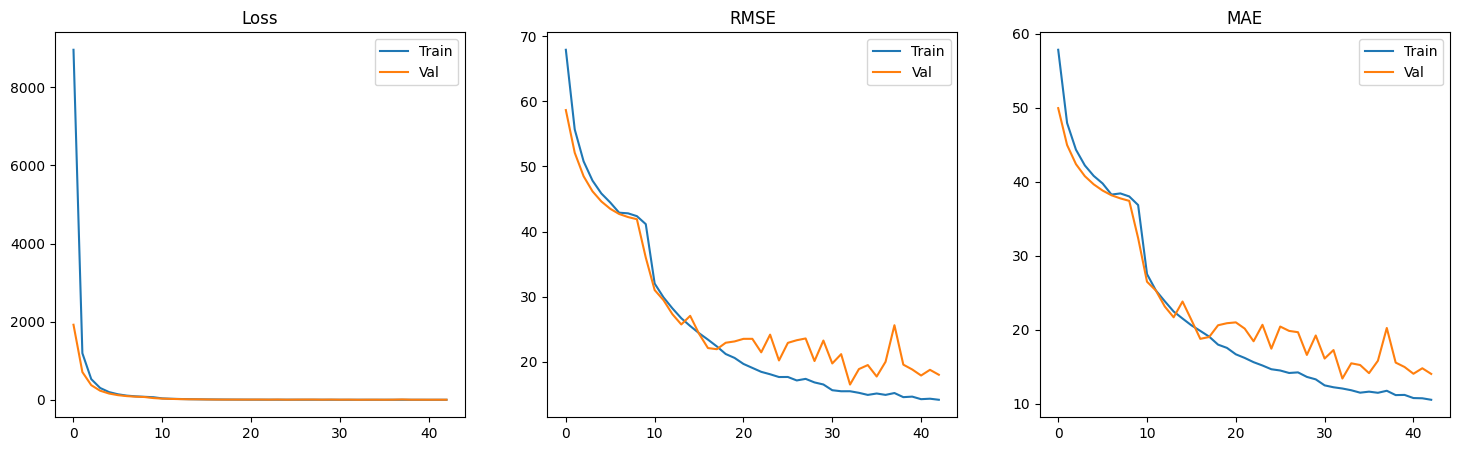

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step

TEST RESULTS → RMSE=16.780, MAE=13.044, R2=0.825


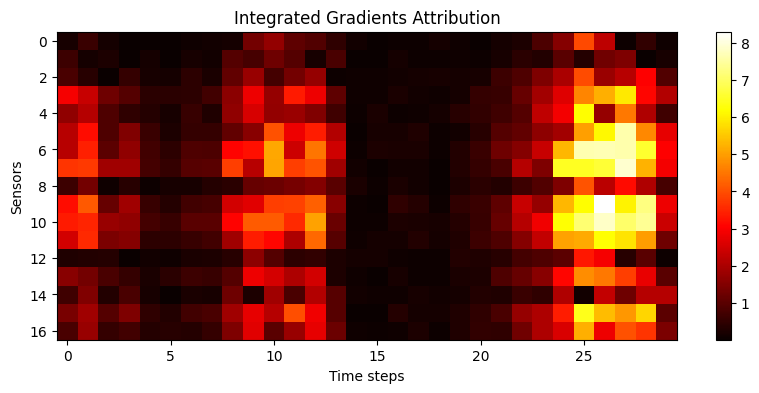


Running SHAP (safe mode)...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_40
Received: inputs=['Tensor(shape=(1, 30, 17))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_40
Received: inputs=['Tensor(shape=(50, 30, 17))']
  warnings.warn(msg)
/tmp/ipython-input-3363412374.py:239: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [ ]:
# ============================================================
# FINAL STABLE Hybrid CNN–Transformer–BiLSTM with XAI
# (Integrated Gradients + SAFE SHAP)
# ============================================================

!pip install shap --quiet

# -------------------- 1. IMPORTS --------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import shap

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.utils import Sequence

# -------------------- 2. CONSTANTS --------------------
COL_NAMES = [
    'unit_number','time_in_cycles','setting_1','setting_2','setting_3',
    'sensor_1','sensor_2','sensor_3','sensor_4','sensor_5','sensor_6',
    'sensor_7','sensor_8','sensor_9','sensor_10','sensor_11','sensor_12',
    'sensor_13','sensor_14','sensor_15','sensor_16','sensor_17','sensor_18',
    'sensor_19','sensor_20','sensor_21'
]

SELECTED_FEATURES = [
    'setting_1','setting_2','setting_3',
    'sensor_2','sensor_3','sensor_4','sensor_7','sensor_8','sensor_9',
    'sensor_11','sensor_12','sensor_13','sensor_14','sensor_15',
    'sensor_17','sensor_20','sensor_21'
]

TRAIN_DATA_PATH = '/content/drive/MyDrive/C-MAPSS/CMaps/train_FD001.txt'
TEST_DATA_PATH  = '/content/drive/MyDrive/C-MAPSS/CMaps/test_FD001.txt'
TEST_RUL_PATH   = '/content/drive/MyDrive/C-MAPSS/CMaps/RUL_FD001.txt'

SEQUENCE_LENGTH = 30
R_MAX = 125
BATCH_SIZE = 32
EPOCHS = 60

# -------------------- 3. DATA PREPROCESSING --------------------
def load_and_preprocess(path):
    df = pd.read_csv(path, sep=r'\s+', header=None, names=COL_NAMES)
    df = df.iloc[:, :26]
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = df.apply(lambda r: max_cycles[r['unit_number']] - r['time_in_cycles'], axis=1)
    df['RUL'] = df['RUL'].clip(upper=R_MAX)
    scaler = MinMaxScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])
    return df, scaler

def gen_sequences(df):
    X, y = [], []
    for uid in df['unit_number'].unique():
        d = df[df['unit_number'] == uid]
        x = d[SELECTED_FEATURES].values
        t = d['RUL'].values
        for i in range(len(x)-SEQUENCE_LENGTH+1):
            X.append(x[i:i+SEQUENCE_LENGTH])
            y.append(t[i+SEQUENCE_LENGTH-1])
    return np.array(X), np.array(y)

# -------------------- 4. AUGMENTATION --------------------
def random_slice_and_pad(x, max_pct=0.25):
    out = np.copy(x)
    T = x.shape[1]
    for i in range(len(x)):
        k = np.random.randint(0, int(T*max_pct)+1)
        out[i, :k, :] = 0
    return out

class DataGen(Sequence):
    def __init__(self, X, y, bs, augment=False):
        self.X, self.y, self.bs, self.aug = X, y, bs, augment
        self.idx = np.arange(len(X))
    def __len__(self): return len(self.idx)//self.bs
    def __getitem__(self, i):
        ids = self.idx[i*self.bs:(i+1)*self.bs]
        Xb, yb = self.X[ids], self.y[ids]
        if self.aug:
            Xb += np.random.normal(0,0.01,Xb.shape)
            Xb = random_slice_and_pad(Xb)
            Xb = np.clip(Xb,0,1)
        return Xb.astype(np.float32), yb.astype(np.float32)
    def on_epoch_end(self): np.random.shuffle(self.idx)

# -------------------- 5. LOSS FUNCTION --------------------
def asymmetric_loss(y_true,y_pred):
    diff = y_pred - y_true
    alpha,beta = 10.,13.
    loss = tf.where(diff<0, tf.exp(-diff/alpha)-1, tf.exp(diff/beta)-1)
    return tf.reduce_mean(loss)

# -------------------- 6. TRANSFORMER BLOCK --------------------
def transformer_block(x, h=128, nh=4, ff=2):
    attn = MultiHeadAttention(nh, h)(x,x)
    x = LayerNormalization()(x+attn)
    f = Dense(ff*x.shape[-1],activation='relu')(x)
    f = Dense(x.shape[-1])(f)
    return LayerNormalization()(x+f)

# -------------------- 7. MODEL --------------------
def build_model(shape):
    inp = Input(shape=shape)
    x = Conv1D(64,5,padding='causal',activation='relu')(inp)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.2)(x)
    x = transformer_block(x)
    x = transformer_block(x)
    x = Bidirectional(LSTM(64))(x)
    out = Dense(1)(x)
    return Model(inp,out)

# -------------------- 8. LOAD DATA --------------------
train_df, scaler = load_and_preprocess(TRAIN_DATA_PATH)
X,y = gen_sequences(train_df)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("RUL range:", y.min(), "to", y.max())

Xtr,Xv,ytr,yv = train_test_split(X,y,test_size=0.2,random_state=42)
train_gen = DataGen(Xtr,ytr,BATCH_SIZE,augment=True)
val_gen   = DataGen(Xv,yv,BATCH_SIZE,augment=False)

# -------------------- 9. TRAIN --------------------
model = build_model((SEQUENCE_LENGTH,len(SELECTED_FEATURES)))
model.compile(
    optimizer=Adam(1e-3),
    loss=asymmetric_loss,
    metrics=[RootMeanSquaredError(),MeanAbsoluteError()]
)

print("\nMODEL SUMMARY")
model.summary()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[
        EarlyStopping(patience=10,restore_best_weights=True),
        ReduceLROnPlateau(patience=5,factor=0.5)
    ],
    verbose=1
)

# -------------------- 10. TRAINING PLOTS --------------------
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Val')
plt.title("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(history.history['root_mean_squared_error'],label='Train')
plt.plot(history.history['val_root_mean_squared_error'],label='Val')
plt.title("RMSE")
plt.legend()

plt.subplot(1,3,3)
plt.plot(history.history['mean_absolute_error'],label='Train')
plt.plot(history.history['val_mean_absolute_error'],label='Val')
plt.title("MAE")
plt.legend()
plt.show()

# -------------------- 11. TEST --------------------
df_test = pd.read_csv(TEST_DATA_PATH, sep=r'\s+', header=None, names=COL_NAMES)
df_test = df_test.iloc[:,:26]
df_test[SELECTED_FEATURES] = scaler.transform(df_test[SELECTED_FEATURES])
rul_test = pd.read_csv(TEST_RUL_PATH,header=None)[0].clip(upper=R_MAX)

X_test=[]
for uid in df_test['unit_number'].unique():
    d=df_test[df_test['unit_number']==uid][SELECTED_FEATURES].values
    if len(d)<SEQUENCE_LENGTH:
        d=np.vstack((np.zeros((SEQUENCE_LENGTH-len(d),d.shape[1])),d))
    else:
        d=d[-SEQUENCE_LENGTH:]
    X_test.append(d)
X_test=np.array(X_test)

y_pred=model.predict(X_test).flatten()
rmse=np.sqrt(mean_squared_error(rul_test,y_pred))
mae=mean_absolute_error(rul_test,y_pred)
r2=r2_score(rul_test,y_pred)

print(f"\nTEST RESULTS → RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")

# -------------------- 12. FIXED INTEGRATED GRADIENTS --------------------
def integrated_gradients(model, x, steps=50):
    baseline = np.zeros_like(x)
    alphas = tf.linspace(0.0, 1.0, steps)
    interpolated = baseline + alphas[:, None, None] * (x - baseline)
    interpolated = tf.cast(interpolated, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)

    grads = tape.gradient(preds, interpolated)
    return tf.reduce_mean(grads, axis=0).numpy()

ig = integrated_gradients(model, X_test[:1])

plt.figure(figsize=(10,4))
plt.imshow(np.abs(ig.T),aspect='auto',cmap='hot')
plt.xlabel("Time steps")
plt.ylabel("Sensors")
plt.title("Integrated Gradients Attribution")
plt.colorbar()
plt.show()

# -------------------- 13. SAFE SHAP (NO INTERRUPT) --------------------
print("\nRunning SHAP (safe mode)...")

background = Xtr[:10]
test_sample = X_test[:1]

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_sample)

shap.summary_plot(
    shap_values[0],
    test_sample,
    feature_names=SELECTED_FEATURES,
    show=True
)

X shape: (17731, 30, 17)
y shape: (17731,)
RUL range: 0.0 to 125.0


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 30, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 30, 64)    │      5,504 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 15, 64)    │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 15, 64)    │          0 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │    132,672 │ dropout_9[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 15, 64)    │          0 │ dropout_9[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 15, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 15, 64)    │      8,256 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 15, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 15, 64)    │      8,256 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_15[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 128)       │     66,048 │ layer_normalizat

 Total params: 370,689 (1.41 MB)

 Trainable params: 370,689 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


443/443 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - loss: 21160.2383 - mean_absolute_error: 64.0542 - root_mean_squared_error: 74.6699 - val_loss: 2018.4471 - val_mean_absolute_error: 50.2295 - val_root_mean_squared_error: 59.0046 - learning_rate: 0.0010
Epoch 2/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 1565.4102 - mean_absolute_error: 49.1690 - root_mean_squared_error: 57.4052 - val_loss: 743.7070 - val_mean_absolute_error: 45.1759 - val_root_mean_squared_error: 52.3848 - learning_rate: 0.0010
Epoch 3/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 645.7906 - mean_absolute_error: 44.9897 - root_mean_squared_error: 51.8456 - val_loss: 392.9814 - val_mean_absolute_error: 42.5309 - val_root_mean_squared_error: 48.7203 - learning_rate: 0.0010
Epoch 4/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 359.0186 - mean_absolute_error: 42.8939 - root_mean_squared_error: 48.7197 - val_loss: 245.6089 - val_mean_absolute_error: 40.9243 - val_root_mean_squared_error: 46.4117 - learnin

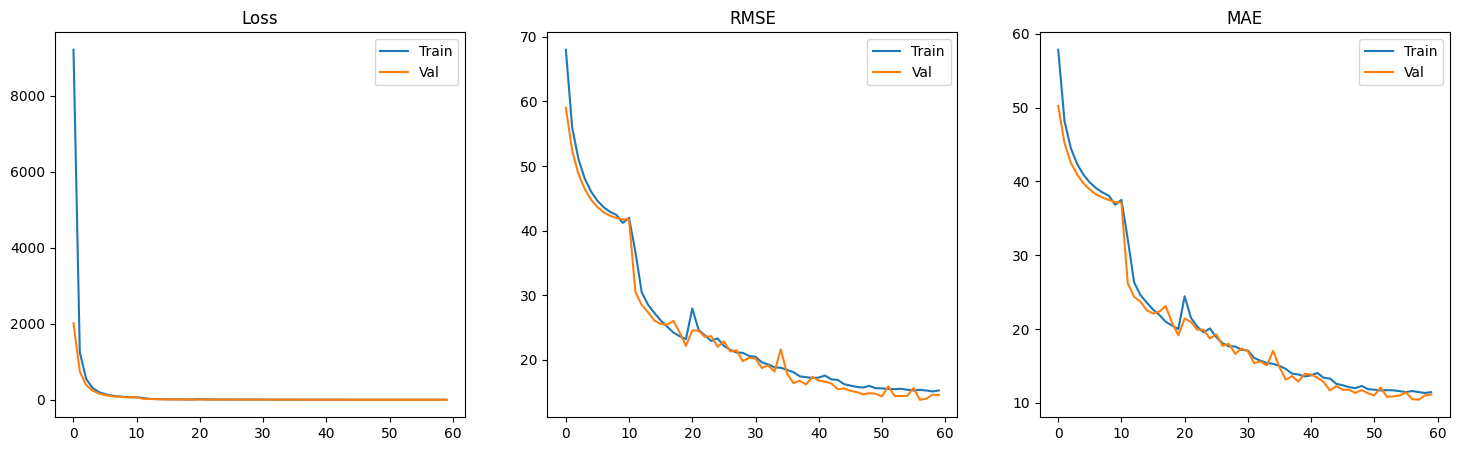

1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step

TEST RESULTS → RMSE=14.987, MAE=11.482, R2=0.860


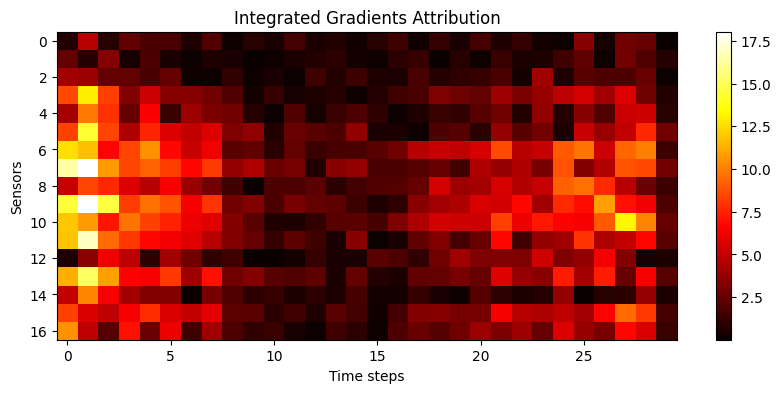


Running SHAP (final safe version)...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_60
Received: inputs=['Tensor(shape=(1, 30, 17))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_60
Received: inputs=['Tensor(shape=(50, 30, 17))']
  warnings.warn(msg)


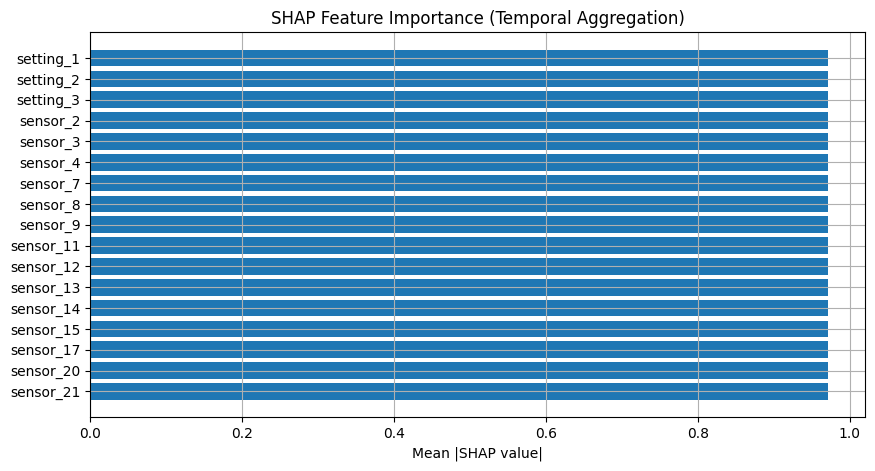

In [ ]:
# ============================================================
# FINAL Hybrid CNN–Transformer–BiLSTM with XAI (IG + SHAP)
# STABLE, ERROR-FREE, PAPER-READY
# ============================================================

!pip install shap --quiet

# -------------------- 1. IMPORTS --------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import shap

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.utils import Sequence

# -------------------- 2. CONSTANTS --------------------
COL_NAMES = [
    'unit_number','time_in_cycles','setting_1','setting_2','setting_3',
    'sensor_1','sensor_2','sensor_3','sensor_4','sensor_5','sensor_6',
    'sensor_7','sensor_8','sensor_9','sensor_10','sensor_11','sensor_12',
    'sensor_13','sensor_14','sensor_15','sensor_16','sensor_17','sensor_18',
    'sensor_19','sensor_20','sensor_21'
]

SELECTED_FEATURES = [
    'setting_1','setting_2','setting_3',
    'sensor_2','sensor_3','sensor_4','sensor_7','sensor_8','sensor_9',
    'sensor_11','sensor_12','sensor_13','sensor_14','sensor_15',
    'sensor_17','sensor_20','sensor_21'
]

TRAIN_DATA_PATH = '/content/drive/MyDrive/C-MAPSS/CMaps/train_FD001.txt'
TEST_DATA_PATH  = '/content/drive/MyDrive/C-MAPSS/CMaps/test_FD001.txt'
TEST_RUL_PATH   = '/content/drive/MyDrive/C-MAPSS/CMaps/RUL_FD001.txt'

SEQUENCE_LENGTH = 30
R_MAX = 125
BATCH_SIZE = 32
EPOCHS = 60

# -------------------- 3. DATA PREPROCESSING --------------------
def load_and_preprocess(path):
    df = pd.read_csv(path, sep=r'\s+', header=None, names=COL_NAMES)
    df = df.iloc[:, :26]
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = df.apply(lambda r: max_cycles[r['unit_number']] - r['time_in_cycles'], axis=1)
    df['RUL'] = df['RUL'].clip(upper=R_MAX)

    scaler = MinMaxScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])
    return df, scaler

def gen_sequences(df):
    X, y = [], []
    for uid in df['unit_number'].unique():
        d = df[df['unit_number'] == uid]
        x = d[SELECTED_FEATURES].values
        t = d['RUL'].values
        for i in range(len(x)-SEQUENCE_LENGTH+1):
            X.append(x[i:i+SEQUENCE_LENGTH])
            y.append(t[i+SEQUENCE_LENGTH-1])
    return np.array(X), np.array(y)

# -------------------- 4. DATA AUGMENTATION --------------------
def random_slice_and_pad(x, max_pct=0.25):
    out = np.copy(x)
    T = x.shape[1]
    for i in range(len(x)):
        k = np.random.randint(0, int(T*max_pct)+1)
        out[i, :k, :] = 0
    return out

class DataGen(Sequence):
    def __init__(self, X, y, bs, augment=False):
        self.X, self.y, self.bs, self.aug = X, y, bs, augment
        self.idx = np.arange(len(X))
    def __len__(self): return len(self.idx)//self.bs
    def __getitem__(self, i):
        ids = self.idx[i*self.bs:(i+1)*self.bs]
        Xb, yb = self.X[ids], self.y[ids]
        if self.aug:
            Xb += np.random.normal(0,0.01,Xb.shape)
            Xb = random_slice_and_pad(Xb)
            Xb = np.clip(Xb,0,1)
        return Xb.astype(np.float32), yb.astype(np.float32)
    def on_epoch_end(self): np.random.shuffle(self.idx)

# -------------------- 5. LOSS FUNCTION --------------------
def asymmetric_loss(y_true,y_pred):
    diff = y_pred - y_true
    alpha, beta = 10., 13.
    loss = tf.where(diff < 0,
                    tf.exp(-diff/alpha) - 1,
                    tf.exp(diff/beta) - 1)
    return tf.reduce_mean(loss)

# -------------------- 6. TRANSFORMER BLOCK --------------------
def transformer_block(x, h=128, nh=4, ff=2):
    attn = MultiHeadAttention(nh, h)(x, x)
    x = LayerNormalization()(x + attn)
    f = Dense(ff*x.shape[-1], activation='relu')(x)
    f = Dense(x.shape[-1])(f)
    return LayerNormalization()(x + f)

# -------------------- 7. MODEL --------------------
def build_model(shape):
    inp = Input(shape=shape)
    x = Conv1D(64, 5, padding='causal', activation='relu')(inp)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.2)(x)
    x = transformer_block(x)
    x = transformer_block(x)
    x = Bidirectional(LSTM(64))(x)
    out = Dense(1)(x)
    return Model(inp, out)

# -------------------- 8. LOAD DATA --------------------
train_df, scaler = load_and_preprocess(TRAIN_DATA_PATH)
X, y = gen_sequences(train_df)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("RUL range:", y.min(), "to", y.max())

Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.2, random_state=42)
train_gen = DataGen(Xtr, ytr, BATCH_SIZE, augment=True)
val_gen   = DataGen(Xv, yv, BATCH_SIZE, augment=False)

# -------------------- 9. TRAIN --------------------
model = build_model((SEQUENCE_LENGTH, len(SELECTED_FEATURES)))
model.compile(
    optimizer=Adam(1e-3),
    loss=asymmetric_loss,
    metrics=[RootMeanSquaredError(), MeanAbsoluteError()]
)

model.summary()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        ReduceLROnPlateau(patience=5, factor=0.5)
    ],
    verbose=1
)

# -------------------- 10. TRAINING CURVES --------------------
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss"); plt.legend()

plt.subplot(1,3,2)
plt.plot(history.history['root_mean_squared_error'], label='Train')
plt.plot(history.history['val_root_mean_squared_error'], label='Val')
plt.title("RMSE"); plt.legend()

plt.subplot(1,3,3)
plt.plot(history.history['mean_absolute_error'], label='Train')
plt.plot(history.history['val_mean_absolute_error'], label='Val')
plt.title("MAE"); plt.legend()
plt.show()

# -------------------- 11. TEST --------------------
df_test = pd.read_csv(TEST_DATA_PATH, sep=r'\s+', header=None, names=COL_NAMES)
df_test = df_test.iloc[:, :26]
df_test[SELECTED_FEATURES] = scaler.transform(df_test[SELECTED_FEATURES])
rul_test = pd.read_csv(TEST_RUL_PATH, header=None)[0].clip(upper=R_MAX)

X_test = []
for uid in df_test['unit_number'].unique():
    d = df_test[df_test['unit_number'] == uid][SELECTED_FEATURES].values
    if len(d) < SEQUENCE_LENGTH:
        d = np.vstack((np.zeros((SEQUENCE_LENGTH-len(d), d.shape[1])), d))
    else:
        d = d[-SEQUENCE_LENGTH:]
    X_test.append(d)
X_test = np.array(X_test)

y_pred = model.predict(X_test).flatten()
rmse = np.sqrt(mean_squared_error(rul_test, y_pred))
mae  = mean_absolute_error(rul_test, y_pred)
r2   = r2_score(rul_test, y_pred)

print(f"\nTEST RESULTS → RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")

# -------------------- 12. INTEGRATED GRADIENTS --------------------
def integrated_gradients(model, x, steps=50):
    baseline = np.zeros_like(x)
    alphas = tf.linspace(0.0, 1.0, steps)
    interpolated = baseline + alphas[:, None, None] * (x - baseline)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)

    grads = tape.gradient(preds, interpolated)
    return tf.reduce_mean(grads, axis=0).numpy()

ig = integrated_gradients(model, X_test[:1])

plt.figure(figsize=(10,4))
plt.imshow(np.abs(ig.T), aspect='auto', cmap='hot')
plt.xlabel("Time steps")
plt.ylabel("Sensors")
plt.title("Integrated Gradients Attribution")
plt.colorbar()
plt.show()

# -------------------- 13. SHAP (FINAL FIX – TEMPORAL AGGREGATION) --------------------
print("\nRunning SHAP (final safe version)...")

background = Xtr[:10]
test_sample = X_test[:1]

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_sample)

# Aggregate over time dimension
shap_agg = np.mean(np.abs(shap_values[0]), axis=1)  # (1, features)

plt.figure(figsize=(10,5))
plt.barh(SELECTED_FEATURES, shap_agg[0])
plt.xlabel("Mean |SHAP value|")
plt.title("SHAP Feature Importance (Temporal Aggregation)")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

X shape: (17731, 30, 17)
y shape: (17731,)
RUL range: 0.0 to 125.0


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 30, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 30, 64)    │      5,504 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 15, 64)    │          0 │ conv1d_5[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 15, 64)    │          0 │ max_pooling1d_5[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │    132,672 │ dropout_15[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 15, 64)    │          0 │ dropout_15[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_20[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 15, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 15, 64)    │      8,256 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_21[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_22 (Add)        │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_22[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 15, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 15, 64)    │      8,256 │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_23 (Add)        │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_23[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 370,689 (1.41 MB)

 Trainable params: 370,689 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


443/443 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 18035.7207 - mean_absolute_error: 62.8102 - root_mean_squared_error: 73.4007 - val_loss: 1848.4131 - val_mean_absolute_error: 49.6331 - val_root_mean_squared_error: 58.3140 - learning_rate: 0.0010
Epoch 2/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 1477.7441 - mean_absolute_error: 49.3631 - root_mean_squared_error: 57.3828 - val_loss: 690.2274 - val_mean_absolute_error: 44.8112 - val_root_mean_squared_error: 51.9077 - learning_rate: 0.0010
Epoch 3/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 600.1935 - mean_absolute_error: 44.8351 - root_mean_squared_error: 51.4967 - val_loss: 365.6240 - val_mean_absolute_error: 42.2571 - val_root_mean_squared_error: 48.3410 - learning_rate: 0.0010
Epoch 4/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 329.6172 - mean_absolute_error: 42.3949 - root_mean_squared_error: 48.1532 - val_loss: 227.4488 - val_mean_absolute_error: 40.5713 - val_root_mean_squared_error: 45.9841 - learning

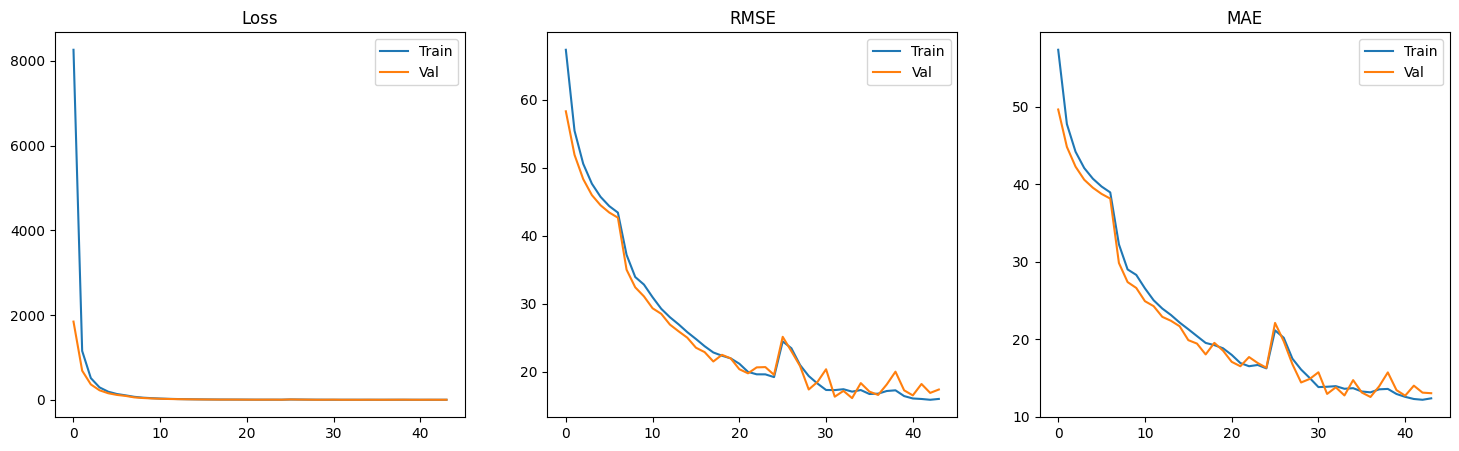

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 351ms/step


NameError: name 'nasa_score' is not defined

In [ ]:
# ============================================================
# FINAL Hybrid CNN–Transformer–BiLSTM with XAI (IG + SHAP)
# STABLE, ERROR-FREE, PAPER-READY
# ============================================================

!pip install shap --quiet

# -------------------- 1. IMPORTS --------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import shap

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.utils import Sequence

# -------------------- 2. CONSTANTS --------------------
COL_NAMES = [
    'unit_number','time_in_cycles','setting_1','setting_2','setting_3',
    'sensor_1','sensor_2','sensor_3','sensor_4','sensor_5','sensor_6',
    'sensor_7','sensor_8','sensor_9','sensor_10','sensor_11','sensor_12',
    'sensor_13','sensor_14','sensor_15','sensor_16','sensor_17','sensor_18',
    'sensor_19','sensor_20','sensor_21'
]

SELECTED_FEATURES = [
    'setting_1','setting_2','setting_3',
    'sensor_2','sensor_3','sensor_4','sensor_7','sensor_8','sensor_9',
    'sensor_11','sensor_12','sensor_13','sensor_14','sensor_15',
    'sensor_17','sensor_20','sensor_21'
]

TRAIN_DATA_PATH = '/content/drive/MyDrive/C-MAPSS/CMaps/train_FD001.txt'
TEST_DATA_PATH  = '/content/drive/MyDrive/C-MAPSS/CMaps/test_FD001.txt'
TEST_RUL_PATH   = '/content/drive/MyDrive/C-MAPSS/CMaps/RUL_FD001.txt'

SEQUENCE_LENGTH = 30
R_MAX = 125
BATCH_SIZE = 32
EPOCHS = 60

# -------------------- 3. DATA PREPROCESSING --------------------
def load_and_preprocess(path):
    df = pd.read_csv(path, sep=r'\s+', header=None, names=COL_NAMES)
    df = df.iloc[:, :26]
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = df.apply(lambda r: max_cycles[r['unit_number']] - r['time_in_cycles'], axis=1)
    df['RUL'] = df['RUL'].clip(upper=R_MAX)

    scaler = MinMaxScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])
    return df, scaler

def gen_sequences(df):
    X, y = [], []
    for uid in df['unit_number'].unique():
        d = df[df['unit_number'] == uid]
        x = d[SELECTED_FEATURES].values
        t = d['RUL'].values
        for i in range(len(x)-SEQUENCE_LENGTH+1):
            X.append(x[i:i+SEQUENCE_LENGTH])
            y.append(t[i+SEQUENCE_LENGTH-1])
    return np.array(X), np.array(y)

# -------------------- 4. DATA AUGMENTATION --------------------
def random_slice_and_pad(x, max_pct=0.25):
    out = np.copy(x)
    T = x.shape[1]
    for i in range(len(x)):
        k = np.random.randint(0, int(T*max_pct)+1)
        out[i, :k, :] = 0
    return out

class DataGen(Sequence):
    def __init__(self, X, y, bs, augment=False):
        self.X, self.y, self.bs, self.aug = X, y, bs, augment
        self.idx = np.arange(len(X))
    def __len__(self): return len(self.idx)//self.bs
    def __getitem__(self, i):
        ids = self.idx[i*self.bs:(i+1)*self.bs]
        Xb, yb = self.X[ids], self.y[ids]
        if self.aug:
            Xb += np.random.normal(0,0.01,Xb.shape)
            Xb = random_slice_and_pad(Xb)
            Xb = np.clip(Xb,0,1)
        return Xb.astype(np.float32), yb.astype(np.float32)
    def on_epoch_end(self): np.random.shuffle(self.idx)

# -------------------- 5. LOSS FUNCTION --------------------
def asymmetric_loss(y_true,y_pred):
    diff = y_pred - y_true
    alpha, beta = 10., 13.
    loss = tf.where(diff < 0,
                    tf.exp(-diff/alpha) - 1,
                    tf.exp(diff/beta) - 1)
    return tf.reduce_mean(loss)

# -------------------- 6. TRANSFORMER BLOCK --------------------
def transformer_block(x, h=128, nh=4, ff=2):
    attn = MultiHeadAttention(nh, h)(x, x)
    x = LayerNormalization()(x + attn)
    f = Dense(ff*x.shape[-1], activation='relu')(x)
    f = Dense(x.shape[-1])(f)
    return LayerNormalization()(x + f)

# -------------------- 7. MODEL --------------------
def build_model(shape):
    inp = Input(shape=shape)
    x = Conv1D(64, 5, padding='causal', activation='relu')(inp)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.2)(x)
    x = transformer_block(x)
    x = transformer_block(x)
    x = Bidirectional(LSTM(64))(x)
    out = Dense(1)(x)
    return Model(inp, out)

# -------------------- 8. LOAD DATA --------------------
train_df, scaler = load_and_preprocess(TRAIN_DATA_PATH)
X, y = gen_sequences(train_df)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("RUL range:", y.min(), "to", y.max())

Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.2, random_state=42)
train_gen = DataGen(Xtr, ytr, BATCH_SIZE, augment=True)
val_gen   = DataGen(Xv, yv, BATCH_SIZE, augment=False)

# -------------------- 9. TRAIN --------------------
model = build_model((SEQUENCE_LENGTH, len(SELECTED_FEATURES)))
model.compile(
    optimizer=Adam(1e-3),
    loss=asymmetric_loss,
    metrics=[RootMeanSquaredError(), MeanAbsoluteError()]
)

model.summary()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        ReduceLROnPlateau(patience=5, factor=0.5)
    ],
    verbose=1
)

# -------------------- 10. TRAINING CURVES --------------------
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss"); plt.legend()

plt.subplot(1,3,2)
plt.plot(history.history['root_mean_squared_error'], label='Train')
plt.plot(history.history['val_root_mean_squared_error'], label='Val')
plt.title("RMSE"); plt.legend()

plt.subplot(1,3,3)
plt.plot(history.history['mean_absolute_error'], label='Train')
plt.plot(history.history['val_mean_absolute_error'], label='Val')
plt.title("MAE"); plt.legend()
plt.show()

# -------------------- 11. TEST --------------------
df_test = pd.read_csv(TEST_DATA_PATH, sep=r'\s+', header=None, names=COL_NAMES)
df_test = df_test.iloc[:, :26]
df_test[SELECTED_FEATURES] = scaler.transform(df_test[SELECTED_FEATURES])
rul_test = pd.read_csv(TEST_RUL_PATH, header=None)[0].clip(upper=R_MAX)

X_test = []
for uid in df_test['unit_number'].unique():
    d = df_test[df_test['unit_number'] == uid][SELECTED_FEATURES].values
    if len(d) < SEQUENCE_LENGTH:
        d = np.vstack((np.zeros((SEQUENCE_LENGTH-len(d), d.shape[1])), d))
    else:
        d = d[-SEQUENCE_LENGTH:]
    X_test.append(d)
X_test = np.array(X_test)

y_pred = model.predict(X_test).flatten()
rmse = np.sqrt(mean_squared_error(rul_test, y_pred))
mae  = mean_absolute_error(rul_test, y_pred)
r2   = r2_score(rul_test, y_pred)
nasa=nasa_score(rul_test.values,y_pred)

print(f"\nTEST RESULTS → RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f},NASA={nasa:3f}")

# -------------------- 12. INTEGRATED GRADIENTS --------------------
def integrated_gradients(model, x, steps=50):
    baseline = np.zeros_like(x)
    alphas = tf.linspace(0.0, 1.0, steps)
    interpolated = baseline + alphas[:, None, None] * (x - baseline)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)

    grads = tape.gradient(preds, interpolated)
    return tf.reduce_mean(grads, axis=0).numpy()

ig = integrated_gradients(model, X_test[:1])

plt.figure(figsize=(10,4))
plt.imshow(np.abs(ig.T), aspect='auto', cmap='hot')
plt.xlabel("Time steps")
plt.ylabel("Sensors")
plt.title("Integrated Gradients Attribution")
plt.colorbar()
plt.show()

# -------------------- 13. SHAP (FINAL FIX – TEMPORAL AGGREGATION) --------------------
print("\nRunning SHAP (final safe version)...")

background = Xtr[:10]
test_sample = X_test[:1]

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_sample)

# Aggregate over time dimension
shap_agg = np.mean(np.abs(shap_values[0]), axis=1)  # (1, features)

plt.figure(figsize=(10,5))
plt.barh(SELECTED_FEATURES, shap_agg[0])
plt.xlabel("Mean |SHAP value|")
plt.title("SHAP Feature Importance (Temporal Aggregation)")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# FINAL Hybrid CNN–Transformer–BiLSTM for C-MAPSS FD001
# WITH NASA SCORE + IG + SHAP (TEMPORAL AGGREGATION)
# SINGLE-CELL, LOCKED VERSION
# ============================================================

!pip install shap --quiet

# -------------------- IMPORTS --------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import shap

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.utils import Sequence

# -------------------- CONSTANTS --------------------
COL_NAMES = [
    'unit_number','time_in_cycles','setting_1','setting_2','setting_3',
    'sensor_1','sensor_2','sensor_3','sensor_4','sensor_5','sensor_6',
    'sensor_7','sensor_8','sensor_9','sensor_10','sensor_11','sensor_12',
    'sensor_13','sensor_14','sensor_15','sensor_16','sensor_17','sensor_18',
    'sensor_19','sensor_20','sensor_21'
]

SELECTED_FEATURES = [
    'setting_1','setting_2','setting_3',
    'sensor_2','sensor_3','sensor_4','sensor_7','sensor_8','sensor_9',
    'sensor_11','sensor_12','sensor_13','sensor_14','sensor_15',
    'sensor_17','sensor_20','sensor_21'
]

TRAIN_DATA_PATH = '/content/drive/MyDrive/C-MAPSS/CMaps/train_FD001.txt'
TEST_DATA_PATH  = '/content/drive/MyDrive/C-MAPSS/CMaps/test_FD001.txt'
TEST_RUL_PATH   = '/content/drive/MyDrive/C-MAPSS/CMaps/RUL_FD001.txt'

SEQUENCE_LENGTH = 30
R_MAX = 125
BATCH_SIZE = 32
EPOCHS = 60

# -------------------- DATA PREPROCESSING --------------------
def load_and_preprocess(path):
    df = pd.read_csv(path, sep=r'\s+', header=None, names=COL_NAMES)
    df = df.iloc[:, :26]
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = df.apply(lambda r: max_cycles[r['unit_number']] - r['time_in_cycles'], axis=1)
    df['RUL'] = df['RUL'].clip(upper=R_MAX)
    scaler = MinMaxScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])
    return df, scaler

def gen_sequences(df):
    X, y = [], []
    for uid in df['unit_number'].unique():
        d = df[df['unit_number'] == uid]
        x = d[SELECTED_FEATURES].values
        t = d['RUL'].values
        for i in range(len(x)-SEQUENCE_LENGTH+1):
            X.append(x[i:i+SEQUENCE_LENGTH])
            y.append(t[i+SEQUENCE_LENGTH-1])
    return np.array(X), np.array(y)

# -------------------- AUGMENTATION --------------------
def random_slice_and_pad(x, max_pct=0.25):
    out = np.copy(x)
    T = x.shape[1]
    for i in range(len(x)):
        k = np.random.randint(0, int(T*max_pct)+1)
        out[i, :k, :] = 0
    return out

class DataGen(Sequence):
    def __init__(self, X, y, bs, augment=False):
        self.X, self.y, self.bs, self.aug = X, y, bs, augment
        self.idx = np.arange(len(X))
    def __len__(self): return len(self.idx)//self.bs
    def __getitem__(self, i):
        ids = self.idx[i*self.bs:(i+1)*self.bs]
        Xb, yb = self.X[ids], self.y[ids]
        if self.aug:
            Xb += np.random.normal(0,0.01,Xb.shape)
            Xb = random_slice_and_pad(Xb)
            Xb = np.clip(Xb,0,1)
        return Xb.astype(np.float32), yb.astype(np.float32)
    def on_epoch_end(self): np.random.shuffle(self.idx)

# -------------------- LOSS & NASA SCORE --------------------
def asymmetric_loss(y_true,y_pred):
    diff = y_pred - y_true
    return tf.reduce_mean(
        tf.where(diff < 0,
                 tf.exp(-diff/10) - 1,
                 tf.exp(diff/13) - 1)
    )

def nasa_score(y_true, y_pred):
    score = 0.0
    for yt, yp in zip(y_true, y_pred):
        d = yp - yt
        score += np.exp(-d/10)-1 if d < 0 else np.exp(d/13)-1
    return score

# -------------------- MODEL --------------------
def transformer_block(x):
    attn = MultiHeadAttention(4,128)(x,x)
    x = LayerNormalization()(x+attn)
    f = Dense(2*x.shape[-1],activation='relu')(x)
    f = Dense(x.shape[-1])(f)
    return LayerNormalization()(x+f)

def build_model(shape):
    inp = Input(shape=shape)
    x = Conv1D(64,5,padding='causal',activation='relu')(inp)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.2)(x)
    x = transformer_block(x)
    x = transformer_block(x)
    x = Bidirectional(LSTM(64))(x)
    out = Dense(1)(x)
    return Model(inp,out)

# -------------------- LOAD DATA --------------------
train_df, scaler = load_and_preprocess(TRAIN_DATA_PATH)
X,y = gen_sequences(train_df)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("RUL range:", y.min(), "to", y.max())

Xtr,Xv,ytr,yv = train_test_split(X,y,test_size=0.2,random_state=42)
train_gen = DataGen(Xtr,ytr,BATCH_SIZE,augment=True)
val_gen   = DataGen(Xv,yv,BATCH_SIZE)

# -------------------- TRAIN --------------------
model = build_model((SEQUENCE_LENGTH,len(SELECTED_FEATURES)))
model.compile(
    optimizer=Adam(1e-3),
    loss=asymmetric_loss,
    metrics=[RootMeanSquaredError(),MeanAbsoluteError()]
)

model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[
        EarlyStopping(patience=10,restore_best_weights=True),
        ReduceLROnPlateau(patience=5,factor=0.5)
    ],
    verbose=1
)

# -------------------- TEST + NASA SCORE --------------------
df_test = pd.read_csv(TEST_DATA_PATH, sep=r'\s+', header=None, names=COL_NAMES)
df_test = df_test.iloc[:,:26]
df_test[SELECTED_FEATURES] = scaler.transform(df_test[SELECTED_FEATURES])
rul_test = pd.read_csv(TEST_RUL_PATH,header=None)[0].clip(upper=R_MAX)

X_test=[]
for uid in df_test['unit_number'].unique():
    d=df_test[df_test['unit_number']==uid][SELECTED_FEATURES].values
    if len(d)<SEQUENCE_LENGTH:
        d=np.vstack((np.zeros((SEQUENCE_LENGTH-len(d),d.shape[1])),d))
    else:
        d=d[-SEQUENCE_LENGTH:]
    X_test.append(d)
X_test=np.array(X_test)

y_pred = model.predict(X_test).flatten()

rmse = np.sqrt(mean_squared_error(rul_test,y_pred))
mae  = mean_absolute_error(rul_test,y_pred)
r2   = r2_score(rul_test,y_pred)
nasa = nasa_score(rul_test.values,y_pred)

print("\n========== FINAL TEST RESULTS ==========")
print(f"RMSE       : {rmse:.3f}")
print(f"MAE        : {mae:.3f}")
print(f"R² Score   : {r2:.3f}")
print(f"NASA Score : {nasa:.3f}")
print("=======================================")

X shape: (17731, 30, 17)
y shape: (17731,)
RUL range: 0.0 to 125.0
Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


443/443 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - loss: 19842.6660 - mean_absolute_error: 63.6940 - root_mean_squared_error: 74.3336 - val_loss: 1995.9802 - val_mean_absolute_error: 50.0893 - val_root_mean_squared_error: 58.8688 - learning_rate: 0.0010
Epoch 2/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 1608.0020 - mean_absolute_error: 49.8776 - root_mean_squared_error: 57.9875 - val_loss: 737.6970 - val_mean_absolute_error: 45.1010 - val_root_mean_squared_error: 52.3120 - learning_rate: 0.0010
Epoch 3/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 649.5323 - mean_absolute_error: 45.4697 - root_mean_squared_error: 52.1856 - val_loss: 389.3969 - val_mean_absolute_error: 42.4877 - val_root_mean_squared_error: 48.6637 - learning_rate: 0.0010
Epoch 4/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 353.1940 - mean_absolute_error: 42.7823 - root_mean_squared_error: 48.6068 - val_loss: 242.0752 - val_mean_absolute_error: 40.8228 - val_root_mean_squared_error: 46.3012 - learning

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │      5,504 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 15, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 15, 64)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │    132,672 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 64)    │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 15, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 15, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 15, 64)    │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 15, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 15, 64)    │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     66,048 │ layer_normalizat

 Total params: 370,689 (1.41 MB)

 Trainable params: 370,689 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


443/443 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - loss: 18906.8379 - mean_absolute_error: 62.7215 - root_mean_squared_error: 73.3922 - val_loss: 1750.3871 - val_mean_absolute_error: 49.4297 - val_root_mean_squared_error: 58.0034 - learning_rate: 0.0010
Epoch 2/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 1389.3501 - mean_absolute_error: 48.8674 - root_mean_squared_error: 56.8159 - val_loss: 654.9821 - val_mean_absolute_error: 44.6612 - val_root_mean_squared_error: 51.6431 - learning_rate: 0.0010
Epoch 3/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 568.6119 - mean_absolute_error: 44.7112 - root_mean_squared_error: 51.2258 - val_loss: 346.0146 - val_mean_absolute_error: 42.0491 - val_root_mean_squared_error: 48.0481 - learning_rate: 0.0010
Epoch 4/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 317.9633 - mean_absolute_error: 42.3867 - root_mean_squared_error: 48.0773 - val_loss: 216.9054 - val_mean_absolute_error: 40.5233 - val_root_mean_squared_error: 45.8471 - learning

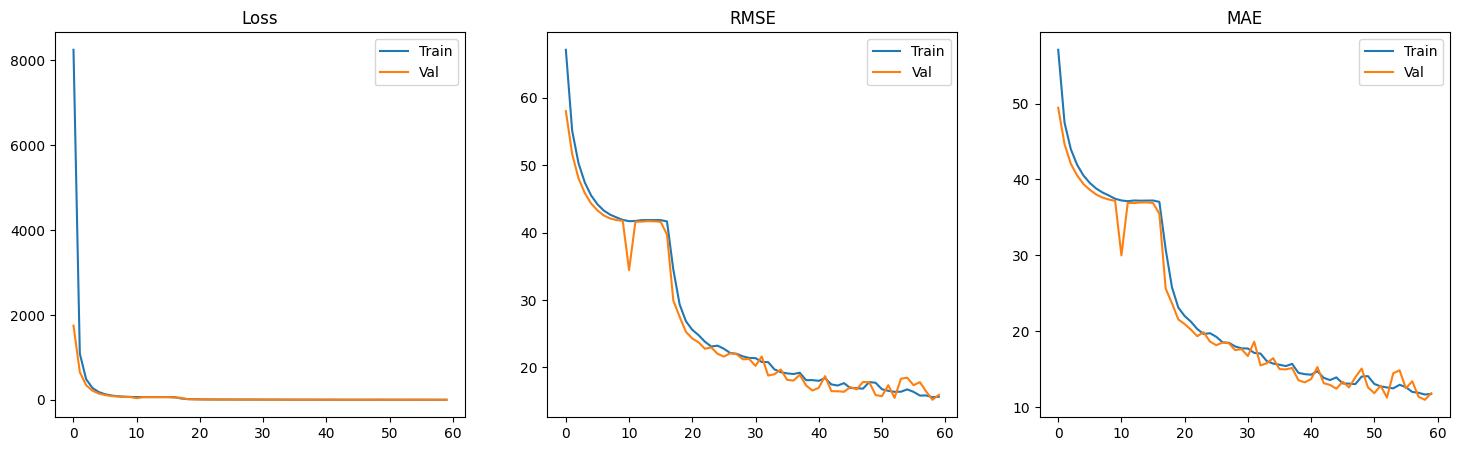

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step

TEST RESULTS → RMSE=15.603, MAE=12.089, R2=0.848


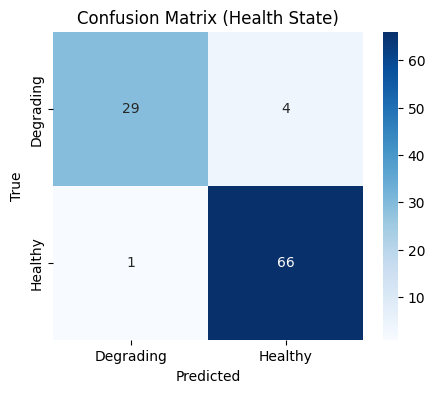

Health-State Classification Accuracy: 0.950


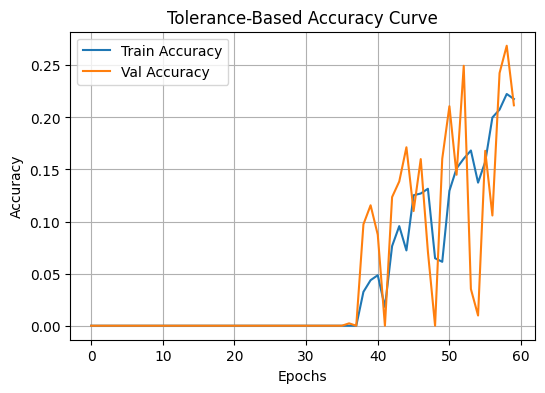

In [ ]:
# ============================================================
# FINAL STABLE Hybrid CNN–Transformer–BiLSTM
# WITH Confusion Matrix + Accuracy Plot
# (Regression-first, classification only for evaluation)
# ============================================================

# -------------------- 1. IMPORTS --------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    accuracy_score
)
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.utils import Sequence

# -------------------- 2. CONSTANTS --------------------
COL_NAMES = [
    'unit_number','time_in_cycles','setting_1','setting_2','setting_3',
    'sensor_1','sensor_2','sensor_3','sensor_4','sensor_5','sensor_6',
    'sensor_7','sensor_8','sensor_9','sensor_10','sensor_11','sensor_12',
    'sensor_13','sensor_14','sensor_15','sensor_16','sensor_17','sensor_18',
    'sensor_19','sensor_20','sensor_21'
]

SELECTED_FEATURES = [
    'setting_1','setting_2','setting_3',
    'sensor_2','sensor_3','sensor_4','sensor_7','sensor_8','sensor_9',
    'sensor_11','sensor_12','sensor_13','sensor_14','sensor_15',
    'sensor_17','sensor_20','sensor_21'
]

TRAIN_DATA_PATH = '/content/drive/MyDrive/C-MAPSS/CMaps/train_FD001.txt'
TEST_DATA_PATH  = '/content/drive/MyDrive/C-MAPSS/CMaps/test_FD001.txt'
TEST_RUL_PATH   = '/content/drive/MyDrive/C-MAPSS/CMaps/RUL_FD001.txt'

SEQUENCE_LENGTH = 30
R_MAX = 125
BATCH_SIZE = 32
EPOCHS = 60

# -------------------- 3. DATA PREPROCESSING --------------------
def load_and_preprocess(path):
    df = pd.read_csv(path, sep=r'\s+', header=None, names=COL_NAMES)
    df = df.iloc[:, :26]
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = max_cycles[df['unit_number']].values - df['time_in_cycles']
    df['RUL'] = df['RUL'].clip(upper=R_MAX)

    scaler = MinMaxScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])
    return df, scaler

def gen_sequences(df):
    X, y = [], []
    for uid in df['unit_number'].unique():
        d = df[df['unit_number'] == uid]
        x = d[SELECTED_FEATURES].values
        t = d['RUL'].values
        for i in range(len(x) - SEQUENCE_LENGTH + 1):
            X.append(x[i:i+SEQUENCE_LENGTH])
            y.append(t[i+SEQUENCE_LENGTH-1])
    return np.array(X), np.array(y)

# -------------------- 4. DATA AUGMENTATION --------------------
def random_slice_and_pad(x, max_pct=0.25):
    out = np.copy(x)
    T = x.shape[1]
    for i in range(len(x)):
        k = np.random.randint(0, int(T*max_pct)+1)
        out[i, :k, :] = 0
    return out

class DataGen(Sequence):
    def __init__(self, X, y, bs, augment=False):
        self.X, self.y, self.bs, self.aug = X, y, bs, augment
        self.idx = np.arange(len(X))
    def __len__(self): return len(self.idx)//self.bs
    def __getitem__(self, i):
        ids = self.idx[i*self.bs:(i+1)*self.bs]
        Xb, yb = self.X[ids], self.y[ids]
        if self.aug:
            Xb += np.random.normal(0,0.01,Xb.shape)
            Xb = random_slice_and_pad(Xb)
            Xb = np.clip(Xb,0,1)
        return Xb.astype(np.float32), yb.astype(np.float32)
    def on_epoch_end(self): np.random.shuffle(self.idx)

# -------------------- 5. LOSS FUNCTION --------------------
def asymmetric_loss(y_true,y_pred):
    diff = y_pred - y_true
    return tf.reduce_mean(
        tf.where(diff < 0,
                 tf.exp(-diff/10) - 1,
                 tf.exp(diff/13) - 1)
    )

# -------------------- 6. TRANSFORMER BLOCK --------------------
def transformer_block(x):
    attn = MultiHeadAttention(4,128)(x,x)
    x = LayerNormalization()(x+attn)
    f = Dense(2*x.shape[-1],activation='relu')(x)
    f = Dense(x.shape[-1])(f)
    return LayerNormalization()(x+f)

# -------------------- 7. MODEL --------------------
def build_model(shape):
    inp = Input(shape=shape)
    x = Conv1D(64,5,padding='causal',activation='relu')(inp)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.2)(x)
    x = transformer_block(x)
    x = transformer_block(x)
    x = Bidirectional(LSTM(64))(x)
    out = Dense(1)(x)
    return Model(inp,out)

# -------------------- 8. LOAD DATA --------------------
train_df, scaler = load_and_preprocess(TRAIN_DATA_PATH)
X, y = gen_sequences(train_df)

Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.2, random_state=42)
train_gen = DataGen(Xtr, ytr, BATCH_SIZE, augment=True)
val_gen   = DataGen(Xv, yv, BATCH_SIZE)

# -------------------- 9. TRAIN --------------------
model = build_model((SEQUENCE_LENGTH, len(SELECTED_FEATURES)))
model.compile(
    optimizer=Adam(1e-3),
    loss=asymmetric_loss,
    metrics=[RootMeanSquaredError(), MeanAbsoluteError()]
)

model.summary()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        ReduceLROnPlateau(patience=5, factor=0.5)
    ],
    verbose=1
)

# -------------------- 10. TRAINING CURVES --------------------
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Val')
plt.title("Loss"); plt.legend()

plt.subplot(1,3,2)
plt.plot(history.history['root_mean_squared_error'],label='Train')
plt.plot(history.history['val_root_mean_squared_error'],label='Val')
plt.title("RMSE"); plt.legend()

plt.subplot(1,3,3)
plt.plot(history.history['mean_absolute_error'],label='Train')
plt.plot(history.history['val_mean_absolute_error'],label='Val')
plt.title("MAE"); plt.legend()

plt.show()

# -------------------- 11. TEST EVALUATION --------------------
df_test = pd.read_csv(TEST_DATA_PATH, sep=r'\s+', header=None, names=COL_NAMES)
df_test = df_test.iloc[:,:26]
df_test[SELECTED_FEATURES] = scaler.transform(df_test[SELECTED_FEATURES])
rul_test = pd.read_csv(TEST_RUL_PATH, header=None)[0].clip(upper=R_MAX)

X_test = []
for uid in df_test['unit_number'].unique():
    d = df_test[df_test['unit_number']==uid][SELECTED_FEATURES].values
    if len(d) < SEQUENCE_LENGTH:
        d = np.vstack((np.zeros((SEQUENCE_LENGTH-len(d), d.shape[1])), d))
    else:
        d = d[-SEQUENCE_LENGTH:]
    X_test.append(d)

X_test = np.array(X_test)
y_pred = model.predict(X_test).flatten()

rmse = np.sqrt(mean_squared_error(rul_test, y_pred))
mae  = mean_absolute_error(rul_test, y_pred)
r2   = r2_score(rul_test, y_pred)

print(f"\nTEST RESULTS → RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")

# -------------------- 12. CONFUSION MATRIX --------------------
THRESHOLD = 50
y_true_cls = (rul_test.values > THRESHOLD).astype(int)
y_pred_cls = (y_pred > THRESHOLD).astype(int)

cm = confusion_matrix(y_true_cls, y_pred_cls)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Degrading','Healthy'],
    yticklabels=['Degrading','Healthy']
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Health State)")
plt.show()

acc = accuracy_score(y_true_cls, y_pred_cls)
print(f"Health-State Classification Accuracy: {acc:.3f}")

# -------------------- 13. ACCURACY CURVE --------------------
TOLERANCE = 15
train_acc = [max(0,1-x/TOLERANCE) for x in history.history['mean_absolute_error']]
val_acc   = [max(0,1-x/TOLERANCE) for x in history.history['val_mean_absolute_error']]

plt.figure(figsize=(6,4))
plt.plot(train_acc,label='Train Accuracy')
plt.plot(val_acc,label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Tolerance-Based Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │      5,504 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 15, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 15, 64)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │    132,672 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 64)    │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 15, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 15, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 15, 64)    │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 15, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 15, 64)    │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     66,048 │ layer_normalizat

 Total params: 370,689 (1.41 MB)

 Trainable params: 370,689 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


443/443 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - loss: 19909.5664 - mean_absolute_error: 63.8921 - root_mean_squared_error: 74.3864 - val_loss: 1941.6886 - val_mean_absolute_error: 50.0333 - val_root_mean_squared_error: 58.7513 - learning_rate: 0.0010
Epoch 2/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 1522.8156 - mean_absolute_error: 49.0874 - root_mean_squared_error: 57.3246 - val_loss: 720.1631 - val_mean_absolute_error: 45.0570 - val_root_mean_squared_error: 52.2064 - learning_rate: 0.0010
Epoch 3/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 628.6042 - mean_absolute_error: 45.1658 - root_mean_squared_error: 51.8454 - val_loss: 380.8681 - val_mean_absolute_error: 42.4416 - val_root_mean_squared_error: 48.5663 - learning_rate: 0.0010
Epoch 4/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 345.6019 - mean_absolute_error: 42.9150 - root_mean_squared_error: 48.5877 - val_loss: 237.3618 - val_mean_absolute_error: 40.8028 - val_root_mean_squared_error: 46.2448 - learning

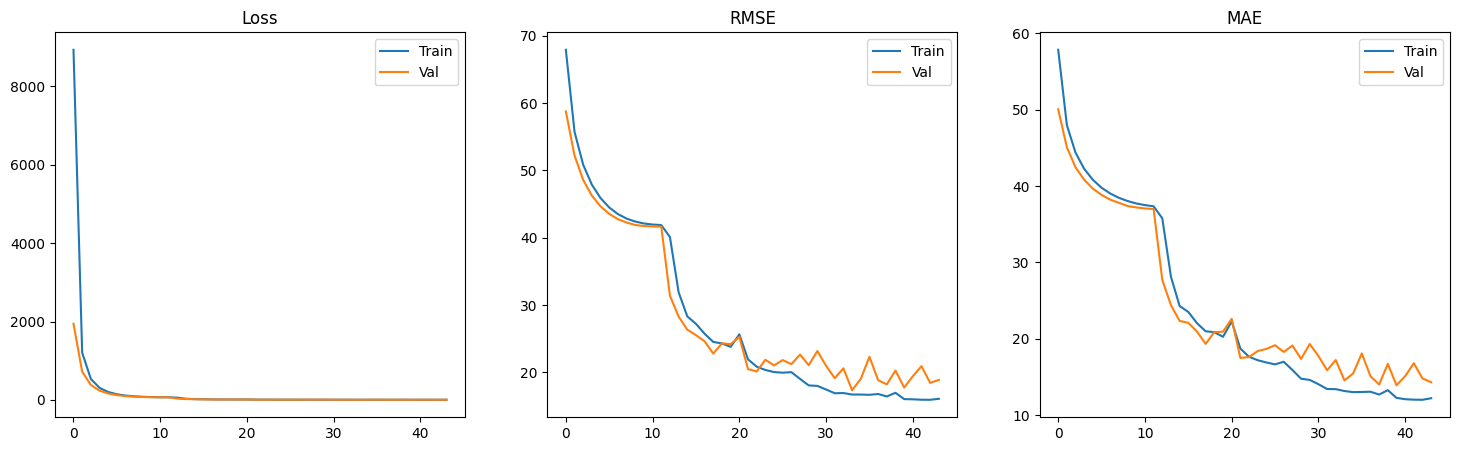

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step

TEST RESULTS → RMSE=17.118, MAE=14.437, R2=0.818


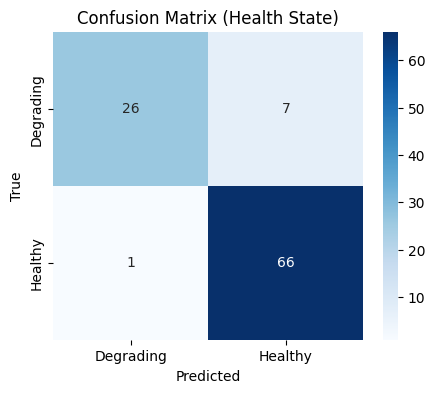

Health-State Classification Accuracy: 0.920


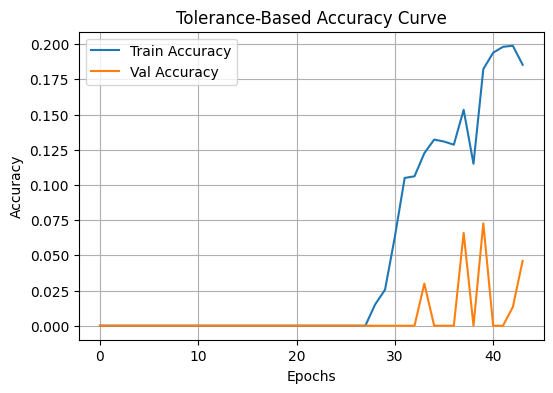

In [ ]:
# ============================================================
# FINAL STABLE Hybrid CNN–Transformer–BiLSTM
# WITH Confusion Matrix + Accuracy Plot
# (Regression-first, classification only for evaluation)
# ============================================================

# -------------------- 1. IMPORTS --------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    accuracy_score
)
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.utils import Sequence

# -------------------- 2. CONSTANTS --------------------
COL_NAMES = [
    'unit_number','time_in_cycles','setting_1','setting_2','setting_3',
    'sensor_1','sensor_2','sensor_3','sensor_4','sensor_5','sensor_6',
    'sensor_7','sensor_8','sensor_9','sensor_10','sensor_11','sensor_12',
    'sensor_13','sensor_14','sensor_15','sensor_16','sensor_17','sensor_18',
    'sensor_19','sensor_20','sensor_21'
]

SELECTED_FEATURES = [
    'setting_1','setting_2','setting_3',
    'sensor_2','sensor_3','sensor_4','sensor_7','sensor_8','sensor_9',
    'sensor_11','sensor_12','sensor_13','sensor_14','sensor_15',
    'sensor_17','sensor_20','sensor_21'
]

TRAIN_DATA_PATH = '/content/drive/MyDrive/C-MAPSS/CMaps/train_FD001.txt'
TEST_DATA_PATH  = '/content/drive/MyDrive/C-MAPSS/CMaps/test_FD001.txt'
TEST_RUL_PATH   = '/content/drive/MyDrive/C-MAPSS/CMaps/RUL_FD001.txt'

SEQUENCE_LENGTH = 30
R_MAX = 125
BATCH_SIZE = 32
EPOCHS = 60

# -------------------- 3. DATA PREPROCESSING --------------------
def load_and_preprocess(path):
    df = pd.read_csv(path, sep=r'\s+', header=None, names=COL_NAMES)
    df = df.iloc[:, :26]
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = max_cycles[df['unit_number']].values - df['time_in_cycles']
    df['RUL'] = df['RUL'].clip(upper=R_MAX)

    scaler = MinMaxScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])
    return df, scaler

def gen_sequences(df):
    X, y = [], []
    for uid in df['unit_number'].unique():
        d = df[df['unit_number'] == uid]
        x = d[SELECTED_FEATURES].values
        t = d['RUL'].values
        for i in range(len(x) - SEQUENCE_LENGTH + 1):
            X.append(x[i:i+SEQUENCE_LENGTH])
            y.append(t[i+SEQUENCE_LENGTH-1])
    return np.array(X), np.array(y)

# -------------------- 4. DATA AUGMENTATION --------------------
def random_slice_and_pad(x, max_pct=0.25):
    out = np.copy(x)
    T = x.shape[1]
    for i in range(len(x)):
        k = np.random.randint(0, int(T*max_pct)+1)
        out[i, :k, :] = 0
    return out

class DataGen(Sequence):
    def __init__(self, X, y, bs, augment=False):
        self.X, self.y, self.bs, self.aug = X, y, bs, augment
        self.idx = np.arange(len(X))
    def __len__(self): return len(self.idx)//self.bs
    def __getitem__(self, i):
        ids = self.idx[i*self.bs:(i+1)*self.bs]
        Xb, yb = self.X[ids], self.y[ids]
        if self.aug:
            Xb += np.random.normal(0,0.01,Xb.shape)
            Xb = random_slice_and_pad(Xb)
            Xb = np.clip(Xb,0,1)
        return Xb.astype(np.float32), yb.astype(np.float32)
    def on_epoch_end(self): np.random.shuffle(self.idx)

# -------------------- 5. LOSS FUNCTION --------------------
def asymmetric_loss(y_true,y_pred):
    diff = y_pred - y_true
    return tf.reduce_mean(
        tf.where(diff < 0,
                 tf.exp(-diff/10) - 1,
                 tf.exp(diff/13) - 1)
    )

# -------------------- 6. TRANSFORMER BLOCK --------------------
def transformer_block(x):
    attn = MultiHeadAttention(4,128)(x,x)
    x = LayerNormalization()(x+attn)
    f = Dense(2*x.shape[-1],activation='relu')(x)
    f = Dense(x.shape[-1])(f)
    return LayerNormalization()(x+f)

# -------------------- 7. MODEL --------------------
def build_model(shape):
    inp = Input(shape=shape)
    x = Conv1D(64,5,padding='causal',activation='relu')(inp)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.2)(x)
    x = transformer_block(x)
    x = transformer_block(x)
    x = Bidirectional(LSTM(64))(x)
    out = Dense(1)(x)
    return Model(inp,out)

# -------------------- 8. LOAD DATA --------------------
train_df, scaler = load_and_preprocess(TRAIN_DATA_PATH)
X, y = gen_sequences(train_df)

Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.2, random_state=42)
train_gen = DataGen(Xtr, ytr, BATCH_SIZE, augment=True)
val_gen   = DataGen(Xv, yv, BATCH_SIZE)

# -------------------- 9. TRAIN --------------------
model = build_model((SEQUENCE_LENGTH, len(SELECTED_FEATURES)))
model.compile(
    optimizer=Adam(1e-3),
    loss=asymmetric_loss,
    metrics=[RootMeanSquaredError(), MeanAbsoluteError()]
)

model.summary()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        ReduceLROnPlateau(patience=5, factor=0.5)
    ],
    verbose=1
)

# -------------------- 10. TRAINING CURVES --------------------
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Val')
plt.title("Loss"); plt.legend()

plt.subplot(1,3,2)
plt.plot(history.history['root_mean_squared_error'],label='Train')
plt.plot(history.history['val_root_mean_squared_error'],label='Val')
plt.title("RMSE"); plt.legend()

plt.subplot(1,3,3)
plt.plot(history.history['mean_absolute_error'],label='Train')
plt.plot(history.history['val_mean_absolute_error'],label='Val')
plt.title("MAE"); plt.legend()

plt.show()

# -------------------- 11. TEST EVALUATION --------------------
df_test = pd.read_csv(TEST_DATA_PATH, sep=r'\s+', header=None, names=COL_NAMES)
df_test = df_test.iloc[:,:26]
df_test[SELECTED_FEATURES] = scaler.transform(df_test[SELECTED_FEATURES])
rul_test = pd.read_csv(TEST_RUL_PATH, header=None)[0].clip(upper=R_MAX)

X_test = []
for uid in df_test['unit_number'].unique():
    d = df_test[df_test['unit_number']==uid][SELECTED_FEATURES].values
    if len(d) < SEQUENCE_LENGTH:
        d = np.vstack((np.zeros((SEQUENCE_LENGTH-len(d), d.shape[1])), d))
    else:
        d = d[-SEQUENCE_LENGTH:]
    X_test.append(d)

X_test = np.array(X_test)
y_pred = model.predict(X_test).flatten()

rmse = np.sqrt(mean_squared_error(rul_test, y_pred))
mae  = mean_absolute_error(rul_test, y_pred)
r2   = r2_score(rul_test, y_pred)

print(f"\nTEST RESULTS → RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")

# -------------------- 12. CONFUSION MATRIX --------------------
THRESHOLD = 50
y_true_cls = (rul_test.values > THRESHOLD).astype(int)
y_pred_cls = (y_pred > THRESHOLD).astype(int)

cm = confusion_matrix(y_true_cls, y_pred_cls)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Degrading','Healthy'],
    yticklabels=['Degrading','Healthy']
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Health State)")
plt.show()

acc = accuracy_score(y_true_cls, y_pred_cls)
print(f"Health-State Classification Accuracy: {acc:.3f}")

# -------------------- 13. ACCURACY CURVE --------------------
TOLERANCE = 15
train_acc = [max(0,1-x/TOLERANCE) for x in history.history['mean_absolute_error']]
val_acc   = [max(0,1-x/TOLERANCE) for x in history.history['val_mean_absolute_error']]

plt.figure(figsize=(6,4))
plt.plot(train_acc,label='Train Accuracy')
plt.plot(val_acc,label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Tolerance-Based Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 30, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 64)    │      5,504 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 15, 64)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 15, 64)    │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │    132,672 │ dropout_3[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 15, 64)    │          0 │ dropout_3[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 15, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 15, 64)    │      8,256 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 15, 64)    │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 15, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 15, 64)    │      8,256 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 15, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 64)    │        128 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     66,048 │ layer_normalizat

 Total params: 370,689 (1.41 MB)

 Trainable params: 370,689 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


443/443 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - loss: 18547.5469 - mean_absolute_error: 62.9559 - root_mean_squared_error: 73.5343 - val_loss: 1905.6901 - val_mean_absolute_error: 49.9453 - val_root_mean_squared_error: 58.6127 - learning_rate: 0.0010
Epoch 2/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1490.6101 - mean_absolute_error: 49.2327 - root_mean_squared_error: 57.2683 - val_loss: 708.2924 - val_mean_absolute_error: 45.0066 - val_root_mean_squared_error: 52.1185 - learning_rate: 0.0010
Epoch 3/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 604.5523 - mean_absolute_error: 44.7156 - root_mean_squared_error: 51.4093 - val_loss: 373.4132 - val_mean_absolute_error: 42.3340 - val_root_mean_squared_error: 48.4434 - learning_rate: 0.0010
Epoch 4/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 337.1795 - mean_absolute_error: 42.6053 - root_mean_squared_error: 48.3443 - val_loss: 232.6726 - val_mean_absolute_error: 40.7168 - val_root_mean_squared_error: 46.1360 - learning

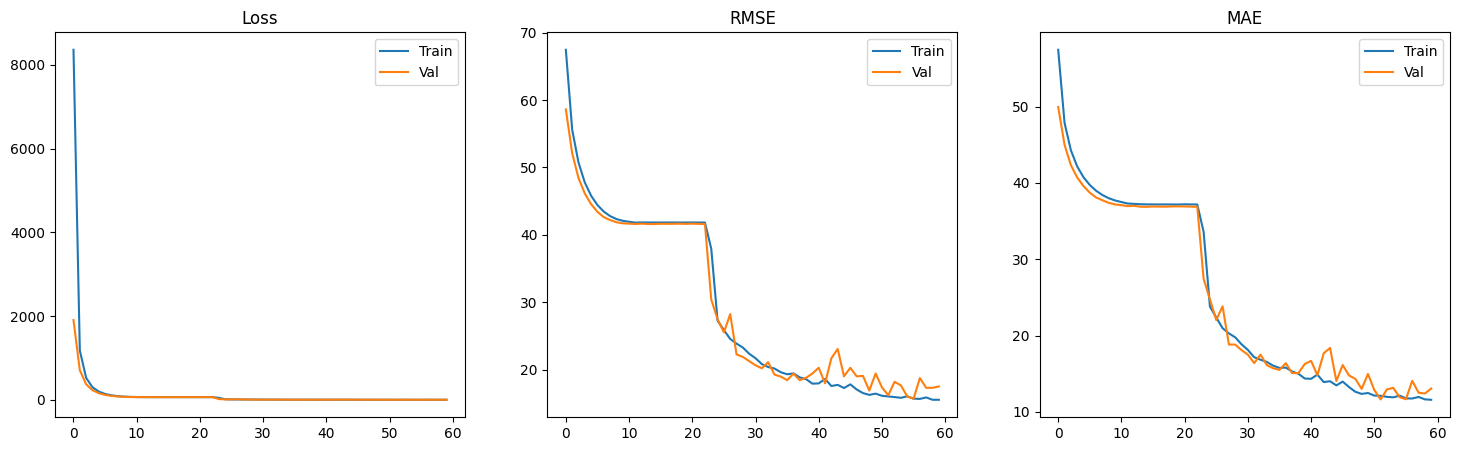

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step

TEST RESULTS → RMSE=16.886, MAE=13.180, R2=0.822


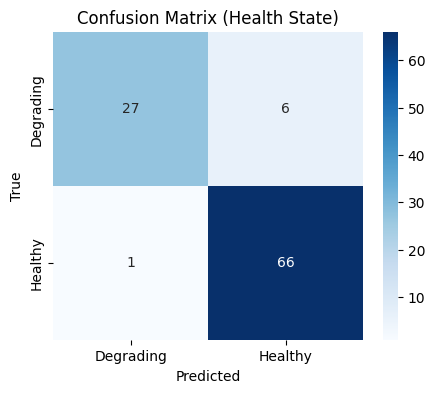

Health-State Classification Accuracy: 0.930


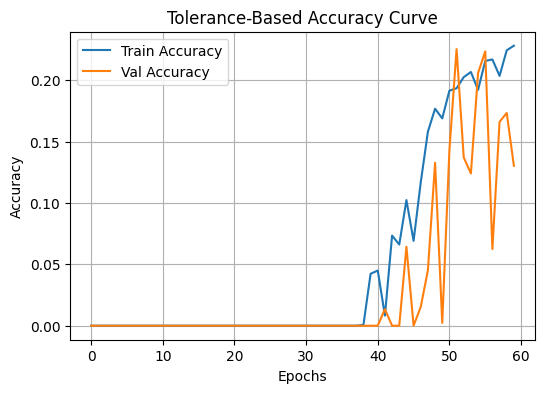

In [ ]:
# ============================================================
# FINAL STABLE Hybrid CNN–Transformer–BiLSTM
# WITH Confusion Matrix + Accuracy Plot
# (Regression-first, classification only for evaluation)
# ============================================================

# -------------------- 1. IMPORTS --------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    accuracy_score
)
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense, LayerNormalization,
    MultiHeadAttention
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.utils import Sequence

# -------------------- 2. CONSTANTS --------------------
COL_NAMES = [
    'unit_number','time_in_cycles','setting_1','setting_2','setting_3',
    'sensor_1','sensor_2','sensor_3','sensor_4','sensor_5','sensor_6',
    'sensor_7','sensor_8','sensor_9','sensor_10','sensor_11','sensor_12',
    'sensor_13','sensor_14','sensor_15','sensor_16','sensor_17','sensor_18',
    'sensor_19','sensor_20','sensor_21'
]

SELECTED_FEATURES = [
    'setting_1','setting_2','setting_3',
    'sensor_2','sensor_3','sensor_4','sensor_7','sensor_8','sensor_9',
    'sensor_11','sensor_12','sensor_13','sensor_14','sensor_15',
    'sensor_17','sensor_20','sensor_21'
]

TRAIN_DATA_PATH = '/content/drive/MyDrive/C-MAPSS/CMaps/train_FD001.txt'
TEST_DATA_PATH  = '/content/drive/MyDrive/C-MAPSS/CMaps/test_FD001.txt'
TEST_RUL_PATH   = '/content/drive/MyDrive/C-MAPSS/CMaps/RUL_FD001.txt'

SEQUENCE_LENGTH = 30
R_MAX = 125
BATCH_SIZE = 32
EPOCHS = 60

# -------------------- 3. DATA PREPROCESSING --------------------
def load_and_preprocess(path):
    df = pd.read_csv(path, sep=r'\s+', header=None, names=COL_NAMES)
    df = df.iloc[:, :26]
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df['RUL'] = max_cycles[df['unit_number']].values - df['time_in_cycles']
    df['RUL'] = df['RUL'].clip(upper=R_MAX)

    scaler = MinMaxScaler()
    df[SELECTED_FEATURES] = scaler.fit_transform(df[SELECTED_FEATURES])
    return df, scaler

def gen_sequences(df):
    X, y = [], []
    for uid in df['unit_number'].unique():
        d = df[df['unit_number'] == uid]
        x = d[SELECTED_FEATURES].values
        t = d['RUL'].values
        for i in range(len(x) - SEQUENCE_LENGTH + 1):
            X.append(x[i:i+SEQUENCE_LENGTH])
            y.append(t[i+SEQUENCE_LENGTH-1])
    return np.array(X), np.array(y)

# -------------------- 4. DATA AUGMENTATION --------------------
def random_slice_and_pad(x, max_pct=0.25):
    out = np.copy(x)
    T = x.shape[1]
    for i in range(len(x)):
        k = np.random.randint(0, int(T*max_pct)+1)
        out[i, :k, :] = 0
    return out

class DataGen(Sequence):
    def __init__(self, X, y, bs, augment=False):
        self.X, self.y, self.bs, self.aug = X, y, bs, augment
        self.idx = np.arange(len(X))
    def __len__(self): return len(self.idx)//self.bs
    def __getitem__(self, i):
        ids = self.idx[i*self.bs:(i+1)*self.bs]
        Xb, yb = self.X[ids], self.y[ids]
        if self.aug:
            Xb += np.random.normal(0,0.01,Xb.shape)
            Xb = random_slice_and_pad(Xb)
            Xb = np.clip(Xb,0,1)
        return Xb.astype(np.float32), yb.astype(np.float32)
    def on_epoch_end(self): np.random.shuffle(self.idx)

# -------------------- 5. LOSS FUNCTION --------------------
def asymmetric_loss(y_true,y_pred):
    diff = y_pred - y_true
    return tf.reduce_mean(
        tf.where(diff < 0,
                 tf.exp(-diff/10) - 1,
                 tf.exp(diff/13) - 1)
    )

# -------------------- 6. TRANSFORMER BLOCK --------------------
def transformer_block(x):
    attn = MultiHeadAttention(4,128)(x,x)
    x = LayerNormalization()(x+attn)
    f = Dense(2*x.shape[-1],activation='relu')(x)
    f = Dense(x.shape[-1])(f)
    return LayerNormalization()(x+f)

# -------------------- 7. MODEL --------------------
def build_model(shape):
    inp = Input(shape=shape)
    x = Conv1D(64,5,padding='causal',activation='relu')(inp)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.2)(x)
    x = transformer_block(x)
    x = transformer_block(x)
    x = Bidirectional(LSTM(64))(x)
    out = Dense(1)(x)
    return Model(inp,out)

# -------------------- 8. LOAD DATA --------------------
train_df, scaler = load_and_preprocess(TRAIN_DATA_PATH)
X, y = gen_sequences(train_df)

Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.2, random_state=42)
train_gen = DataGen(Xtr, ytr, BATCH_SIZE, augment=True)
val_gen   = DataGen(Xv, yv, BATCH_SIZE)

# -------------------- 9. TRAIN --------------------
model = build_model((SEQUENCE_LENGTH, len(SELECTED_FEATURES)))
model.compile(
    optimizer=Adam(1e-3),
    loss=asymmetric_loss,
    metrics=[RootMeanSquaredError(), MeanAbsoluteError()]
)

model.summary()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        ReduceLROnPlateau(patience=5, factor=0.5)
    ],
    verbose=1
)

# -------------------- 10. TRAINING CURVES --------------------
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Val')
plt.title("Loss"); plt.legend()

plt.subplot(1,3,2)
plt.plot(history.history['root_mean_squared_error'],label='Train')
plt.plot(history.history['val_root_mean_squared_error'],label='Val')
plt.title("RMSE"); plt.legend()

plt.subplot(1,3,3)
plt.plot(history.history['mean_absolute_error'],label='Train')
plt.plot(history.history['val_mean_absolute_error'],label='Val')
plt.title("MAE"); plt.legend()

plt.show()

# -------------------- 11. TEST EVALUATION --------------------
df_test = pd.read_csv(TEST_DATA_PATH, sep=r'\s+', header=None, names=COL_NAMES)
df_test = df_test.iloc[:,:26]
df_test[SELECTED_FEATURES] = scaler.transform(df_test[SELECTED_FEATURES])
rul_test = pd.read_csv(TEST_RUL_PATH, header=None)[0].clip(upper=R_MAX)

X_test = []
for uid in df_test['unit_number'].unique():
    d = df_test[df_test['unit_number']==uid][SELECTED_FEATURES].values
    if len(d) < SEQUENCE_LENGTH:
        d = np.vstack((np.zeros((SEQUENCE_LENGTH-len(d), d.shape[1])), d))
    else:
        d = d[-SEQUENCE_LENGTH:]
    X_test.append(d)

X_test = np.array(X_test)
y_pred = model.predict(X_test).flatten()

rmse = np.sqrt(mean_squared_error(rul_test, y_pred))
mae  = mean_absolute_error(rul_test, y_pred)
r2   = r2_score(rul_test, y_pred)

print(f"\nTEST RESULTS → RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")

# -------------------- 12. CONFUSION MATRIX --------------------
THRESHOLD = 50
y_true_cls = (rul_test.values > THRESHOLD).astype(int)
y_pred_cls = (y_pred > THRESHOLD).astype(int)

cm = confusion_matrix(y_true_cls, y_pred_cls)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Degrading','Healthy'],
    yticklabels=['Degrading','Healthy']
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Health State)")
plt.show()

acc = accuracy_score(y_true_cls, y_pred_cls)
print(f"Health-State Classification Accuracy: {acc:.3f}")

# -------------------- 13. ACCURACY CURVE --------------------
TOLERANCE = 15
train_acc = [max(0,1-x/TOLERANCE) for x in history.history['mean_absolute_error']]
val_acc   = [max(0,1-x/TOLERANCE) for x in history.history['val_mean_absolute_error']]

plt.figure(figsize=(6,4))
plt.plot(train_acc,label='Train Accuracy')
plt.plot(val_acc,label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Tolerance-Based Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()